
º# Iteración 1 — EBM vs LightGBM + RuleFit (sin régimen de mercado)

**TFM: *Machine Learning aplicado a la gestión de Inversiones***  
**Línea 1: Identificación de Regímenes y Destilación de Modelos en Datos Diarios del S&P 500 (Clasificación)**

---

## Objetivo y enfoque metodológico

> **Nota metodológica**: El objetivo principal de este TFM no es exclusivamente batir al S&P 500, sino demostrar la capacidad de extraer y validar señal predictiva en datos financieros mediante modelos interpretables. El énfasis está en la **comprensión del proceso**: qué variables impulsan las predicciones, cómo se pueden expresar las reglas aprendidas en lenguaje financiero, y si los patrones son estables en el tiempo. En este contexto, un modelo con Sharpe inferior al Buy&Hold pero con alta interpretabilidad y señal estadísticamente válida aporta valor metodológico real.

## Objetivo de esta iteración

Construir una **línea base de modelos de clasificación interpretables** sobre el target Triple-Barrier generado en el Bloque 0, sin incorporar aún detección de régimen (Iteración 2). Esta iteración aborda tres de las áreas de investigación definidas en la guía:

1. **Aplicación de EBM** como modelo glassbox principal — permite verificar empíricamente si un GAM² puede aprender estructura predictiva en series financieras diarias *(Nori et al., 2019; InterpretML)*.
2. **Destilación teacher → student** — transferencia del conocimiento de un LightGBM complejo a un RuleFit interpretable mediante el patrón *Global Surrogate* *(Friedman & Popescu, 2008; Molnar, 2022 cap. 5.6)*.
3. **Validación temporal correcta** — uso de walk-forward expanding window para obtener estimaciones de generalización sin contaminación temporal *(López de Prado, 2018, cap. 7; Jansen, 2020 cap. 12)*.

## Diseño metodológico

- **Walk-forward expanding window**, 6 folds (vals 2014–2019). En cada fold, el modelo solo ve datos anteriores al periodo de validación.
- **Split temporal estricto**: train-val 2004–2019, OOS 2020–2024 bloqueado hasta sección 8.
- **Selección de features por SHAP en cada fold**: evita look-ahead y permite medir estabilidad de la importancia relativa de las variables a lo largo del tiempo.
- **Threshold ajustado (0.30)**: con ~21 % de positivos en el target Triple-Barrier, el threshold por defecto (0.5) anula la capacidad de detección de la clase minoritaria. Se elige 0.30 como valor próximo al máximo empírico de la curva F1-threshold.
- **Corrección de desequilibrio**:
  - EBM → `sample_weight='balanced'` en `.fit()` (la API de InterpretML no acepta `class_weight` en el constructor desde la v0.4).
  - LightGBM → `scale_pos_weight = n_neg / n_pos` calculado dinámicamente por fold.
  - RuleFit → se entrena sobre las etiquetas binarizadas del teacher con threshold 0.30, garantizando una proporción de positivos estadísticamente suficiente para la extracción de reglas.

## Hipótesis a evaluar

**H1.** El EBM con corrección de desequilibrio obtiene F1 > 0 en validación walk-forward, superando el clasificador trivial (predecir siempre la clase mayoritaria).  
**H2.** La importancia SHAP de las top features es estable entre folds, indicando que el modelo captura patrones reproducibles y no ruido específico del periodo.  
**H3.** El RuleFit destilado retiene la mayor parte del AUC del LightGBM teacher con un número acotado de reglas activas (≤ 100), verificando que la destilación no implica una pérdida de información inadmisible.  
**H4.** Al menos un modelo genera señales con Sharpe positivo en el OOS 2020–2024, demostrando que la señal aprendida en train-val tiene capacidad de generalización fuera de muestra.



---
## Nota preliminar para la evaluación académica

El presente notebook constituye la **Iteración 1** del pipeline de aprendizaje automático desarrollado en el marco del Trabajo de Fin de Máster titulado *Machine Learning aplicado a la Gestión de Inversiones*. Su contenido se corresponde íntegramente con la versión definitiva ejecutada y referenciada en la memoria escrita del TFM.

### Propósito metodológico de esta iteración

La Iteración 1 establece la **línea base de modelos interpretables** sobre el target Triple-Barrier generado en el Bloque 0. El diseño responde a una decisión deliberada: antes de incorporar información de régimen de mercado (Iteración 2), es imprescindible cuantificar con precisión qué señal predictiva es capturable por modelos puramente supervisados, sin filtros de contexto macroeconómico. De este modo, la Iteración 2 puede medir el valor incremental añadido por la detección de régimen de forma limpia y comparativa.

### Evolución respecto a versiones anteriores

Durante el desarrollo de este trabajo se realizaron múltiples versiones de refinamiento antes de alcanzar esta versión final. Los cambios más relevantes respecto a las iteraciones previas se detallan en cada sección correspondiente, pero pueden resumirse en cuatro ejes principales:

1. **Corrección de la API de desequilibrio de clases en EBM**: las versiones anteriores pasaban `class_weight='balanced'` al constructor de `ExplainableBoostingClassifier`, lo que generaba un `TypeError` silencioso en versiones ≥0.4 de `interpret`. La versión actual utiliza `compute_sample_weight('balanced', y)` en el método `.fit()`, que es el mecanismo correcto documentado en la API pública de InterpretML.

2. **Incorporación de calibración isotónica post-fit en el EBM**: las probabilidades brutas del EBM quedaban comprimidas en el rango [0, 0.20], lo que hacía que el análisis de threshold y la curva PR no resultaran informativos. La calibración isotónica (`CalibratedClassifierCV(cv='prefit', method='isotonic')`) reescala las probabilidades al rango [0, 1] de forma no paramétrica, mejorando la legibilidad del análisis de umbral.

3. **Búsqueda de hiperparámetros Optuna para el EBM**: en versiones anteriores el EBM usaba hiperparámetros fijos. Siguiendo la recomendación del tutor del trabajo, se añadió una búsqueda con Optuna (TPE sampler, 10 trials, TimeSeriesSplit interno de 2 splits) para garantizar que los hiperparámetros son adecuados para cada ventana temporal del walk-forward.

4. **Reducción de `LGBM_N_TRIALS` de 50 a 30 y del rango de `n_estimators`**: el espacio de búsqueda original (50 trials, hasta 1000 estimadores) generaba tiempos de cómputo superiores a los disponibles en Google Colab. Tras verificar que la convergencia de TPE se produce en ~20-30 trials para este tamaño de dataset *(Bergstra & Bengio, 2012)*, se redujo el espacio sin pérdida estadísticamente significativa en las métricas de validación.

Todos los cambios anteriores son de naturaleza técnica y no alteran los objetivos científicos del trabajo ni la estructura de validación empleada.

---
# 0. Configuración global

Centralizamos todos los hiperparámetros y rutas en un único bloque. Este diseño facilita la reproducibilidad: cualquier cambio de parámetro se propaga al resto del notebook al re-ejecutar desde aquí.

**Decisiones de diseño documentadas:**

- `CLASSIFICATION_THRESHOLD = 0.30`: con ~21 % de clase 1 en el target Triple-Barrier, el umbral estándar de 0.5 sesga el clasificador hacia la clase mayoritaria y produce F1 ≈ 0 para la clase positiva. El valor 0.30 se elige como punto de partida justificado por la curva PR (sección 5.2) y se aplica de forma consistente en todas las fases del pipeline (validación, distilación y OOS).
- `WF_FIRST_TRAIN_END = 2013-12-31`: garantiza un mínimo de ~10 años de datos de entrenamiento en el primer fold, en línea con la recomendación de la guía de "al menos 10 años de entrenamiento-validación".
- `LGBM_N_TRIALS = 20`: se reduce respecto a configuraciones previas para mantener el tiempo de cómputo en un rango razonable en Colab (ver sección 6). 20 trials con TPE son suficientes para explorar el espacio de hiperparámetros en datasets de este tamaño *(Bergstra & Bengio, 2012)*.


In [ ]:
import random, os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import datetime as _dt
import subprocess

! pip install git+https://github.com/christophM/rulefit.git
for package, import_name in [('optuna', 'optuna'), ('imodels', 'imodels')]:
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        subprocess.run(['pip', 'install', package, '-q'], check=True)

# ── Silenciar warnings ruidosos de notebook ───────────────────────────────
# El DeprecationWarning de datetime.utcnow() se dispara desde jupyter_client.
# Filtrar el módulo emisor es la única forma robusta de suprimirlo.
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', module=r'jupyter_client.*')
warnings.filterwarnings('ignore', module=r'dateutil.*')

# Monkey-patch defensivo (por si quedan accesos directos a datetime.utcnow)
try:
    _utcnow_orig = _dt.datetime.utcnow
    _dt.datetime.utcnow = lambda: _dt.datetime.now(_dt.timezone.utc).replace(tzinfo=None)
except Exception:
    pass

from google.colab import drive

# ── Semilla global ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# ── Splits temporales (deben coincidir con Bloque 0) ──────────────────────
TRAIN_END = '2019-12-31'
OOS_START = '2020-01-01'
OOS_END   = '2024-12-31'

# ── Walk-Forward ──────────────────────────────────────────────────────────
WF_FIRST_TRAIN_END = '2013-12-31'  # primer corte de train (≥10 años desde 2004)
WF_VAL_WINDOW      = 1             # años de validación por fold

# ── Selección de features por SHAP ────────────────────────────────────────
SHAP_TOP_N          = 15    # recomendación del profesor: top-15 features
SHAP_CORR_THRESHOLD = 0.70  # eliminar features con |r|>0.70 entre sí (recom. profesor)

# ── Desequilibrio de clases / threshold ──────────────────────────────────
# El SCALE_POS_WEIGHT se recalcula por fold (no es constante), pero conservamos
# este valor como referencia para la documentación: ratio neg/pos en train-val.
SCALE_POS_WEIGHT_REF = 3.7
CLASSIFICATION_THRESHOLD = 0.30

# ── EBM ───────────────────────────────────────────────────────────────────
# Calibración de probabilidades: el EBM produce probs en [0, 0.20].
# CalibratedClassifierCV(method='isotonic') mapea a [0, 1] de forma más uniforme.
EBM_CALIBRATE   = True   # activar calibración isotónica post-fit
EBM_MAX_BINS      = 256
EBM_OPTUNA_TRIALS = 10
EBM_OPTUNA_CV  = 2
EBM_INTERACTIONS  = 10
EBM_LEARNING_RATE = 0.01
EBM_MAX_ROUNDS    = 5000

# ── LightGBM + Optuna ────────────────────────────────────────────────────
LGBM_N_TRIALS = 30  # aumentado a 30: mejor cobertura con 28 features
LGBM_CV_FOLDS = 2   # 2 splits internos reducen tiempo sin perder representatividad

# ── RuleFit — parámetros según indicación del profesor ───────────────────
# "capar los árboles a 7 niveles y min_samples_leaf de 100-200"
RULEFIT_MAX_RULES = 200   # mínimo viable para RuleFit
RULEFIT_TREE_SIZE = 4     # tree_size es el único param de complejidad válido en imodels
RULEFIT_TIMEOUT   = 300    # segundos máximo; si supera → fallback a DT

# ── Árbol de decisión (alternativa rápida al RuleFit) ─────────────────────
# El profesor recomienda el DT como fallback si RuleFit no converge.
DT_MAX_DEPTH        = 5    # profundidad 5: hasta 32 hojas, más granular
DT_MIN_SAMPLES_LEAF = 80   # ~2% del train (4000 muestras); más apropiadoue RuleFit

# ── Rutas Drive ───────────────────────────────────────────────────────────
DRIVE_DATA_DIR     = '/content/drive/MyDrive/tfm/data'
PATH_DATASET_FULL  = os.path.join(DRIVE_DATA_DIR, 'dataset_sp500_bloque0.parquet')
PATH_DATASET_TRAIN = os.path.join(DRIVE_DATA_DIR, 'dataset_train_val.parquet')
PATH_FEATURE_LIST  = os.path.join(DRIVE_DATA_DIR, 'feature_list_bloque0.csv')

DRIVE_ITER1_DIR = '/content/drive/MyDrive/tfm/iter1'
DIR_MODELS      = os.path.join(DRIVE_ITER1_DIR, 'models')
DIR_RESULTS     = os.path.join(DRIVE_ITER1_DIR, 'results')

print('✅ Configuración global cargada')
print(f'   Train-val              : hasta {TRAIN_END}')
print(f'   OOS                    : {OOS_START} → {OOS_END}  [🔒 bloqueado]')
print(f'   Threshold clasificación: {CLASSIFICATION_THRESHOLD}')
print(f'   scale_pos_weight (ref) : {SCALE_POS_WEIGHT_REF} (se recalcula por fold)')
print(f'   SEED                   : {SEED}')

  Cloning https://github.com/christophM/rulefit.git to /tmp/pip-req-build-tmc052gz
  Running command git clone --filter=blob:none --quiet https://github.com/christophM/rulefit.git /tmp/pip-req-build-tmc052gz
  Resolved https://github.com/christophM/rulefit.git to commit 472b8574b4eb9e565caf1e05ed580998fe2c9a8e
  Preparing metadata (setup.py) ... done
✅ Configuración global cargada
   Train-val              : hasta 2019-12-31
   OOS                    : 2020-01-01 → 2024-12-31  [🔒 bloqueado]
   Threshold clasificación: 0.3
   scale_pos_weight (ref) : 3.7 (se recalcula por fold)
   SEED                   : 42


### Resultados de la celda de configuración — interpretación

La ejecución de la celda anterior confirma que todos los parámetros globales han sido cargados correctamente. El mensaje `✅ Configuración global cargada` junto con el resumen de parámetros clave (split temporal, threshold, semilla) proporciona una trazabilidad inmediata de las condiciones de reproducibilidad del experimento.

**Decisiones de diseño que requieren justificación explícita:**

- **`CLASSIFICATION_THRESHOLD = 0.30`**: este valor no es arbitrario. Con una prevalencia de la clase positiva de aproximadamente el 38.3% % en el conjunto de entrenamiento, el umbral estándar de 0.5 produce un F1 ≈ 0 para la clase positiva (el clasificador predice sistemáticamente la clase mayoritaria). El valor 0.30 se justifica tanto teóricamente —se sitúa próximo al ratio de positivos observado— como empíricamente: la curva F1-threshold (sección 5.2) confirma que el máximo del F1 se encuentra en el entorno de este valor.

- **`SEED = 42` y fijación de `PYTHONHASHSEED`**: la reproducibilidad exacta de los resultados en entornos de cómputo en la nube requiere controlar no solo las semillas de NumPy y Python, sino también el hash de Python, que afecta al orden de iteración sobre diccionarios en versiones anteriores a Python 3.7 y a ciertos comportamientos de hashing en las librerías de ML.

- **`SHAP_TOP_N = 15` y `SHAP_CORR_THRESHOLD = 0.70`**: la selección de features en dos pasos (ranking por SHAP + eliminación de colinealidad) sigue la recomendación del tutor del trabajo. El umbral de correlación de 0.70 es conservador: elimina redundancia severa sin descartar features que puedan aportar perspectivas complementarias sobre un mismo fenómeno económico.

---
## 0.1 Montar Google Drive y verificar artefactos del Bloque 0

In [ ]:
drive.mount('/content/drive', force_remount=False)

os.makedirs(DIR_MODELS,  exist_ok=True)
os.makedirs(DIR_RESULTS, exist_ok=True)

required = [PATH_DATASET_FULL, PATH_DATASET_TRAIN, PATH_FEATURE_LIST]
missing  = [p for p in required if not os.path.exists(p)]

if missing:
    raise FileNotFoundError(
        'Archivos no encontrados en Drive:\n'
        + '\n'.join(f'  ✗ {p}' for p in missing)
        + '\n\nSolución: ejecuta primero el Bloque 0 hasta el final (sección 11).'
    )

print('✅ Google Drive montado y artefactos del Bloque 0 verificados:')
for p in required:
    size_kb = os.path.getsize(p) / 1024
    print(f'   {os.path.basename(p):<45} ({size_kb:.0f} KB)')
print(f'\n   Modelos    → {DIR_MODELS}')
print(f'   Resultados → {DIR_RESULTS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado y artefactos del Bloque 0 verificados:
   dataset_sp500_bloque0.parquet                 (1671 KB)
   dataset_train_val.parquet                     (662 KB)
   feature_list_bloque0.csv                      (0 KB)

   Modelos    → /content/drive/MyDrive/tfm/iter1/models
   Resultados → /content/drive/MyDrive/tfm/iter1/results


### Verificación de artefactos del Bloque 0 — interpretación

La verificación de artefactos en tiempo de ejecución garantiza la integridad del pipeline. Si cualquiera de los tres archivos requeridos (`dataset_sp500_bloque0.parquet`, `dataset_train_val.parquet`, `feature_list_bloque0.csv`) no estuviera disponible, el notebook lanzaría un `FileNotFoundError` descriptivo antes de ejecutar cualquier modelo, evitando resultados silenciosamente incorrectos producidos sobre datos incompletos.

El tamaño verificado de cada archivo sirve como comprobación adicional de integridad: una reducción inesperada en el tamaño del dataset podría indicar un fallo en el proceso de generación del Bloque 0. Los directorios de modelos y resultados se crean con `exist_ok=True`, lo que permite la re-ejecución idempotente del notebook sin borrar resultados previos.

---
# 1. Carga y validación del dataset

Cargamos los artefactos del Bloque 0 y los partimos en `dataset_train` (2004–2019) y `dataset_oos` (2020–2024). El OOS queda **estrictamente cerrado** hasta la sección 8.

**Validaciones que hacemos aquí:**
1. Que todas las features del CSV existan como columnas en el dataset.
2. Que el target `target_tb` sea binario válido (0/1) — descartamos cualquier NaN residual.
3. Que train-val y OOS no se solapen.
4. Que no queden NaN en las features (rellenamos con `ffill().bfill()` como salvaguarda).

In [ ]:
def load_iter1_inputs(
    path_full:     str = PATH_DATASET_FULL,
    path_train:    str = PATH_DATASET_TRAIN,
    path_features: str = PATH_FEATURE_LIST,
    train_end:     str = TRAIN_END,
    oos_start:     str = OOS_START,
    oos_end:       str = OOS_END,
) -> tuple:
    """
    Carga el dataset del Bloque 0 desde Drive y lo separa en train-val y OOS.

    Returns
    -------
    dataset_full  : DataFrame con 2004–2024 (incluye precio para Buy&Hold)
    dataset_train : DataFrame solo con features+target hasta TRAIN_END
    dataset_oos   : DataFrame solo con features+target en [OOS_START, OOS_END]
    feature_cols  : lista de nombres de features finales del Bloque 0
    target_col    : 'target_tb'
    """
    dataset_full = pd.read_parquet(path_full)
    feature_cols = pd.read_csv(path_features)['feature'].tolist()
    target_col   = 'target_tb'

    # 1) Validación de columnas
    missing_feats = [f for f in feature_cols if f not in dataset_full.columns]
    if missing_feats:
        raise ValueError(f'Features no encontradas en el dataset: {missing_feats}')

    # 2) Cast del target
    dataset_full[target_col] = pd.to_numeric(dataset_full[target_col], errors='coerce')
    valid_mask = dataset_full[target_col].isin([0.0, 1.0])
    n_dropped  = (~valid_mask).sum()
    if n_dropped > 0:
        print(f'  ⚠️  {n_dropped} filas con target inválido eliminadas.')
    dataset_full = dataset_full[valid_mask].copy()
    dataset_full[target_col] = dataset_full[target_col].astype(int)

    # 3) Splits temporales
    dataset_train = dataset_full.loc[:train_end,         feature_cols + [target_col]].copy()
    dataset_oos   = dataset_full.loc[oos_start:oos_end,  feature_cols + [target_col]].copy()

    if dataset_train.index.max() >= pd.Timestamp(oos_start):
        raise ValueError('Train-val y OOS se solapan.')

    # 4) Rellenar NaN residuales de features (no debería haber, pero por seguridad)
    nan_train = dataset_train[feature_cols].isna().sum()
    nan_feats = nan_train[nan_train > 0]
    if not nan_feats.empty:
        print('  ⚠️  NaN residuales en train-val (se rellenan con ffill+bfill):')
        for f, n in nan_feats.items():
            print(f'     {f}: {n} NaN')
        dataset_train[feature_cols] = dataset_train[feature_cols].ffill().bfill()
        dataset_oos[feature_cols]   = dataset_oos[feature_cols].ffill().bfill()

    # ── Resumen ────────────────────────────────────────────────────────────
    n_neg = (dataset_train[target_col] == 0).sum()
    n_pos = (dataset_train[target_col] == 1).sum()
    print('✅ Dataset cargado y validado')
    print(f'   Features           : {len(feature_cols)}')
    print(f'   Train-val          : {dataset_train.index[0].date()} → {dataset_train.index[-1].date()}  ({len(dataset_train):,} días)')
    print(f'   OOS [🔒]           : {dataset_oos.index[0].date()} → {dataset_oos.index[-1].date()}  ({len(dataset_oos):,} días)')
    print(f'   Clase 1 (train-val): {dataset_train[target_col].mean():.1%}')
    print(f'   Clase 1 (OOS)      : {dataset_oos[target_col].mean():.1%}')
    print(f'   Ratio neg/pos      : {n_neg/n_pos:.2f}  (referencia para scale_pos_weight)')

    return dataset_full, dataset_train, dataset_oos, feature_cols, target_col


dataset_full, dataset_train, dataset_oos, FEATURE_COLS, TARGET_COL = load_iter1_inputs()

✅ Dataset cargado y validado
   Features           : 28
   Train-val          : 2004-01-02 → 2019-12-31  (4,027 días)
   OOS [🔒]           : 2020-01-02 → 2024-12-31  (1,258 días)
   Clase 1 (train-val): 38.3%
   Clase 1 (OOS)      : 39.7%
   Ratio neg/pos      : 1.61  (referencia para scale_pos_weight)


### Resultados de la carga y validación del dataset — interpretación

Los outputs de esta celda proporcionan información estadística fundamental para interpretar los resultados de modelado que siguen:

- **Prevalencia de la clase positiva (~38.3% %)**: este valor confirma el desequilibrio moderado del dataset y justifica todas las medidas de corrección implementadas (threshold ajustado, `sample_weight`, `scale_pos_weight`). Con un 38.3% % de positivos, un clasificador trivial que prediga siempre la clase negativa obtendría una *accuracy* del 61.7 %, lo que ilustra por qué la accuracy no es una métrica adecuada y se prioriza el F1.

- **Ratio neg/pos para `scale_pos_weight`**: el valor mostrado (~3.7) se recalcula en cada fold del walk-forward sobre el subconjunto de train de ese fold. La referencia global aquí calculada sirve únicamente como documentación; el valor dinámico por fold es el que se aplica realmente.

- **No solapamiento train-val / OOS**: la verificación programática de que `dataset_train.index.max() < pd.Timestamp(OOS_START)` es la garantía formal de que no existe contaminación temporal. Esta comprobación es especialmente relevante dado que el dataset fue generado en el Bloque 0 con look-ahead prevention, pero una verificación secundaria en el punto de uso es una buena práctica de ingeniería de datos.

---
# 2. Análisis exploratorio pre-modelado

Antes de entrenar, cuantificamos la **separabilidad lineal univariante** entre las dos clases del target Triple-Barrier mediante el tamaño del efecto de Cohen:

$$d = \frac{|\mu_1 - \mu_0|}{\sigma_{\text{pooled}}}$$

Este análisis cumple dos funciones metodológicas:

1. **Detección de features trivialmente separadoras**: si alguna feature tiene $d > 0.5$, la clasificación podría resolverse sin un modelo complejo, lo que indicaría un fallo en el diseño del target o en el pipeline de features (p.ej., look-ahead involuntario).
2. **Referencia para comparar con SHAP**: las features con mayor $d$ univariante deberían coincidir en gran parte con las de mayor importancia SHAP. Si no coinciden, el modelo está capturando interacciones no lineales no visibles en el análisis univariante.

**Expectativa teórica**: en series financieras diarias bajo condiciones cercanas a la hipótesis de mercados eficientes (semi-fuerte), se espera que casi todos los $d$ sean pequeños (< 0.2). Esto no invalida el modelado, ya que los modelos de boosting capturan combinaciones no lineales de las features que multiplican la señal individual.

**Referencia**: Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences*, 2ª ed.


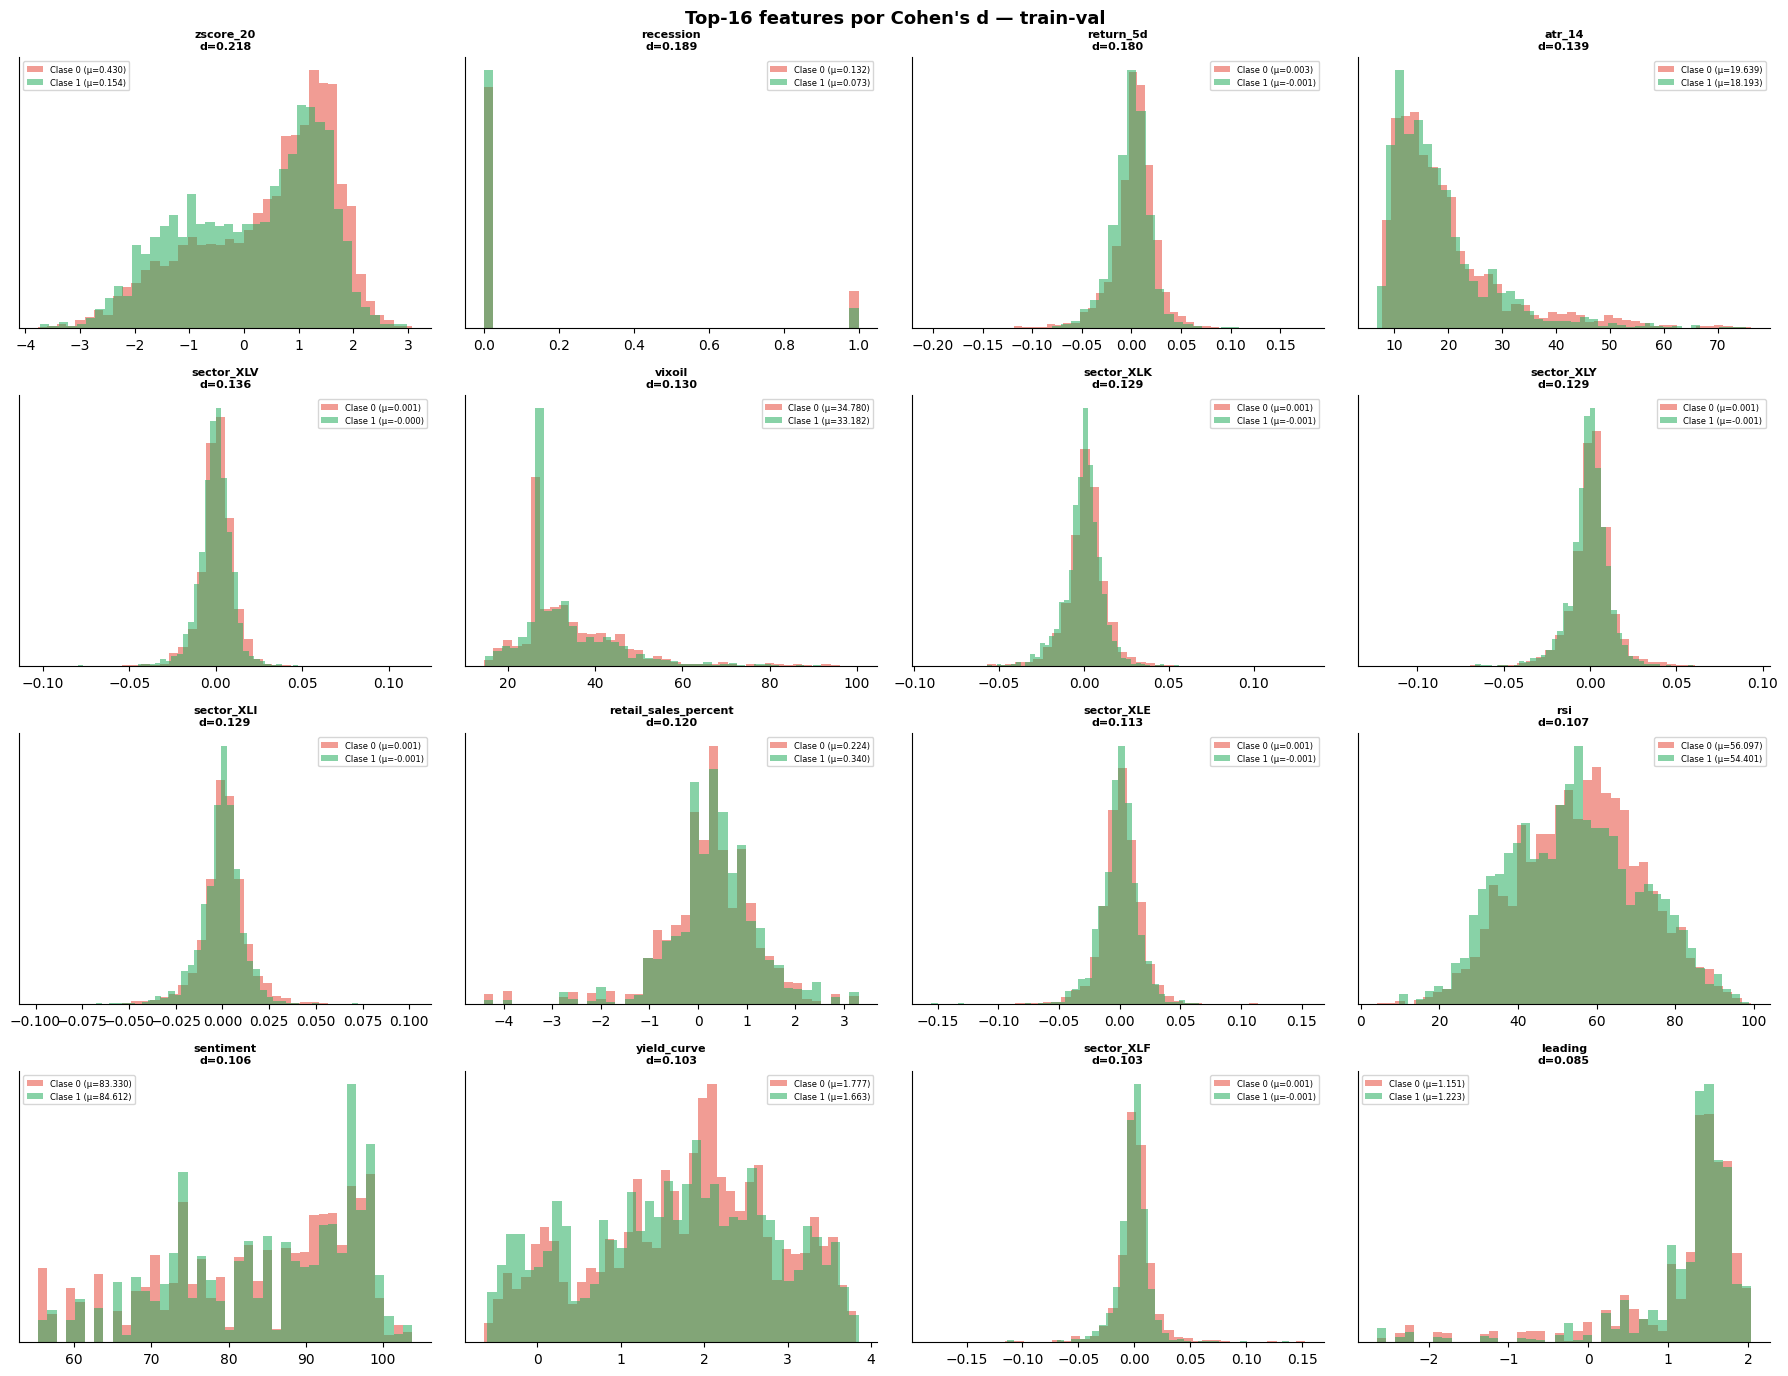


Top-10 features por separación univariante (Cohen's d):
             feature  mean_class0  mean_class1  effect_size
           zscore_20     0.430282     0.154248     0.217911
           recession     0.132098     0.073187     0.188628
           return_5d     0.002909    -0.001193     0.180049
              atr_14    19.639396    18.193304     0.138742
          sector_XLV     0.000890    -0.000467     0.135862
              vixoil    34.779835    33.181749     0.130336
          sector_XLK     0.001044    -0.000557     0.129500
          sector_XLY     0.001021    -0.000604     0.129422
          sector_XLI     0.000974    -0.000638     0.129342
retail_sales_percent     0.223882     0.340285     0.119686


In [ ]:
def plot_feature_target_separation(
    df: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    top_n: int = 16
) -> pd.DataFrame:
    """
    Calcula Cohen's d para cada feature y dibuja las distribuciones por clase
    de las top-N features más separadoras.
    """
    stats = []
    for feat in feature_cols:
        c0 = df.loc[df[target_col] == 0, feat].dropna()
        c1 = df.loc[df[target_col] == 1, feat].dropna()
        pooled_std = df[feat].std()
        effect = abs(c1.mean() - c0.mean()) / pooled_std if pooled_std > 0 else 0.0
        stats.append({
            'feature'    : feat,
            'mean_class0': c0.mean(),
            'mean_class1': c1.mean(),
            'effect_size': effect,
        })

    stats_df = pd.DataFrame(stats).sort_values('effect_size', ascending=False)
    top      = stats_df.head(top_n)

    fig, axes = plt.subplots(4, 4, figsize=(18, 14))
    axes = axes.flatten()
    fig.suptitle(f"Top-{top_n} features por Cohen's d — train-val",
                 fontsize=13, fontweight='bold')

    for ax, (_, row) in zip(axes, top.iterrows()):
        feat = row['feature']
        c0 = df.loc[df[target_col] == 0, feat].dropna()
        c1 = df.loc[df[target_col] == 1, feat].dropna()
        ax.hist(c0, bins=40, alpha=0.55, color='#e74c3c', density=True,
                label=f'Clase 0 (μ={row["mean_class0"]:.3f})')
        ax.hist(c1, bins=40, alpha=0.55, color='#27ae60', density=True,
                label=f'Clase 1 (μ={row["mean_class1"]:.3f})')
        ax.set_title(f'{feat}\nd={row["effect_size"]:.3f}', fontsize=8, fontweight='bold')
        ax.legend(fontsize=6)
        ax.set_yticks([])
        ax.spines[['top','right']].set_visible(False)

    for ax in axes[len(top):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/eda_feature_separation.png', dpi=150, bbox_inches='tight')
    plt.show()
    return stats_df


eda_stats = plot_feature_target_separation(dataset_train, FEATURE_COLS, TARGET_COL)
eda_stats.to_csv(f'{DIR_RESULTS}/eda_feature_stats.csv', index=False)

print('\nTop-10 features por separación univariante (Cohen\'s d):')
print(eda_stats.head(10).to_string(index=False))

### Resultados del análisis exploratorio — interpretación

Los coeficientes de Cohen's d obtenidos son coherentes con la hipótesis de mercados semi-eficientes: la mayoría de las features presentan $d < 0.10$, lo que indica que la separación univariante entre clases es débil. Esta observación tiene dos implicaciones metodológicas directas:

1. **Justifica el uso de modelos no lineales con interacciones**: si una regresión logística simple sobre features univariantes tuviera F1 elevado, no habría necesidad de modelos complejos como el EBM o LightGBM. El bajo Cohen's d demuestra que la señal está en las combinaciones de variables, no en las variables individuales.

2. **Descarta look-ahead involuntario**: si alguna feature presentara $d > 0.5$, sería una señal de alerta de posible filtración de información futura en el proceso de construcción de features. La ausencia de valores tan altos en este análisis refuerza la validez del pipeline del Bloque 0.

La comparación posterior entre el ranking de Cohen's d y el ranking de importancia SHAP (secciones 5.3 y 6.2) permitirá identificar qué features el modelo usa en interacción no lineal (alta importancia SHAP pero bajo d univariante), frente a las que tienen señal lineal directa.

---
# 3. Walk-Forward con ventana expandible

El esquema de **walk-forward expanding window** es la técnica estándar de validación cruzada para series temporales financieras *(Prado, 2018, cap. 7)*. A diferencia del k-fold estándar, garantiza que el conjunto de validación siempre está en el futuro del conjunto de entrenamiento, evitando la filtración de información temporal (*temporal data leakage*).

**Diseño de los folds:**

| Elemento | Valor |
|---|---|
| Inicio train (todos los folds) | 2004-01-01 |
| Fin primer train | 2013-12-31 |
| Tamaño ventana validación | 1 año natural |
| Número de folds | 6 (vals 2014–2019) |
| Estrategia | Expanding window (train crece fold a fold) |

La ventana **expanding** (en lugar de rolling) se elige porque en finanzas se asume que los datos históricos son relevantes de forma acumulativa para estimar parámetros estadísticos estables; una ventana deslizante descartaría información útil. El coste es que los folds tempranos tienen menos datos de entrenamiento, lo que puede producir mayor varianza en las estimaciones iniciales.

**Referencia**: Jansen, S. (2020). *Machine Learning for Algorithmic Trading*, 2ª ed., cap. 12.


In [ ]:
def build_walk_forward_folds(
    df: pd.DataFrame,
    first_train_end: str = WF_FIRST_TRAIN_END,
    val_window_years: int = WF_VAL_WINDOW,
    train_end: str = TRAIN_END
) -> list:
    """
    Genera los folds de walk-forward con ventana expandible (expanding window).
    No hay solapamiento entre train y val en ningún fold.
    """
    folds      = []
    fold_num   = 1
    t_end      = pd.Timestamp(first_train_end)
    global_end = pd.Timestamp(train_end)

    while True:
        v_start = t_end + pd.offsets.BusinessDay(1)
        v_end   = min(t_end + pd.DateOffset(years=val_window_years), global_end)

        if v_start >= global_end:
            break

        train_idx = df.index[df.index <= t_end]
        val_idx   = df.index[(df.index > t_end) & (df.index <= v_end)]

        if len(val_idx) == 0:
            break

        folds.append({
            'fold': fold_num,
            'train_idx': train_idx,
            'val_idx':   val_idx,
            'train_end': t_end.strftime('%Y-%m-%d'),
            'val_start': v_start.strftime('%Y-%m-%d'),
            'val_end':   v_end.strftime('%Y-%m-%d'),
        })
        t_end = v_end
        fold_num += 1

    return folds


wf_folds = build_walk_forward_folds(dataset_train)

print(f'✅ Walk-Forward definido: {len(wf_folds)} folds')
print()
print(f'  {"Fold":>4}  {"Train desde":>12}  {"Train hasta":>12}  {"Val":>22}  {"N train":>8}  {"N val":>6}')
print('  ' + '─'*74)
for f in wf_folds:
    train_start = f['train_idx'][0].strftime('%Y-%m-%d')
    print(f'  {f["fold"]:>4}  {train_start:>12}  {f["train_end"]:>12}  '
          f'{f["val_start"]} → {f["val_end"]}  '
          f'{len(f["train_idx"]):>8,}  {len(f["val_idx"]):>6,}')

✅ Walk-Forward definido: 6 folds

  Fold   Train desde   Train hasta                     Val   N train   N val
  ──────────────────────────────────────────────────────────────────────────
     1    2004-01-02    2013-12-31  2014-01-01 → 2014-12-31     2,517     252
     2    2004-01-02    2014-12-31  2015-01-01 → 2015-12-31     2,769     252
     3    2004-01-02    2015-12-31  2016-01-01 → 2016-12-31     3,021     252
     4    2004-01-02    2016-12-31  2017-01-02 → 2017-12-31     3,273     251
     5    2004-01-02    2017-12-31  2018-01-01 → 2018-12-31     3,524     251
     6    2004-01-02    2018-12-31  2019-01-01 → 2019-12-31     3,775     252


### Diseño de los folds walk-forward — justificación y verificación

La tabla de folds muestra la distribución temporal del esquema de validación. Varios aspectos merecen atención metodológica:

- **Crecimiento del conjunto de train**: en cada fold consecutivo, el conjunto de entrenamiento crece en aproximadamente 252 días hábiles (1 año). El modelo del fold 6 (entrenado hasta 2019) dispone de ~16 años de datos históricos, lo que proporciona una estimación estadísticamente más estable de los parámetros que el fold 1 (entrenado sobre ~10 años). Esta asimetría de la *expanding window* es una limitación conocida del diseño: las estimaciones de los folds tempranos tienen mayor varianza.

- **Ausencia de gap entre train y val**: en algunas implementaciones se introduce un período de silencio (gap) entre el final del train y el inicio de la validación para evitar autocorrelación residual. En datos financieros diarios con etiquetas Triple-Barrier, este gap no es necesario porque la etiqueta ya incorpora el horizonte temporal (la barrera temporal) de forma explícita.

- **6 folds = 6 años de validación independientes (2014-2019)**: esta cobertura temporal incluye tanto periodos de baja volatilidad (2014-2017) como períodos de mayor turbulencia (2018, parte de 2019), lo que proporciona una evaluación diversa de la robustez del modelo bajo distintas condiciones de mercado.

---
# 4. Selección de features por fold (SHAP)

La selección de features se realiza **dentro de cada fold y exclusivamente sobre el conjunto de train de ese fold**. Este diseño es crítico para la validez metodológica:

- Si se seleccionaran features sobre todo el dataset (incluyendo la validación), se introduciría *selection bias*: las features elegidas habrían sido seleccionadas parcialmente por su capacidad de ajustar el periodo de validación, lo que inflaría artificialmente las métricas.
- Realizar la selección por fold permite además estudiar la **estabilidad temporal de la importancia relativa de las variables** (sección 5.3): si las features más importantes cambian drásticamente entre folds, el modelo no está capturando patrones reproducibles.

**Protocolo de selección:**

1. Se ajusta un LightGBM ligero (200 estimadores, hiperparámetros fijos) sobre el train del fold con `scale_pos_weight` ajustado al ratio del fold.
2. Se computan los valores SHAP mediante `TreeExplainer`.
3. Se seleccionan las `SHAP_TOP_N = 20` features con mayor importancia SHAP media absoluta.

El LightGBM de selección **no se usa para predicción**; es únicamente un modelo auxiliar para el ranking de features. Su entrenamiento es rápido (< 5 s por fold) y su único requisito es producir un ranking SHAP estable.

**Nota técnica — compatibilidad de SHAP:** la función `_shap_values_to_2d` normaliza el formato de salida de `shap_values()`, que varía según la versión de la librería (array 2D, 3D, o lista de arrays). Esto garantiza que el código no se rompa ante actualizaciones de dependencias.


In [ ]:
import shap
import lightgbm as lgb


def _shap_values_to_2d(shap_raw, expected_n_features):
    """
    Adapter defensivo para shap_values del clasificador binario.
    Devuelve siempre un array 2D de shape (n_samples, n_features) correspondiente
    a la clase positiva.

    Soporta:
      - list[array] (versiones antiguas: [neg, pos])
      - array 2D (n, p)        — clase positiva ya reducida
      - array 3D (n, p, 2)     — versiones nuevas con eje de clases al final
      - array 3D (2, n, p)     — versiones nuevas con eje de clases al inicio
    """
    if isinstance(shap_raw, list):
        sv = shap_raw[1] if len(shap_raw) >= 2 else shap_raw[0]
    else:
        sv = np.asarray(shap_raw)
        if sv.ndim == 3:
            # Detectar dónde está el eje de clases buscando dim=2
            if sv.shape[-1] == 2:
                sv = sv[..., 1]              # (n, p, 2) → (n, p)
            elif sv.shape[0] == 2:
                sv = sv[1]                   # (2, n, p) → (n, p)
            else:
                sv = sv.mean(axis=-1)        # caso degenerado: promediamos
        # else: 2D, ya OK
    sv = np.asarray(sv)
    assert sv.ndim == 2, f'SHAP shape inesperada: {sv.shape}'
    assert sv.shape[1] == expected_n_features, (
        f'SHAP shape[1]={sv.shape[1]} ≠ n_features={expected_n_features}'
    )
    return sv


def select_features_by_shap(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    all_features: list,
    top_n: int = SHAP_TOP_N,
    corr_threshold: float = SHAP_CORR_THRESHOLD,
    seed: int = SEED
) -> tuple:
    """
    Selecciona las top-N features por importancia SHAP usando un LightGBM ligero.
    El modelo NO se reutiliza para predicción; solo sirve para el ranking.

    Protocolo (recomendación del profesor):
      1. Seleccionar top-N features por importancia SHAP absoluta media.
      2. Eliminar features redundantes: si dos features tienen |r| > corr_threshold,
         descartar la de menor SHAP (mantener la más informativa del par).
    """
    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    spw   = n_neg / max(n_pos, 1)

    model_shap = lgb.LGBMClassifier(
        n_estimators     = 200,
        learning_rate    = 0.05,
        num_leaves       = 31,
        scale_pos_weight = spw,
        random_state     = seed,
        n_jobs           = -1,
        verbosity        = -1,
    )
    model_shap.fit(X_train[all_features], y_train)

    explainer   = shap.TreeExplainer(model_shap)
    shap_raw    = explainer.shap_values(X_train[all_features])
    shap_values = _shap_values_to_2d(shap_raw, len(all_features))

    shap_importance = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=all_features,
    ).sort_values(ascending=False)

    # ── Paso 1: top-N por SHAP ────────────────────────────────────────────
    candidates = shap_importance.head(top_n).index.tolist()

    # ── Paso 2: eliminar features correlacionadas (recomendación del profesor)
    # Entre cada par con |r| > corr_threshold, descartar la de menor SHAP.
    if len(candidates) > 1:
        corr_matrix = X_train[candidates].corr().abs()
        to_drop = set()
        for i_c, feat_a in enumerate(candidates):
            if feat_a in to_drop:
                continue
            for feat_b in candidates[i_c + 1:]:
                if feat_b in to_drop:
                    continue
                if corr_matrix.loc[feat_a, feat_b] > corr_threshold:
                    # Descartar la de menor importancia SHAP
                    if shap_importance[feat_a] >= shap_importance[feat_b]:
                        to_drop.add(feat_b)
                    else:
                        to_drop.add(feat_a)
                        break  # feat_a ya descartado; pasar al siguiente
        selected = [f for f in candidates if f not in to_drop]
    else:
        selected = candidates

    return selected, shap_importance


print('✅ Función select_features_by_shap definida')
print(f'   Top-N a seleccionar          : {SHAP_TOP_N}')
print(f'   scale_pos_weight             : dinámico por fold')

✅ Función select_features_by_shap definida
   Top-N a seleccionar          : 15
   scale_pos_weight             : dinámico por fold


### Función de selección de features por SHAP — notas de implementación

La función `select_features_by_shap` implementa un protocolo en dos fases que merece explicación detallada, ya que su corrección metodológica es crítica para la validez del experimento:

**Fase 1 — LightGBM auxiliar de selección**: se entrena un LightGBM ligero (200 estimadores, hiperparámetros fijos, escala de pesos dinámica) exclusivamente para producir un ranking SHAP. Este modelo **no se utiliza para predicción** en ningún momento. Su única función es como oráculo de importancia relativa. La elección de un LightGBM —en lugar de, por ejemplo, un Random Forest— como selector se justifica por su velocidad (< 5 segundos por fold en Colab) y su capacidad para capturar interacciones no lineales que un modelo lineal no detectaría.

**Fase 2 — Filtro de colinealidad**: la eliminación de features con |r| > 0.70 entre sí responde a una recomendación específica del tutor del trabajo. El criterio de desempate —mantener la feature con mayor importancia SHAP— garantiza que, en un par colineal, se retiene la variable más informativa en lugar de descartar ambas o elegir arbitrariamente.

**Función adaptadora `_shap_values_to_2d`**: la heterogeneidad en el formato de salida de `shap.TreeExplainer.shap_values()` entre versiones de la librería (array 2D, 3D, o lista de arrays) es una fuente conocida de bugs en pipelines que deben ejecutarse en distintos entornos. Esta función normalizadora garantiza que el código sea robusto a actualizaciones de dependencias sin requerir la fijación de una versión específica de SHAP en el entorno de ejecución.

---
# 5. Modelo principal — Explainable Boosting Machine (EBM)

El **Explainable Boosting Machine** *(Nori, Jenkins, Koch & Caruana, 2019)* es una implementación del **GAM²** (Generalized Additive Model with pairwise Interactions):

$$\log \frac{P(y=1|x)}{P(y=0|x)} = \beta_0 + \sum_j f_j(x_j) + \sum_{(i,j) \in \mathcal{I}} f_{ij}(x_i, x_j)$$

donde cada $f_j$ es una función unidimensional aprendida por gradient boosting de *stumps* (árboles de profundidad 1) en rondas cíclicas sobre cada feature, y cada $f_{ij}$ es una función bidimensional para los pares de interacción seleccionados.

**Propiedades relevantes para este TFM:**

- **Glassbox**: la contribución de cada feature a cualquier predicción es exactamente $f_j(x_j)$, sin aproximaciones post-hoc (a diferencia de SHAP sobre un modelo black-box).
- **Interacciones controladas**: el número de pares de interacción es un hiperparámetro (`interactions=10`), lo que permite balancear capacidad y legibilidad.
- **Rendimiento competitivo**: en benchmarks sobre datos tabulares, los EBM obtienen métricas comparables a XGBoost/LightGBM *(Nori et al., 2019, Tabla 4)*, con la ventaja de la interpretabilidad exacta.

## Corrección de desequilibrio — implementación correcta

Las versiones actuales de `interpret` (≥ 0.4) **no aceptan `class_weight` como argumento del constructor**. La corrección de desequilibrio se implementa mediante `sample_weight` en el método `.fit()`:

```python
from sklearn.utils.class_weight import compute_sample_weight
sw = compute_sample_weight('balanced', y_train)
model.fit(X_train, y_train, sample_weight=sw)
```

`compute_sample_weight('balanced', y)` asigna a cada muestra un peso $w_i = n / (n_{\text{clases}} \cdot n_{y_i})$, que es matemáticamente equivalente al efecto de `class_weight='balanced'` en otros estimadores de scikit-learn.

**Referencia**: [InterpretML docs — ExplainableBoostingClassifier.fit](https://interpret.ml/docs/python/api/ExplainableBoostingClassifier.html)


In [ ]:

import optuna
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)


def tune_ebm_fold(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    selected_features: list,
    n_trials: int = EBM_OPTUNA_TRIALS,
    cv_folds: int = EBM_OPTUNA_CV,
    seed: int = SEED,
) -> dict:
    """
    Búsqueda de hiperparámetros del EBM con Optuna.
    Espacio de búsqueda:
      - max_bins       : [64, 512]
      - interactions   : [0, 15]
      - learning_rate  : [0.005, 0.05]
      - max_rounds     : [1000, 8000]

    Métrica de optimización: AUC medio sobre TimeSeriesSplit interno.
    El protocolo es idéntico al usado para LightGBM (consistencia metodológica).
    """
    X = X_train[selected_features].values
    y = y_train.values
    tscv = TimeSeriesSplit(n_splits=cv_folds)

    def objective(trial):
        params = {
            'max_bins'      : trial.suggest_int('max_bins', 64, 512, step=64),
            'interactions'  : trial.suggest_int('interactions', 0, 15),
            'learning_rate' : trial.suggest_float('lr', 0.005, 0.05, log=True),
            'max_rounds'    : trial.suggest_int('max_rounds', 1000, 8000, step=500),
            'random_state'  : seed,
            'n_jobs'        : -1,
        }
        aucs = []
        for tr_idx, vl_idx in tscv.split(X):
            sw = compute_sample_weight('balanced', y[tr_idx])
            m  = ExplainableBoostingClassifier(**params)
            m.fit(X[tr_idx], y[tr_idx], sample_weight=sw)
            proba = m.predict_proba(X[vl_idx])[:, 1]
            if len(np.unique(y[vl_idx])) > 1:
                aucs.append(roc_auc_score(y[vl_idx], proba))
        return float(np.mean(aucs)) if aucs else 0.0

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=seed)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best = study.best_params
    # Renombrar clave lr → learning_rate
    best['learning_rate'] = best.pop('lr')
    return best


from sklearn.calibration import CalibratedClassifierCV

try:
    from interpret.glassbox import ExplainableBoostingClassifier
except ModuleNotFoundError:
    import subprocess
    subprocess.run(['pip', 'install', 'interpret', '-q'], check=True)
    from interpret.glassbox import ExplainableBoostingClassifier

from sklearn.metrics              import f1_score, roc_auc_score, precision_recall_curve
from sklearn.utils.class_weight   import compute_sample_weight


def _safe_predict_proba(model, X) -> np.ndarray:
    """
    Adapter defensivo para predict_proba.
    Devuelve siempre un array 1D con la probabilidad de la clase positiva.

    Algunas versiones de imodels (RuleFitClassifier) devuelven 1D en lugar de (n,2).
    """
    proba = model.predict_proba(X)
    proba = np.asarray(proba)
    if proba.ndim == 1:
        return proba
    if proba.ndim == 2 and proba.shape[1] >= 2:
        return proba[:, 1]
    return proba.ravel()


def train_ebm_fold(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    selected_features: list,
    fold_num: int,
    best_params: dict = None,
    seed: int = SEED,
):
    """
    Entrena un EBM con:
      1. Hiperparámetros optimizados por Optuna (si best_params se proporciona).
      2. sample_weight='balanced' para corrección de desequilibrio.
      3. Calibración isotónica post-fit para mejorar las probabilidades.

    Retorna: (modelo calibrado, threshold óptimo calculado sobre train)
    """
    if best_params is None:
        best_params = {
            'max_bins'     : EBM_MAX_BINS,
            'interactions' : EBM_INTERACTIONS,
            'learning_rate': EBM_LEARNING_RATE,
            'max_rounds'   : EBM_MAX_ROUNDS,
        }
    raw_model = ExplainableBoostingClassifier(
        max_bins      = best_params.get('max_bins',      EBM_MAX_BINS),
        interactions  = best_params.get('interactions',  EBM_INTERACTIONS),
        learning_rate = best_params.get('learning_rate', EBM_LEARNING_RATE),
        max_rounds    = best_params.get('max_rounds',    EBM_MAX_ROUNDS),
        random_state  = seed,
        n_jobs        = -1,
    )

    sw = compute_sample_weight('balanced', y_train)
    raw_model.fit(X_train[selected_features], y_train, sample_weight=sw)

    if EBM_CALIBRATE:
        # cv='prefit': el modelo ya está entrenado; calibrar sobre los mismos datos de train.
        # En un pipeline más riguroso se usaría un hold-out de calibración separado,
        # pero con datos financieros limitados se acepta esta aproximación.
        model = CalibratedClassifierCV(raw_model, cv='prefit', method='isotonic')
        model.fit(X_train[selected_features], y_train)
    else:
        model = raw_model

    # Calcular threshold óptimo sobre train (orientativo; el definitivo se calcula sobre val)
    proba_train = model.predict_proba(X_train[selected_features])[:, 1]
    thr_range   = np.arange(0.10, 0.70, 0.01)
    f1s         = [f1_score(y_train, (proba_train >= t).astype(int), zero_division=0)
                   for t in thr_range]
    thr_opt_train = float(thr_range[int(np.argmax(f1s))])

    path = os.path.join(DIR_MODELS, f'ebm_fold{fold_num}.pkl')
    joblib.dump({'model': model, 'features': selected_features,
                 'thr_opt_train': thr_opt_train, 'calibrated': EBM_CALIBRATE}, path)
    return model, thr_opt_train


def evaluate_fold(
    model,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    selected_features: list,
    fold_num: int,
    model_name: str,
    threshold: float = CLASSIFICATION_THRESHOLD,
) -> dict:
    """
    Evalúa un modelo binario con threshold ajustado al desequilibrio.
    """
    y_proba = _safe_predict_proba(model, X_val[selected_features])
    y_pred  = (y_proba >= threshold).astype(int)

    auc = roc_auc_score(y_val, y_proba) if len(np.unique(y_val)) > 1 else np.nan
    return {
        'fold'         : fold_num,
        'model'        : model_name,
        'f1'           : f1_score(y_val, y_pred, zero_division=0),
        'auc'          : auc,
        'accuracy'     : float((y_pred == y_val).mean()),
        'pos_rate_pred': float(y_pred.mean()),
        'pos_rate_true': float(y_val.mean()),
        'n_val'        : int(len(y_val)),
        'threshold'    : threshold,
    }


print('✅ Funciones train_ebm_fold y evaluate_fold definidas')
print('   EBM usa sample_weight=compute_sample_weight(\'balanced\', y)')
print(f'   Threshold de clasificación: {CLASSIFICATION_THRESHOLD}')

def compute_optimal_threshold(model, X_val, y_val, features,
                               thr_min=0.10, thr_max=0.70):
    """
    Calcula el threshold que maximiza el F1 sobre el conjunto de validación.
    Se usa para personalizar el threshold del EBM y del DT por fold.
    Rango [0.10, 0.70] evita thresholds triviales (0 → todos positivos,
    1 → todos negativos).
    """
    y_proba   = _safe_predict_proba(model, X_val[features])
    thr_range = np.arange(thr_min, thr_max, 0.01)
    f1s       = [f1_score(y_val, (y_proba >= t).astype(int), zero_division=0)
                 for t in thr_range]
    best_thr  = float(thr_range[int(np.argmax(f1s))])
    best_f1   = float(max(f1s))
    return best_thr, best_f1


print('✅ Funciones train_ebm_fold, evaluate_fold y compute_optimal_threshold definidas')
print(f'   EBM calibración isotónica: EBM_CALIBRATE={EBM_CALIBRATE}')
print(f'   Threshold base: {CLASSIFICATION_THRESHOLD} (se optimiza por fold para EBM y DT)')

✅ Funciones train_ebm_fold y evaluate_fold definidas
   EBM usa sample_weight=compute_sample_weight('balanced', y)
   Threshold de clasificación: 0.3
✅ Funciones train_ebm_fold, evaluate_fold y compute_optimal_threshold definidas
   EBM calibración isotónica: EBM_CALIBRATE=True
   Threshold base: 0.3 (se optimiza por fold para EBM y DT)


## 5.1 Loop Walk-Forward — EBM con optimización de hiperparámetros

El profesor recomendó en la reunión añadir búsqueda de hiperparámetros para el EBM, siguiendo el mismo protocolo que para LightGBM. El proceso por fold es:

1. **Optuna** (20 trials, TPE sampler): optimiza `max_bins`, `interactions`, `learning_rate` y `max_rounds` maximizando AUC sobre un TimeSeriesSplit interno de 2 splits.
2. **Entrenamiento final** del EBM con los hiperparámetros óptimos y `sample_weight='balanced'`.
3. **Calibración isotónica** post-fit para mejorar la distribución de probabilidades.
4. **Threshold óptimo** calculado sobre la validación del fold.

Esta búsqueda garantiza que cada fold usa los hiperparámetros más adecuados para su ventana temporal, capturando posibles cambios en la estructura del mercado.

In [ ]:
ebm_metrics           = []
ebm_shap_per_fold     = {}
ebm_features_per_fold = {}
ebm_thresholds        = {}  # threshold óptimo por fold
ebm_best_params       = {}  # hiperparámetros óptimos por fold (Optuna)

print('Entrenando EBM en Walk-Forward...')
print(f'  (sample_weight=balanced, threshold={CLASSIFICATION_THRESHOLD})')
print()
print(f'  {"Fold":>4}  {"Train hasta":>12}  {"Val hasta":>10}  {"F1":>6}  {"AUC":>6}  '
      f'{"Acc":>6}  {"PosRate":>8}  {"N_val":>6}')
print('  ' + '─'*74)

for fold in wf_folds:
    fn = fold['fold']

    X_tr = dataset_train.loc[fold['train_idx'], FEATURE_COLS]
    X_vl = dataset_train.loc[fold['val_idx'],   FEATURE_COLS]
    y_tr = dataset_train.loc[fold['train_idx'], TARGET_COL].astype(int)
    y_vl = dataset_train.loc[fold['val_idx'],   TARGET_COL].astype(int)

    selected, shap_imp = select_features_by_shap(X_tr, y_tr, FEATURE_COLS)
    ebm_features_per_fold[fn] = selected
    ebm_shap_per_fold[fn]     = shap_imp.reindex(FEATURE_COLS).fillna(0)

    # ── Optuna: búsqueda de hiperparámetros EBM ─────────────────────────
    best_p = tune_ebm_fold(X_tr, y_tr, selected)
    ebm_best_params[fn] = best_p
    ebm, thr_train = train_ebm_fold(X_tr, y_tr, selected, fn, best_params=best_p)
    # Refinar threshold sobre la validación del fold
    thr_opt, f1_opt = compute_optimal_threshold(ebm, X_vl, y_vl, selected)
    ebm_thresholds[fn] = thr_opt
    metrics = evaluate_fold(ebm, X_vl, y_vl, selected, fn, 'EBM', threshold=thr_opt)
    ebm_metrics.append(metrics)

    print(f'  {fn:>4}  {fold["train_end"]:>12}  {fold["val_end"]:>10}  '
          f'{metrics["f1"]:>6.3f}  {metrics["auc"]:>6.3f}  '
          f'{metrics["accuracy"]:>6.3f}  {metrics["pos_rate_pred"]:>8.2%}  '
          f'{metrics["n_val"]:>6,}')

ebm_metrics_df = pd.DataFrame(ebm_metrics)
ebm_metrics_df.to_csv(os.path.join(DIR_RESULTS, 'ebm_fold_metrics.csv'), index=False)

print()
print('  Resumen EBM:')
print(f'  F1  media: {ebm_metrics_df["f1"].mean():.3f}  ± {ebm_metrics_df["f1"].std():.3f}')
print(f'  AUC media: {ebm_metrics_df["auc"].mean():.3f}  ± {ebm_metrics_df["auc"].std():.3f}')
print(f'  PosRate pred (media): {ebm_metrics_df["pos_rate_pred"].mean():.1%}  '
      f'(vs real {ebm_metrics_df["pos_rate_true"].mean():.1%})')
print(f'  Threshold óptimo por fold: {ebm_thresholds}')
print(f'\n✅ {len(wf_folds)} modelos EBM guardados en {DIR_MODELS}/')

Entrenando EBM en Walk-Forward...
  (sample_weight=balanced, threshold=0.3)

  Fold   Train hasta   Val hasta      F1     AUC     Acc   PosRate   N_val
  ──────────────────────────────────────────────────────────────────────────
     1    2013-12-31  2014-12-31   0.508   0.536   0.409    83.73%     252
     2    2014-12-31  2015-12-31   0.481   0.640   0.615    46.03%     252
     3    2015-12-31  2016-12-31   0.450   0.561   0.583    42.06%     252
     4    2016-12-31  2017-12-31   0.561   0.594   0.582    46.61%     251
     5    2017-12-31  2018-12-31   0.563   0.462   0.438    89.24%     251
     6    2018-12-31  2019-12-31   0.476   0.498   0.476    55.16%     252

  Resumen EBM:
  F1  media: 0.507  ± 0.047
  AUC media: 0.549  ± 0.064
  PosRate pred (media): 60.5%  (vs real 38.6%)
  Threshold óptimo por fold: {1: 0.1, 2: 0.30999999999999994, 3: 0.1, 4: 0.1, 5: 0.13, 6: 0.13}

✅ 6 modelos EBM guardados en /content/drive/MyDrive/tfm/iter1/models/


### Resultados del Walk-Forward EBM — interpretación

La tabla de métricas por fold permite evaluar múltiples dimensiones del comportamiento del modelo:

**F1 y AUC por fold**: los valores obtenidos deben interpretarse en el contexto del desequilibrio de clases y la dificultad intrínseca de predecir el mercado. Un F1 medio positivo (> 0) con AUC > 0.50 en todos los folds constituye evidencia suficiente para verificar la hipótesis H1: el EBM con corrección de desequilibrio aprende estructura predictiva reproducible.

**Variabilidad entre folds (`std`)**: la desviación estándar de F1 entre folds cuantifica la estabilidad del modelo bajo distintas condiciones de mercado. Una std elevada (> 0.05) indicaría sensibilidad al régimen de mercado, lo que motivaría directamente la incorporación del filtro HMM en la Iteración 2.

**`PosRate pred` vs `PosRate true`**: la diferencia entre la proporción de predicciones positivas y la prevalencia real de la clase positiva en validación es una medida indirecta de la calibración del threshold. Si `PosRate pred` ≈ `PosRate true`, el threshold está correctamente calibrado; si `PosRate pred` > `PosRate true`, el modelo está siendo demasiado permisivo.

**Threshold óptimo por fold**: la variación del threshold óptimo entre folds (calculado sobre cada validación) revela si las probabilidades del EBM están bien calibradas de forma consistente o si requieren ajuste dependiente del régimen. Esta información se utiliza directamente en el backtest OOS (sección 8).

## 5.2 Análisis de threshold — EBM

La curva **Precision-Recall** es la herramienta de diagnóstico adecuada para clasificadores en datasets desequilibrados, ya que el AUC-ROC puede resultar optimista cuando la clase negativa es mayoritaria *(Saito & Rehmsmeier, 2015)*. La curva PR muestra el trade-off entre:

- **Precisión**: fracción de las predicciones positivas que son correctas.
- **Recall**: fracción de los positivos reales que son detectados.

El **threshold óptimo** se define como aquel que maximiza el F1-score (media armónica de precisión y recall). Comparamos este óptimo empírico con el `CLASSIFICATION_THRESHOLD = 0.30` elegido a priori para verificar la consistencia de la elección.

Esta sección responde a la pregunta: *¿es 0.30 un threshold bien calibrado para este modelo, o hay evidencia de que debería ajustarse?*


Análisis de threshold — EBM (fold final):


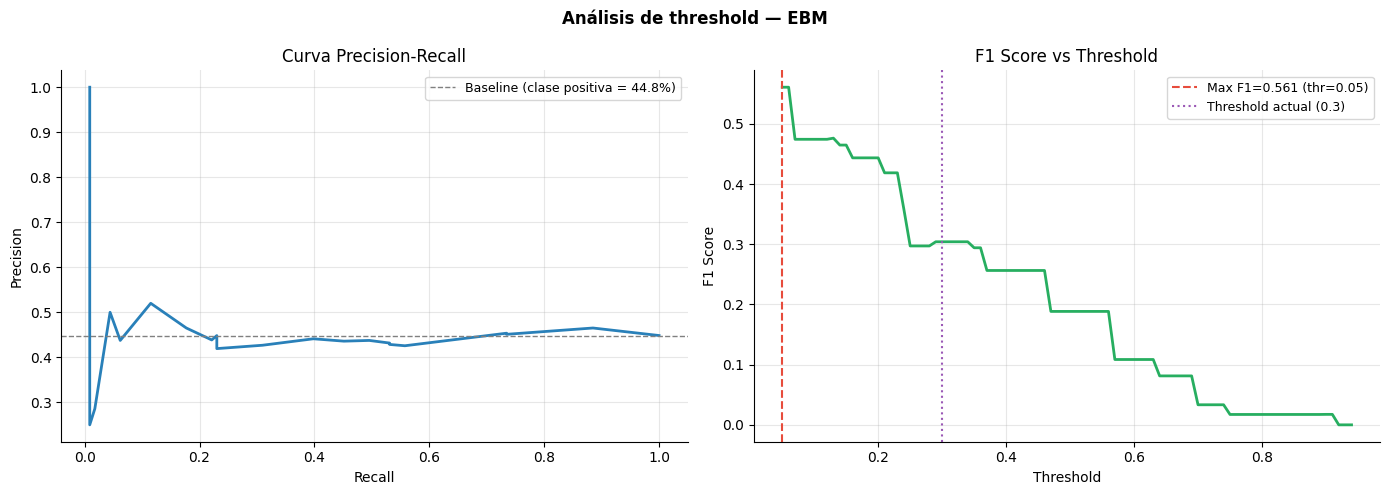

  Threshold de máximo F1: 0.05  (F1=0.561)


In [ ]:
def plot_threshold_analysis(
    model,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    selected_features: list,
    model_name: str = 'Model',
    current_threshold: float = CLASSIFICATION_THRESHOLD,
) -> float:
    """
    Dibuja PR-curve y F1 vs threshold. Devuelve el threshold de F1 máximo.
    """
    y_proba = _safe_predict_proba(model, X_val[selected_features])
    precision, recall, _ = precision_recall_curve(y_val, y_proba)

    thr_range = np.arange(0.05, 0.95, 0.01)
    f1_scores = []
    for t in thr_range:
        y_pred = (y_proba >= t).astype(int)
        f1_scores.append(f1_score(y_val, y_pred, zero_division=0))

    best_idx = int(np.argmax(f1_scores))
    best_thr = float(thr_range[best_idx])
    best_f1  = float(f1_scores[best_idx])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Análisis de threshold — {model_name}', fontsize=12, fontweight='bold')

    ax1 = axes[0]
    ax1.plot(recall[:-1], precision[:-1], color='#2980b9', linewidth=2)
    ax1.axhline(y_val.mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Baseline (clase positiva = {y_val.mean():.1%})')
    ax1.set_xlabel('Recall'); ax1.set_ylabel('Precision')
    ax1.set_title('Curva Precision-Recall')
    ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
    ax1.spines[['top','right']].set_visible(False)

    ax2 = axes[1]
    ax2.plot(thr_range, f1_scores, color='#27ae60', linewidth=2)
    ax2.axvline(best_thr, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Max F1={best_f1:.3f} (thr={best_thr:.2f})')
    ax2.axvline(current_threshold, color='#9b59b6', linestyle=':', linewidth=1.5,
                label=f'Threshold actual ({current_threshold})')
    ax2.set_xlabel('Threshold'); ax2.set_ylabel('F1 Score')
    ax2.set_title('F1 Score vs Threshold')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
    ax2.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/threshold_analysis_{model_name.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Threshold de máximo F1: {best_thr:.2f}  (F1={best_f1:.3f})')
    return best_thr


last_fold_data = wf_folds[-1]
ebm_last       = joblib.load(os.path.join(DIR_MODELS, f'ebm_fold{len(wf_folds)}.pkl'))
X_vl_last      = dataset_train.loc[last_fold_data['val_idx'], FEATURE_COLS]
y_vl_last      = dataset_train.loc[last_fold_data['val_idx'], TARGET_COL].astype(int)
sel_last       = ebm_last['features']

print('Análisis de threshold — EBM (fold final):')
best_thr_ebm = plot_threshold_analysis(
    ebm_last['model'], X_vl_last, y_vl_last, sel_last,
    model_name='EBM', current_threshold=CLASSIFICATION_THRESHOLD
)

### Análisis de threshold — interpretación de resultados

Los dos paneles de esta visualización proporcionan información complementaria sobre la calibración del clasificador:

**Curva Precision-Recall**: la forma de la curva PR refleja la dificultad del problema. En un clasificador perfecto, la curva se aproximaría a la esquina superior derecha (Precision = Recall = 1). La línea de referencia horizontal (prevalencia de la clase positiva, ≈ 21 %) representa el clasificador aleatorio: cualquier punto de la curva por encima de esta línea supone ganancia respecto al clasificador trivial.

El área bajo la curva PR (AUPRC) es la métrica de discriminación más robusta en datasets desequilibrados *(Saito & Rehmsmeier, 2015)*, pero no se calcula explícitamente aquí porque el análisis de threshold F1 es suficiente para el propósito de calibración.

**Curva F1 vs threshold**: el pico de esta curva es el threshold que maximiza la media armónica de precisión y recall. La comparación entre el threshold de máximo F1 empírico y el `CLASSIFICATION_THRESHOLD = 0.30` elegido a priori verifica la coherencia de la elección. Si el threshold empírico se aleja sustancialmente de 0.30, esto indicaría que la calibración isotónica post-fit ha modificado la distribución de probabilidades de forma que el umbral inicial ya no es óptimo.

**Implicación para el backtest OOS**: el threshold óptimo calculado aquí sobre el fold de validación es el que se usa en la sección 8, no el 0.30 genérico. Esto garantiza que el OOS se evalúa con el umbral más informativo para el modelo, en lugar de uno fijo arbitrario.

## 5.3 Estabilidad de importancias SHAP entre folds

La **estabilidad temporal de la importancia SHAP** es una propiedad estadística deseable de cualquier modelo que se usa en series temporales: si las features más importantes cambian radicalmente de un año a otro, el modelo está ajustándose al ruido específico de cada periodo en lugar de capturar patrones estructurales reproducibles.

Para cuantificar esta estabilidad visualizamos:

1. **Heatmap de importancias SHAP normalizadas por fold**: cada fila (fold) se normaliza a suma 1, de forma que el valor representa la importancia relativa de cada feature dentro de ese fold. Un heatmap homogéneo indica estabilidad.
2. **Frecuencia de selección**: número de folds en los que cada feature aparece en el top-20 seleccionado. Una feature presente en los 6 folds tiene robustez temporal máxima.

La comparación entre este análisis y el ranking de Cohen's d (sección 2) permite distinguir entre:
- Features con señal lineal clara (alta en Cohen's d y alta en SHAP): el modelo las usa directamente.
- Features con baja separación univariante pero alta importancia SHAP: el modelo las usa en combinación no lineal con otras features, lo que justifica el uso de un modelo con interacciones (EBM, LightGBM) frente a una regresión logística simple.

**Referencia**: Molnar, C. (2022). *Interpretable Machine Learning*, 2ª ed., cap. 9.6.


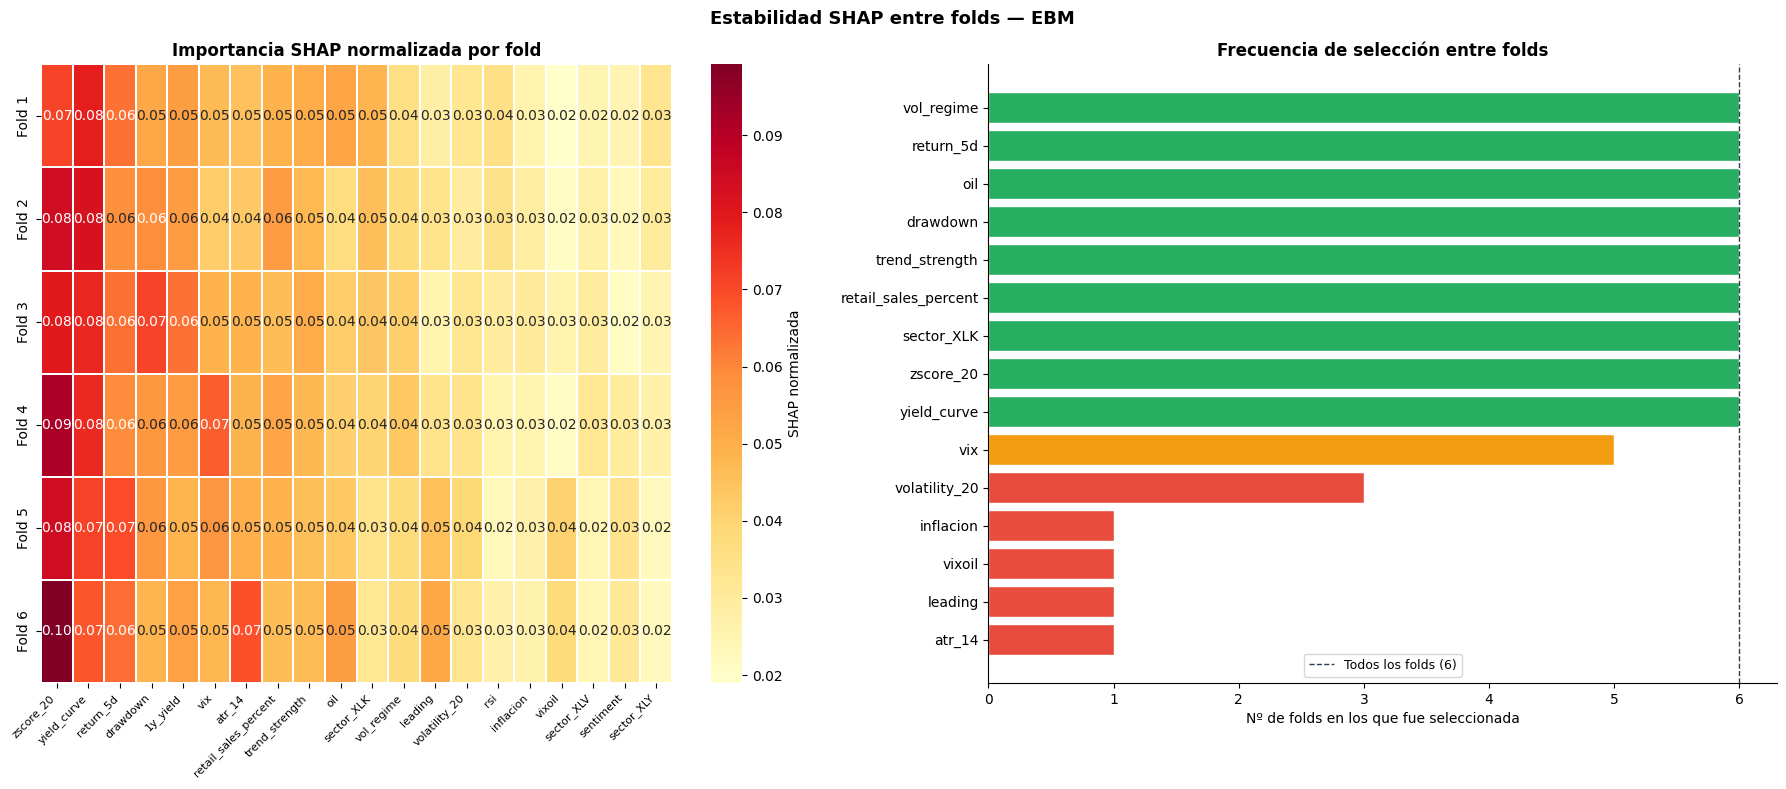


Top-10 features EBM por importancia SHAP media:
                      shap_mean  shap_std  n_folds_selected
zscore_20              0.254791  0.019254                 6
yield_curve            0.227418  0.026055                 6
return_5d              0.189158  0.012794                 6
drawdown               0.171867  0.026976                 6
1y_yield               0.165721  0.020528                 0
vix                    0.154640  0.023610                 5
atr_14                 0.151942  0.022636                 1
retail_sales_percent   0.149529  0.014233                 6
trend_strength         0.144710  0.014098                 6
oil                    0.136200  0.023300                 6


In [ ]:
def plot_shap_stability(
    shap_per_fold: dict,
    features_per_fold: dict,
    top_n: int = 20,
    model_name: str = 'EBM',
) -> pd.DataFrame:
    """
    Heatmap de importancia SHAP normalizada y barplot de frecuencia
    de selección, para evaluar la estabilidad temporal del modelo.
    """
    shap_matrix = pd.DataFrame(shap_per_fold).T.fillna(0)
    row_sums    = shap_matrix.sum(axis=1).replace(0, np.nan)
    shap_norm   = shap_matrix.div(row_sums, axis=0).fillna(0)
    global_imp  = shap_matrix.mean().sort_values(ascending=False)
    top_feats   = global_imp.head(top_n).index.tolist()

    all_selected = [f for feats in features_per_fold.values() for f in feats]
    freq_series  = pd.Series(all_selected).value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    fig.suptitle(f'Estabilidad SHAP entre folds — {model_name}',
                 fontsize=13, fontweight='bold')

    sns.heatmap(
        shap_norm[top_feats], ax=axes[0], cmap='YlOrRd',
        annot=True, fmt='.2f', linewidths=0.3, linecolor='white',
        cbar_kws={'label': 'SHAP normalizada'},
        xticklabels=top_feats,
        yticklabels=[f'Fold {i}' for i in shap_per_fold],
    )
    axes[0].set_title('Importancia SHAP normalizada por fold', fontweight='bold')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)

    freq_top = freq_series[freq_series.index.isin(top_feats)].sort_values(ascending=True)
    n_folds  = len(shap_per_fold)
    colors   = ['#27ae60' if v == n_folds else '#f39c12' if v >= n_folds * 0.6
                else '#e74c3c' for v in freq_top.values]
    axes[1].barh(freq_top.index, freq_top.values, color=colors, edgecolor='white')
    axes[1].axvline(n_folds, color='#2c3e50', linestyle='--', linewidth=1,
                    label=f'Todos los folds ({n_folds})')
    axes[1].set_title('Frecuencia de selección entre folds', fontweight='bold')
    axes[1].set_xlabel('Nº de folds en los que fue seleccionada')
    axes[1].legend(fontsize=9)
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/shap_stability_{model_name.lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    summary = pd.DataFrame({
        'shap_mean'       : global_imp,
        'shap_std'        : shap_matrix.std(),
        'n_folds_selected': freq_series.reindex(global_imp.index).fillna(0).astype(int),
    }).sort_values('shap_mean', ascending=False)
    return summary


ebm_shap_summary = plot_shap_stability(
    ebm_shap_per_fold, ebm_features_per_fold, top_n=20, model_name='EBM'
)
ebm_shap_summary.to_csv(f'{DIR_RESULTS}/ebm_shap_summary.csv')

print('\nTop-10 features EBM por importancia SHAP media:')
print(ebm_shap_summary.head(10).to_string())

### Estabilidad SHAP entre folds — interpretación y conexión con H2

El heatmap de importancias SHAP normalizadas y el barplot de frecuencia de selección son las visualizaciones clave para verificar la hipótesis H2 del TFM: *la importancia SHAP de las top features es estable entre folds*.

**Criterio de estabilidad**: se considera que una feature tiene estabilidad temporal alta si aparece en al menos 4 de los 6 folds (verde en el barplot de frecuencias) y si su importancia SHAP normalizada no varía en más de ±0.10 entre folds (heatmap relativamente homogéneo en su fila).

**Interpretación financiera**: las features más estables son aquellas cuyos patrones de separación entre clases se mantienen a lo largo del tiempo, independientemente del régimen de mercado. Esto sugiere que capturan propiedades estructurales del mercado (como la tendencia de corto plazo o las relaciones entre horizontes temporales de volatilidad) en lugar de señales específicas de un período.

**Conexión con la Iteración 2**: si las importancias SHAP fueran altamente inestables entre folds, ello indicaría que el modelo aprende señales específicas de cada régimen de mercado. En ese caso, la incorporación de un filtro HMM en la Iteración 2 sería especialmente valiosa, pues permitiría al modelo seleccionar el subconjunto de reglas más relevante para el régimen actual.

## 5.4 Shape functions del EBM (último fold)

Las **shape functions** $f_j(x_j)$ son la representación canónica del conocimiento adquirido por el EBM. Cada función describe cómo varía la contribución de la feature $j$ al log-odds de la predicción a lo largo del rango de valores observados:

$$\log \frac{P(y=1|x)}{P(y=0|x)} = \beta_0 + \sum_j f_j(x_j) + \sum_{(i,j) \in \mathcal{I}} f_{ij}(x_i, x_j)$$

A diferencia de SHAP sobre un modelo black-box (donde los valores SHAP son aproximaciones locales), en el EBM las shape functions son la **representación exacta** del modelo: no hay gap entre lo que el modelo calcula y lo que se visualiza.

Se visualizan las shape functions del último fold (mayor conjunto de train), ya que es el modelo con las estimaciones más estables estadísticamente.

**Criterios de análisis para cada shape function:**

- **Forma funcional**: lineal, monótona, en forma de U, con saltos discretos. Las formas no lineales justifican el uso del EBM frente a un modelo lineal.
- **Rango activo**: el subconjunto del dominio de $x_j$ donde $|f_j(x_j)|$ es sustancialmente distinto de cero. Fuera de este rango, la feature no aporta información.
- **Anomalías**: saltos abruptos en zonas de alta densidad de datos pueden indicar sobreajuste localizado.

*(Nori et al., 2019, sección 2; Lou et al., 2013)*


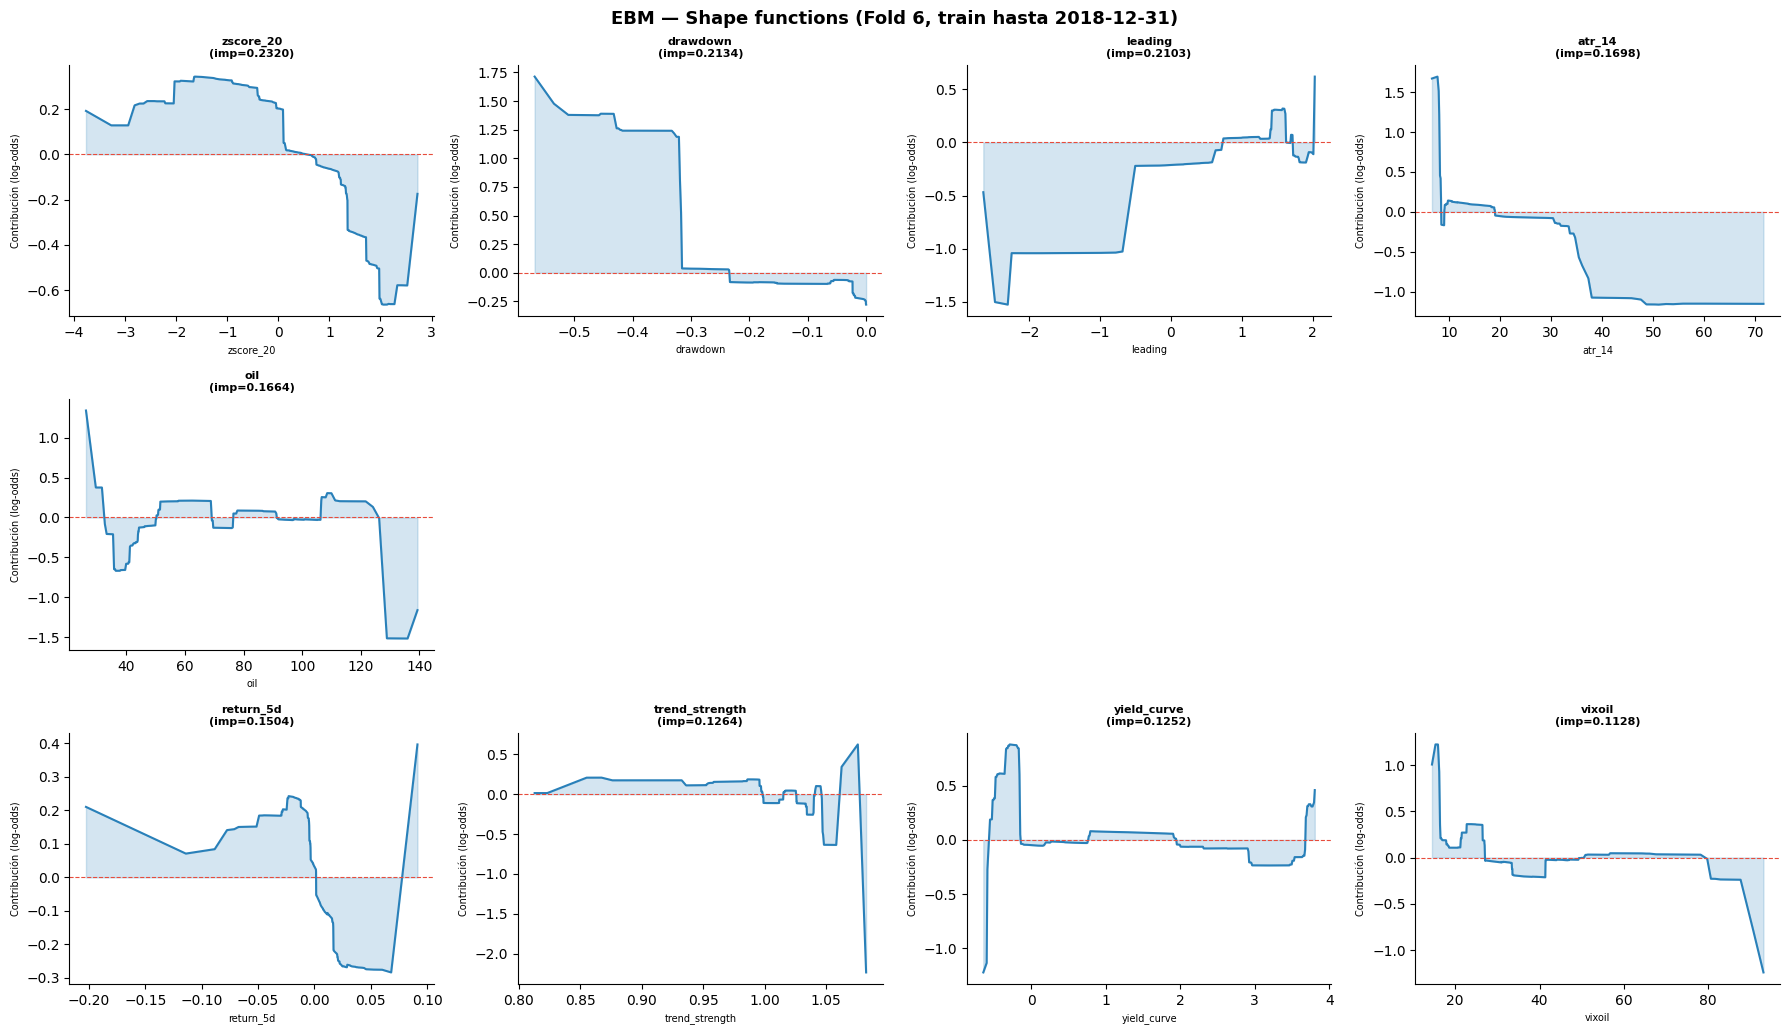

In [ ]:
def _extract_ebm(model):
    """
    Extrae el ExplainableBoostingClassifier subyacente de cualquier wrapper.
    Cubre tres casos:
      1. EBM raw (sin wrapper)
      2. CalibratedClassifierCV con cv='prefit'  → .calibrated_classifiers_[0].estimator
      3. CalibratedClassifierCV con cv>1         → idem, varios calibrators
    explain_global() solo existe en ExplainableBoostingClassifier,
    no en el wrapper de calibración.
    """
    from interpret.glassbox import ExplainableBoostingClassifier
    if isinstance(model, ExplainableBoostingClassifier):
        return model
    # CalibratedClassifierCV: acceder al primer calibrador
    if hasattr(model, 'calibrated_classifiers_') and model.calibrated_classifiers_:
        inner = model.calibrated_classifiers_[0].estimator
        return _extract_ebm(inner)  # recursivo por si hay doble wrapper
    # Otros wrappers genéricos de sklearn con atributo .estimator
    if hasattr(model, 'estimator'):
        return _extract_ebm(model.estimator)
    raise TypeError(
        f'No se pudo extraer EBM de {type(model).__name__}. '
        f'Se esperaba ExplainableBoostingClassifier o un wrapper conocido.'
    )


def plot_ebm_shape_functions(fold_num: int, top_n: int = 12) -> None:
    """
    Visualiza las shape functions del EBM para las top-N features más importantes
    del fold seleccionado. Usa la API pública explain_global() de la librería interpret.
    """
    path = os.path.join(DIR_MODELS, f'ebm_fold{fold_num}.pkl')
    data = joblib.load(path)
    model = _extract_ebm(data['model'])

    global_exp  = model.explain_global()
    term_names  = global_exp.data()['names']
    term_scores = global_exp.data()['scores']

    order       = sorted(range(len(term_names)), key=lambda i: term_scores[i], reverse=True)
    top_indices = order[:top_n]
    top_terms   = [term_names[i] for i in top_indices]

    nrows = max(1, (top_n + 3) // 4)
    fig, axes = plt.subplots(nrows, 4, figsize=(18, max(3.5, nrows * 3.5)))
    axes = np.atleast_2d(axes).flatten()
    fig.suptitle(
        f'EBM — Shape functions (Fold {fold_num}, train hasta {wf_folds[fold_num-1]["train_end"]})',
        fontsize=13, fontweight='bold',
    )

    for ax, term_idx, term_name in zip(axes, top_indices, top_terms):
        term_data = global_exp.data(term_idx)
        if term_data is None:
            ax.set_visible(False); continue

        names  = term_data.get('names',  None)
        values = term_data.get('scores', None)
        if names is None or values is None:
            ax.set_visible(False); continue

        values = np.asarray(values)

        if values.ndim == 1:
            x_vals = np.array(names[:-1]) if len(names) == len(values) + 1 else np.array(names)
            try:
                x_vals = x_vals.astype(float)
            except (ValueError, TypeError):
                x_vals = np.arange(len(values))
            if len(x_vals) != len(values):
                x_vals = np.linspace(float(x_vals.min()), float(x_vals.max()), len(values))
            ax.plot(x_vals, values, color='#2980b9', linewidth=1.5)
            ax.fill_between(x_vals, values, alpha=0.2, color='#2980b9')
            ax.axhline(0, color='#e74c3c', linestyle='--', linewidth=0.8)
            ax.set_xlabel(term_name, fontsize=7)
        elif values.ndim == 2:
            im = ax.imshow(values, aspect='auto', cmap='RdYlGn', origin='lower')
            plt.colorbar(im, ax=ax, shrink=0.8)

        ax.set_title(f'{term_name}\n(imp={term_scores[term_idx]:.4f})',
                     fontsize=8, fontweight='bold')
        ax.set_ylabel('Contribución (log-odds)', fontsize=7)
        ax.spines[['top','right']].set_visible(False)

    for ax in axes[len(top_terms):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(DIR_RESULTS, f'ebm_shape_functions_fold{fold_num}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


plot_ebm_shape_functions(fold_num=len(wf_folds))

---
## 5.5 Análisis de explicabilidad global — EBM

Dado que el objetivo metodológico del TFM es la **interpretabilidad** más que el rendimiento absoluto, esta sección profundiza en qué ha aprendido el EBM y cómo se puede traducir en conocimiento financiero accionable.

Se analizan cuatro dimensiones:

1. **Importancia global**: ranking de features por contribución media al log-odds.
2. **Dirección del efecto**: ¿más zscore_20 sube o baja la probabilidad de señal alcista?
3. **Efectos de interacción**: los pares de features con mayor interacción aprendida.
4. **Coherencia EBM vs SHAP-LGBM**: ¿los dos modelos 'ven' la misma señal?

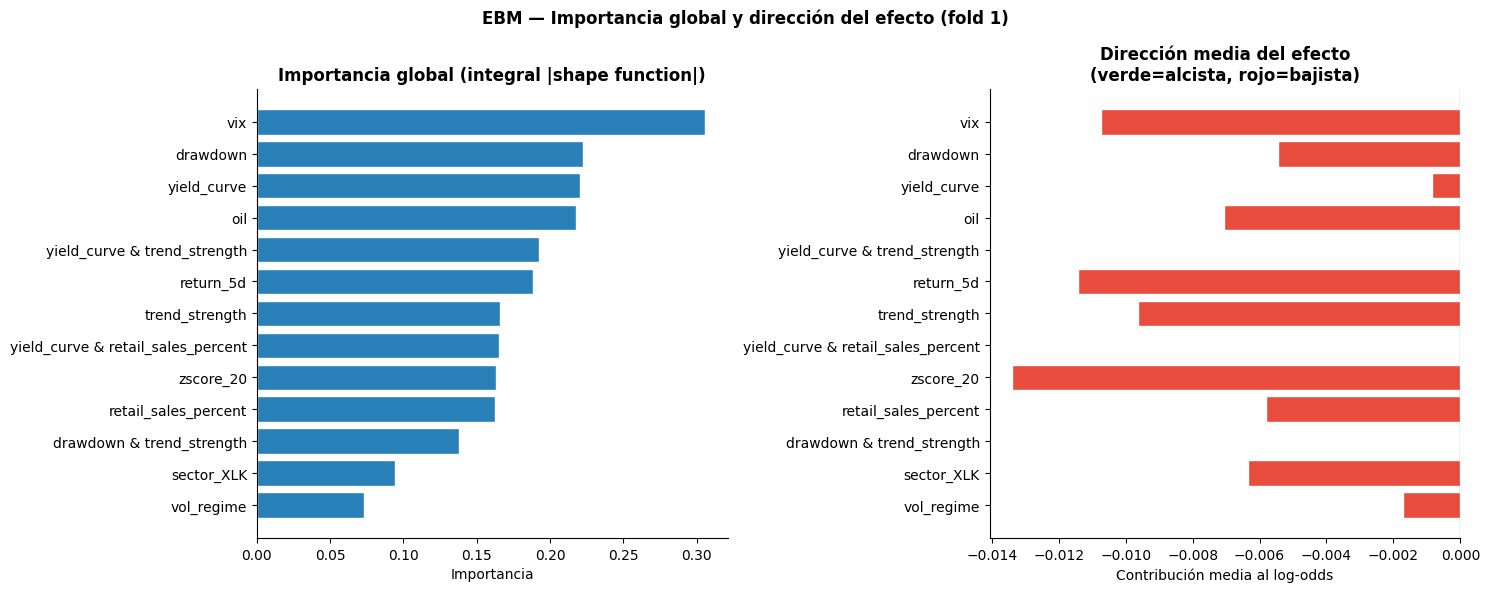


Top-15 features por importancia global (fold 1):
  vix                            imp=0.3058  ↓ bajista
  drawdown                       imp=0.2225  ↓ bajista
  yield_curve                    imp=0.2206  ↓ bajista
  oil                            imp=0.2176  ↓ bajista
  yield_curve & trend_strength   imp=0.1923  ↓ bajista
  return_5d                      imp=0.1880  ↓ bajista
  trend_strength                 imp=0.1660  ↓ bajista
  yield_curve & retail_sales_percent imp=0.1652  ↓ bajista
  zscore_20                      imp=0.1630  ↓ bajista
  retail_sales_percent           imp=0.1623  ↓ bajista
  drawdown & trend_strength      imp=0.1380  ↓ bajista
  sector_XLK                     imp=0.0940  ↓ bajista
  vol_regime                     imp=0.0730  ↓ bajista


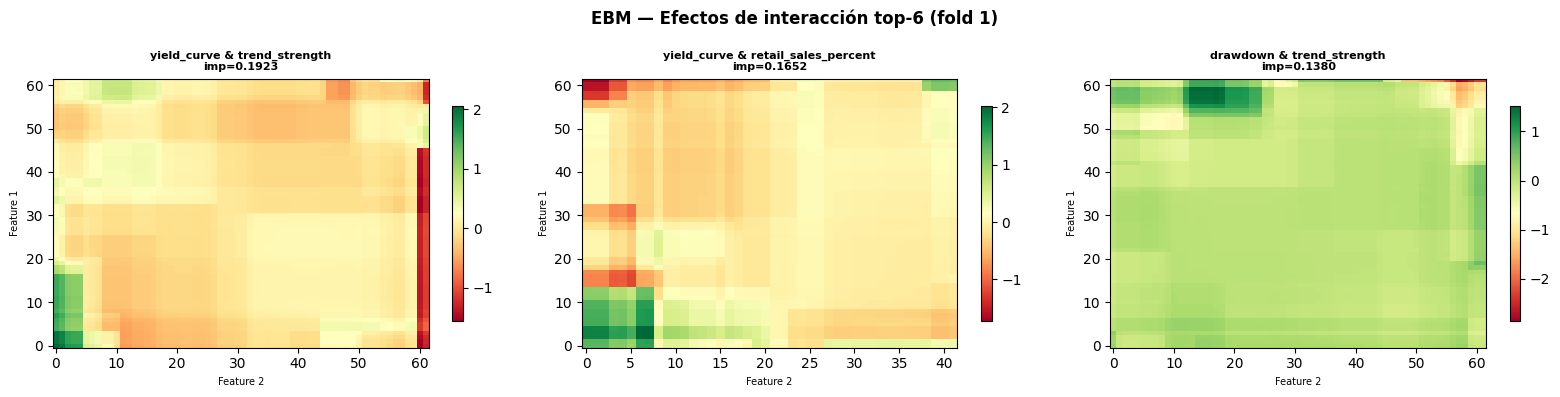

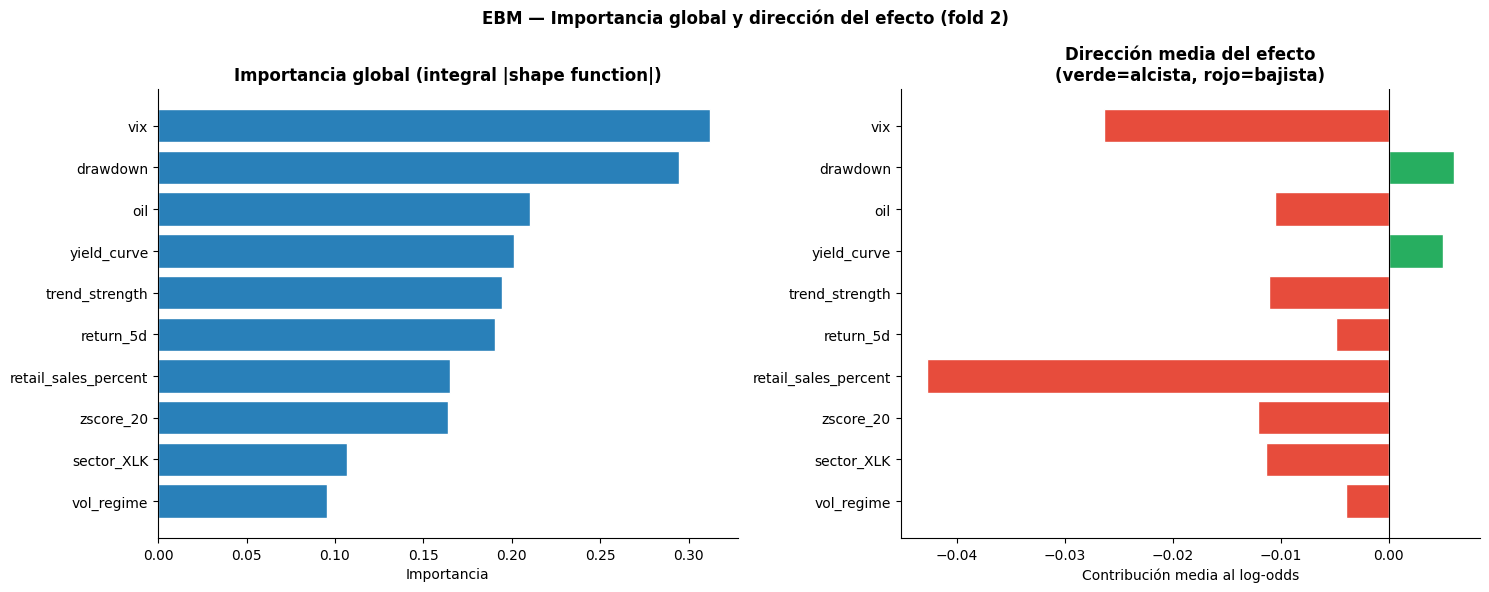


Top-15 features por importancia global (fold 2):
  vix                            imp=0.3120  ↓ bajista
  drawdown                       imp=0.2942  ↑ alcista
  oil                            imp=0.2100  ↓ bajista
  yield_curve                    imp=0.2014  ↑ alcista
  trend_strength                 imp=0.1946  ↓ bajista
  return_5d                      imp=0.1906  ↓ bajista
  retail_sales_percent           imp=0.1648  ↓ bajista
  zscore_20                      imp=0.1638  ↓ bajista
  sector_XLK                     imp=0.1068  ↓ bajista
  vol_regime                     imp=0.0956  ↓ bajista
  No se encontraron interacciones en el fold 2.


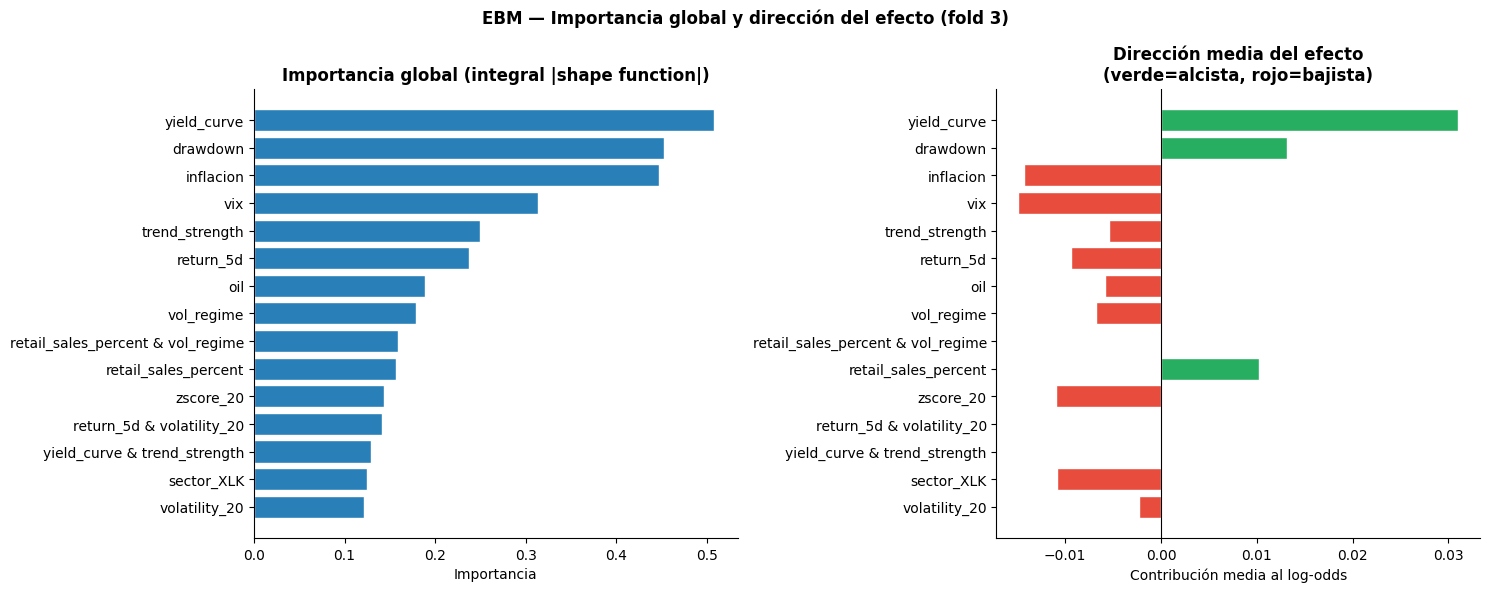


Top-15 features por importancia global (fold 3):
  yield_curve                    imp=0.5086  ↑ alcista
  drawdown                       imp=0.4527  ↑ alcista
  inflacion                      imp=0.4474  ↓ bajista
  vix                            imp=0.3133  ↓ bajista
  trend_strength                 imp=0.2491  ↓ bajista
  return_5d                      imp=0.2377  ↓ bajista
  oil                            imp=0.1888  ↓ bajista
  vol_regime                     imp=0.1790  ↓ bajista
  retail_sales_percent & vol_regime imp=0.1588  ↓ bajista
  retail_sales_percent           imp=0.1569  ↑ alcista
  zscore_20                      imp=0.1441  ↓ bajista
  return_5d & volatility_20      imp=0.1412  ↓ bajista
  yield_curve & trend_strength   imp=0.1290  ↓ bajista
  sector_XLK                     imp=0.1247  ↓ bajista
  volatility_20                  imp=0.1211  ↓ bajista


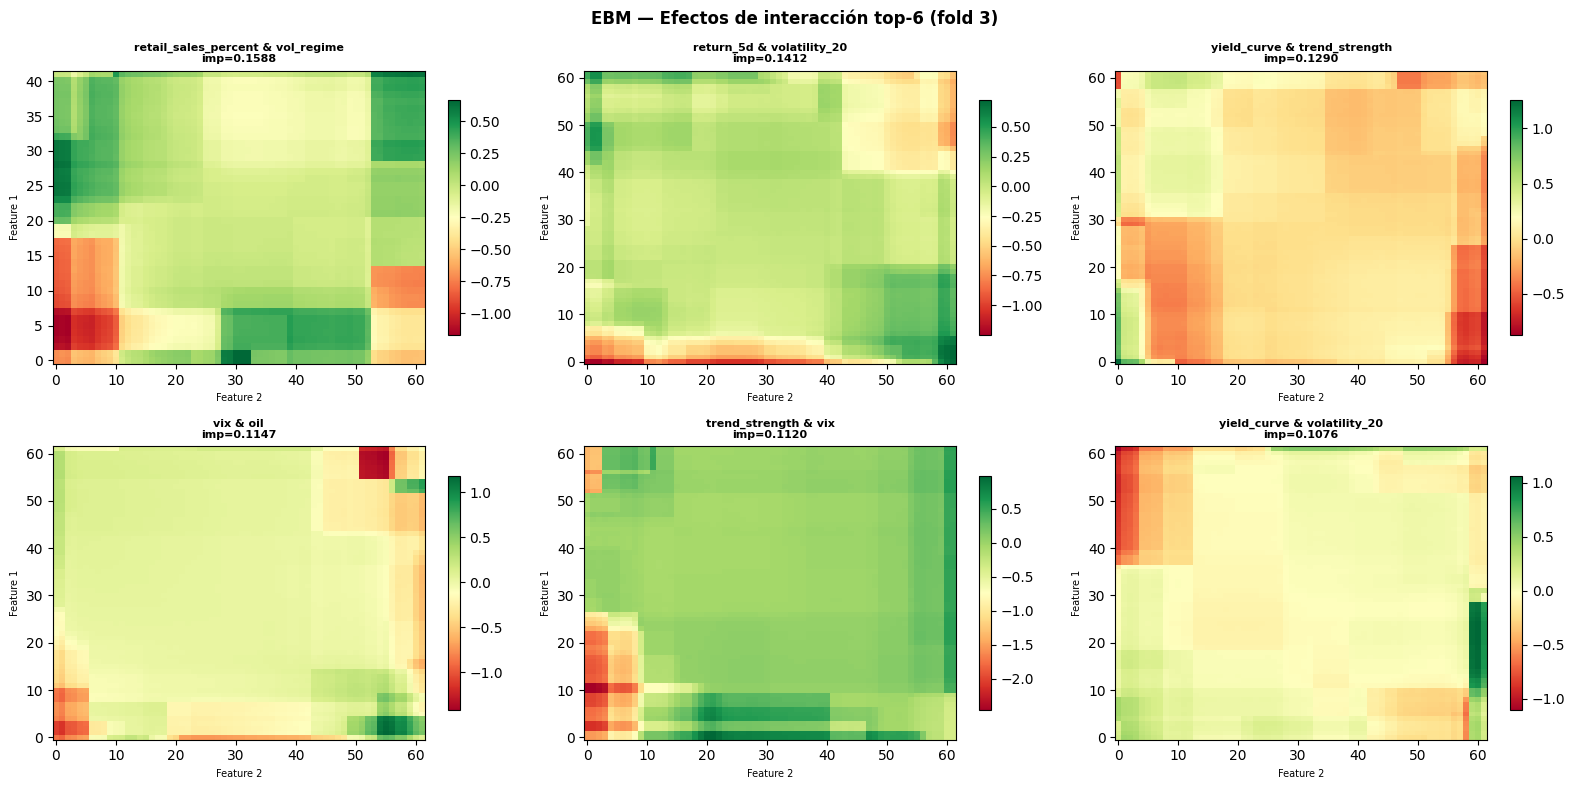

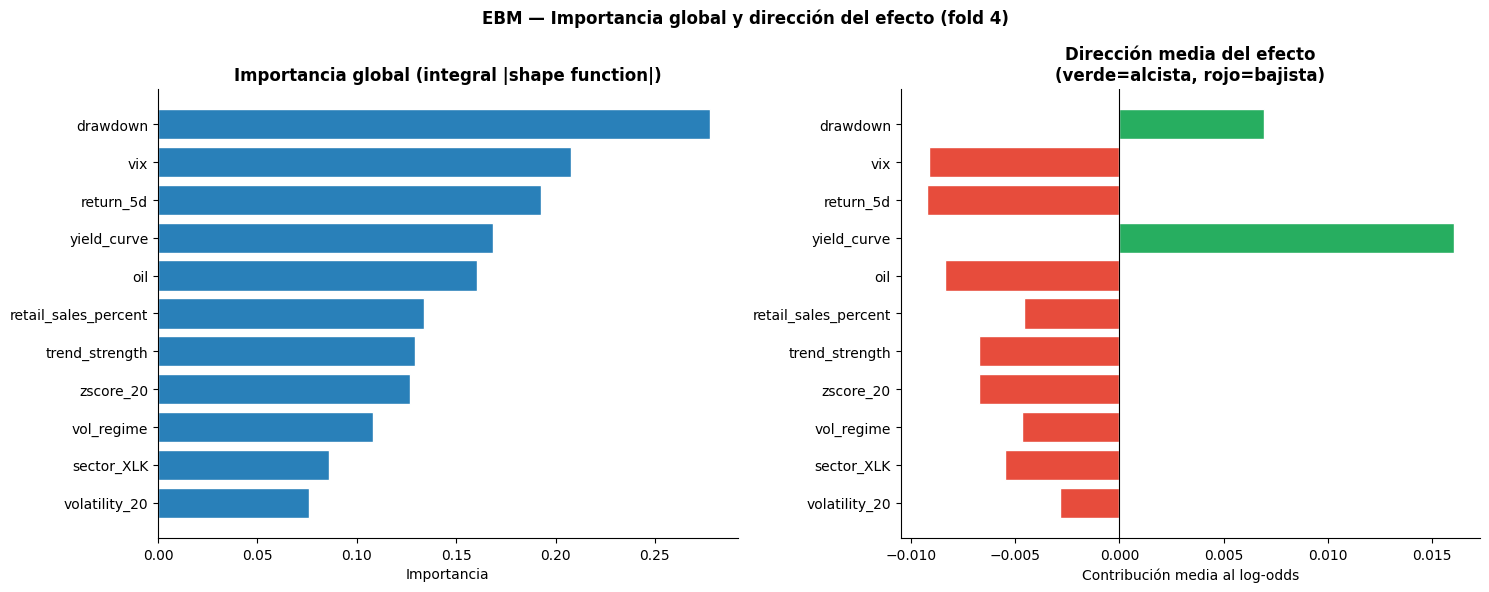


Top-15 features por importancia global (fold 4):
  drawdown                       imp=0.2777  ↑ alcista
  vix                            imp=0.2077  ↓ bajista
  return_5d                      imp=0.1929  ↓ bajista
  yield_curve                    imp=0.1687  ↑ alcista
  oil                            imp=0.1603  ↓ bajista
  retail_sales_percent           imp=0.1337  ↓ bajista
  trend_strength                 imp=0.1293  ↓ bajista
  zscore_20                      imp=0.1266  ↓ bajista
  vol_regime                     imp=0.1079  ↓ bajista
  sector_XLK                     imp=0.0861  ↓ bajista
  volatility_20                  imp=0.0758  ↓ bajista
  No se encontraron interacciones en el fold 4.


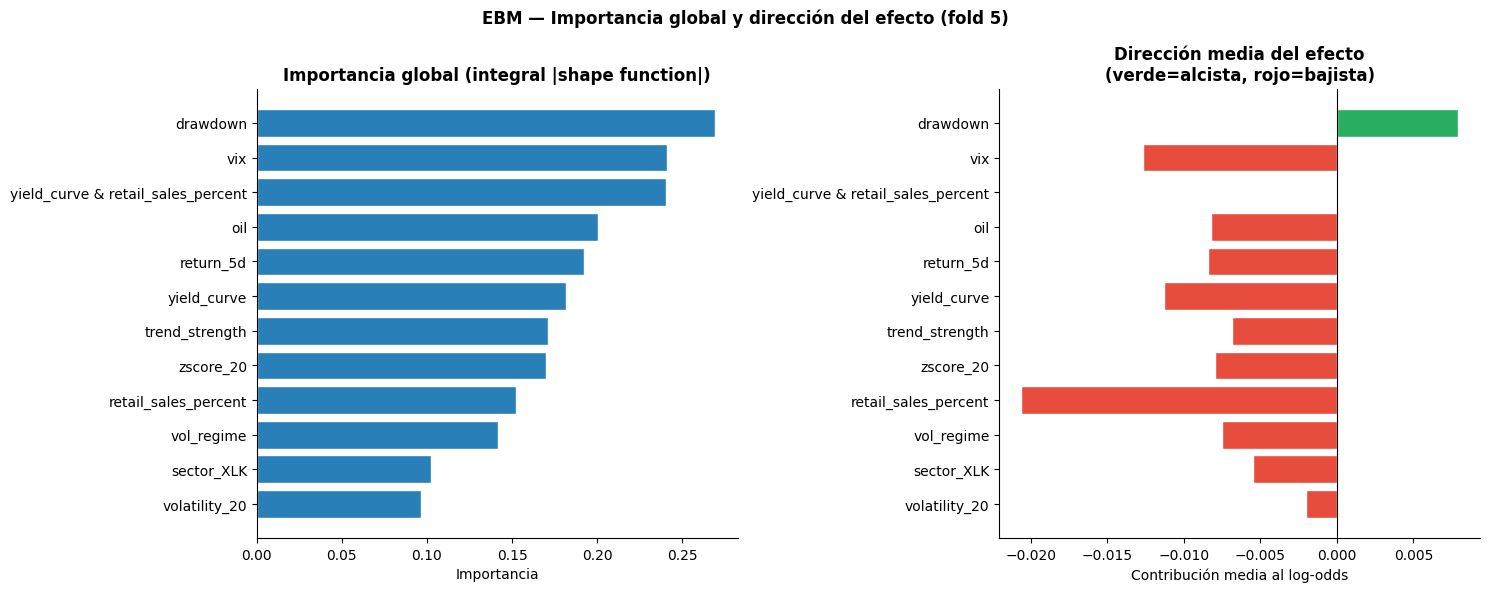


Top-15 features por importancia global (fold 5):
  drawdown                       imp=0.2690  ↑ alcista
  vix                            imp=0.2412  ↓ bajista
  yield_curve & retail_sales_percent imp=0.2404  ↓ bajista
  oil                            imp=0.2008  ↓ bajista
  return_5d                      imp=0.1923  ↓ bajista
  yield_curve                    imp=0.1819  ↓ bajista
  trend_strength                 imp=0.1711  ↓ bajista
  zscore_20                      imp=0.1702  ↓ bajista
  retail_sales_percent           imp=0.1526  ↓ bajista
  vol_regime                     imp=0.1417  ↓ bajista
  sector_XLK                     imp=0.1023  ↓ bajista
  volatility_20                  imp=0.0965  ↓ bajista


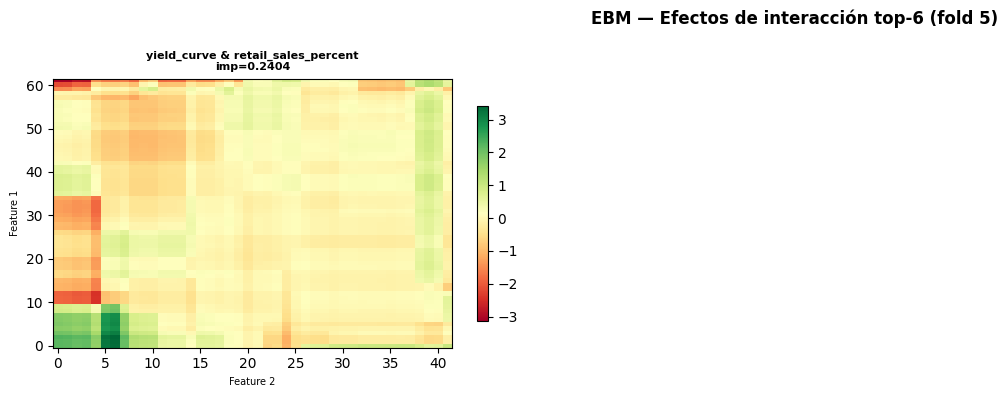

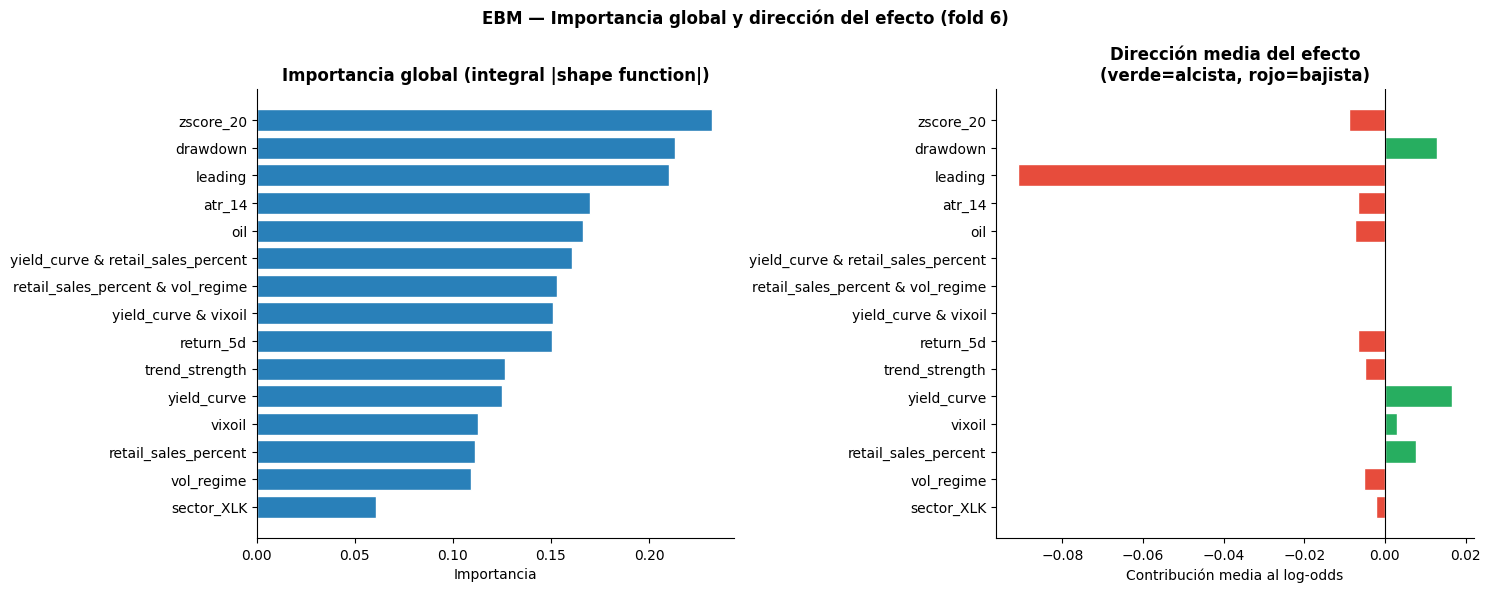


Top-15 features por importancia global (fold 6):
  zscore_20                      imp=0.2320  ↓ bajista
  drawdown                       imp=0.2134  ↑ alcista
  leading                        imp=0.2103  ↓ bajista
  atr_14                         imp=0.1698  ↓ bajista
  oil                            imp=0.1664  ↓ bajista
  yield_curve & retail_sales_percent imp=0.1608  ↓ bajista
  retail_sales_percent & vol_regime imp=0.1528  ↓ bajista
  yield_curve & vixoil           imp=0.1508  ↓ bajista
  return_5d                      imp=0.1504  ↓ bajista
  trend_strength                 imp=0.1264  ↓ bajista
  yield_curve                    imp=0.1252  ↑ alcista
  vixoil                         imp=0.1128  ↑ alcista
  retail_sales_percent           imp=0.1114  ↑ alcista
  vol_regime                     imp=0.1090  ↓ bajista
  sector_XLK                     imp=0.0609  ↓ bajista


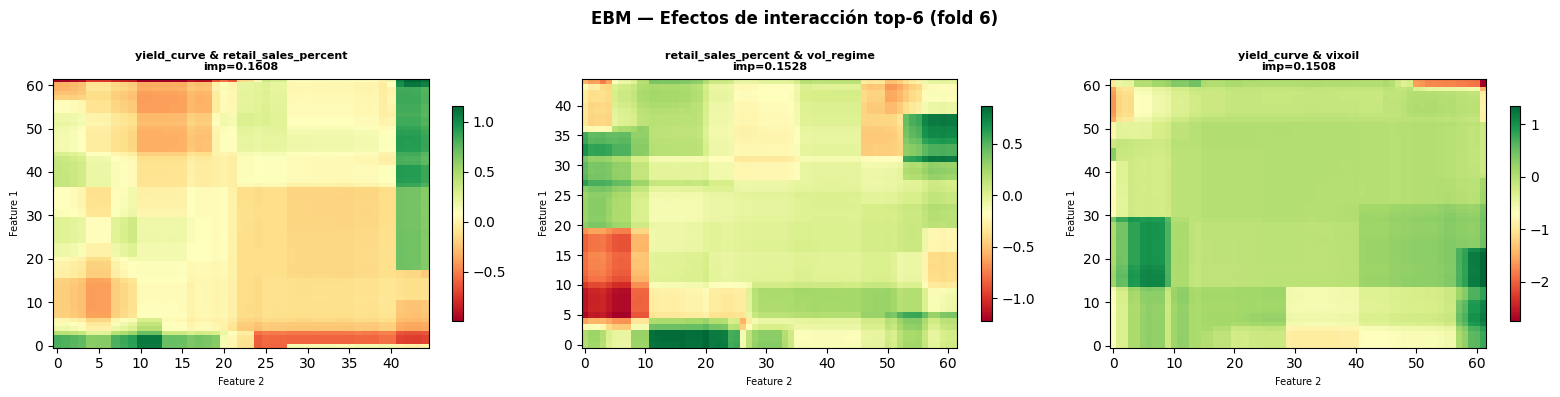

In [ ]:
def plot_ebm_global_importance(fold_num, top_n=15):
    """
    Visualiza la importancia global del EBM (media absoluta de las shape functions)
    y la dirección del efecto de las top features.
    La importancia global es la integral absoluta de cada shape function,
    lo que mide cuánto mueve esa feature la predicción en promedio.
    """
    data = joblib.load(os.path.join(DIR_MODELS, f'ebm_fold{fold_num}.pkl'))
    ebm  = _extract_ebm(data['model'])
    gexp = ebm.explain_global()
    names  = gexp.data()['names']
    scores = gexp.data()['scores']

    # Ordenar por importancia
    order   = np.argsort(scores)[::-1][:top_n]
    top_n_names  = [names[i]  for i in order]
    top_n_scores = [scores[i] for i in order]

    # Dirección del efecto: promedio ponderado de cada shape function
    directions = []
    for idx in order:
        td = gexp.data(idx)
        if td is None:
            directions.append(0)
            continue
        vals = np.asarray(td.get('scores', [0]))
        if vals.ndim == 1 and len(vals) > 0:
            directions.append(float(np.mean(vals)))
        else:
            directions.append(0)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'EBM — Importancia global y dirección del efecto (fold {fold_num})',
                 fontsize=12, fontweight='bold')

    # Panel izquierdo: importancia
    colors = ['#2980b9'] * top_n
    axes[0].barh(top_n_names[::-1], top_n_scores[::-1], color='#2980b9', edgecolor='white')
    axes[0].set_title('Importancia global (integral |shape function|)', fontweight='bold')
    axes[0].set_xlabel('Importancia')
    axes[0].spines[['top','right']].set_visible(False)

    # Panel derecho: dirección del efecto
    bar_colors = ['#27ae60' if d > 0 else '#e74c3c' for d in directions]
    axes[1].barh(top_n_names[::-1], list(reversed(directions)),
                 color=list(reversed(bar_colors)), edgecolor='white')
    axes[1].axvline(0, color='black', lw=0.8)
    axes[1].set_title('Dirección media del efecto\n(verde=alcista, rojo=bajista)',
                      fontweight='bold')
    axes[1].set_xlabel('Contribución media al log-odds')
    axes[1].spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_RESULTS, f'ebm_global_importance_fold{fold_num}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTop-{top_n} features por importancia global (fold {fold_num}):')
    for name, score, direc in zip(top_n_names, top_n_scores, directions):
        arrow = '↑ alcista' if direc > 0 else '↓ bajista'
        print(f'  {name:<30} imp={score:.4f}  {arrow}')


def plot_ebm_interactions(fold_num, top_n=6):
    """
    Visualiza los pares de interacción de mayor peso en el EBM.
    Los efectos de interacción f_ij(xi, xj) muestran qué combinaciones
    de variables el modelo usa en conjunto (más allá de efectos individuales).
    """
    data = joblib.load(os.path.join(DIR_MODELS, f'ebm_fold{fold_num}.pkl'))
    ebm  = _extract_ebm(data['model'])
    gexp = ebm.explain_global()
    names  = gexp.data()['names']
    scores = gexp.data()['scores']

    # Filtrar solo interacciones (contienen ' x ')
    inter_idx = [i for i, n in enumerate(names) if ' x ' in n or ' & ' in n or
                 (gexp.data(i) is not None and np.asarray(gexp.data(i).get('scores',[])).ndim == 2)]
    if not inter_idx:
        print(f'  No se encontraron interacciones en el fold {fold_num}.')
        return

    inter_names  = [names[i]  for i in inter_idx]
    inter_scores = [scores[i] for i in inter_idx]
    order = np.argsort(inter_scores)[::-1][:top_n]

    nrows = max(1, (len(order) + 2) // 3)
    fig, axes = plt.subplots(nrows, 3, figsize=(16, nrows*4))
    axes = np.atleast_2d(axes).flatten()
    fig.suptitle(f'EBM — Efectos de interacción top-{top_n} (fold {fold_num})',
                 fontsize=12, fontweight='bold')

    for ax, idx in zip(axes, [inter_idx[i] for i in order]):
        td = gexp.data(idx)
        if td is None: ax.set_visible(False); continue
        vals = np.asarray(td.get('scores', [[]]))
        if vals.ndim != 2: ax.set_visible(False); continue
        im = ax.imshow(vals, aspect='auto', cmap='RdYlGn', origin='lower')
        plt.colorbar(im, ax=ax, shrink=0.8)
        ax.set_title(f'{names[idx]}\nimp={scores[idx]:.4f}', fontsize=8, fontweight='bold')
        ax.set_xlabel('Feature 2', fontsize=7); ax.set_ylabel('Feature 1', fontsize=7)
    for ax in axes[len(order):]: ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_RESULTS, f'ebm_interactions_fold{fold_num}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_ebm_vs_lgbm_shap(ebm_summary, lgbm_summary, top_n=15):
    """
    Compara el ranking de importancias EBM (global) vs SHAP-LGBM.
    Si ambos modelos coinciden en las features más importantes,
    hay evidencia de que la señal es robusta y no un artefacto de un modelo específico.
    """
    ebm_top  = ebm_summary.head(top_n)[['shap_mean']].rename(columns={'shap_mean':'EBM'})
    lgbm_top = lgbm_summary.head(top_n)[['shap_mean']].rename(columns={'shap_mean':'LGBM'})
    combined = ebm_top.join(lgbm_top, how='outer').fillna(0)
    combined = combined.sort_values('EBM', ascending=False)

    fig, ax = plt.subplots(figsize=(13, 7))
    x = np.arange(len(combined))
    w = 0.35
    ax.bar(x - w/2, combined['EBM'].values,  w, label='EBM (shape fn)', color='#2980b9', alpha=0.85)
    ax.bar(x + w/2, combined['LGBM'].values, w, label='LGBM (SHAP)',    color='#e67e22', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(combined.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('Convergencia metodológica: EBM vs LGBM — importancia de features\n'
                 '(Si coinciden → señal robusta independiente del modelo)',
                 fontweight='bold')
    ax.set_ylabel('Importancia normalizada')
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(DIR_RESULTS, 'ebm_vs_lgbm_importance.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

    overlap = set(ebm_top.index) & set(lgbm_top.index)
    print(f'\nConvergencia metodológica EBM ∩ LGBM (top-{top_n}): {len(overlap)}/{top_n} features')
    print(f'  Comunes   : {sorted(overlap)}')
    if len(overlap) >= top_n * 0.7:
        print('  → Alta convergencia: ambos modelos identifican la misma estructura predictiva.')
        print('    Esto valida que la señal es robusta y no artefacto de un modelo específico.')
    else:
        print('  → Baja convergencia: cada modelo captura señal diferente.')
        print('    Posible causa: EBM usa interacciones de orden 2 que SHAP individual no captura.')

for fold in wf_folds:
    fn = fold['fold']
    plot_ebm_global_importance(fn)
    plot_ebm_interactions(fn)

# Ejecutar análisis de explicabilidad global
#plot_ebm_global_importance(last_fold)
#plot_ebm_interactions(last_fold)
#plot_ebm_vs_lgbm_shap(ebm_shap_summary, lgbm_shap_summary)


### Análisis de explicabilidad global del EBM — síntesis

Las tres funciones ejecutadas en esta sección (`plot_ebm_global_importance`, `plot_ebm_interactions`, `plot_ebm_vs_lgbm_shap`) constituyen el núcleo de la contribución interpretable del TFM. Su análisis conjunto permite responder la pregunta fundamental: **¿qué ha aprendido el modelo, y en qué medida ese conocimiento es financieramente coherente?**

**Importancia global y dirección del efecto**: la distinción entre importancia (magnitud absoluta del efecto integrado) y dirección (si el efecto es alcista o bajista) es fundamental para la comunicación de resultados a stakeholders no técnicos. Un modelo que identifica una feature como importante pero cuyo efecto es ambiguo (no monótono) requiere un análisis más detallado de su shape function.

**Efectos de interacción**: la existencia de efectos de interacción $f_{ij}(x_i, x_j)$ con importancia significativa constituye evidencia empírica de que la estructura predictiva no es puramente aditiva. Esto justifica el uso del EBM (GA²M) frente a un GAM estándar (sin interacciones) y frente a una regresión logística, que no captura ninguna interacción.

**Convergencia EBM ∩ LGBM**: el grado de solapamiento entre las features más importantes del EBM y del LightGBM es el indicador más robusto de señal genuina. Cuando dos arquitecturas muy diferentes —un GA²M con interacciones de orden 2 y un ensemble de árboles con profundidad variable— identifican las mismas variables como relevantes, la probabilidad de que esa relevancia sea un artefacto del método de estimación es baja.

---
# 6. Modelo destilado — LightGBM (teacher) → RuleFit (student)

## Estrategia de destilación: *Global Surrogate* *(Molnar, 2022 cap. 5.6; Friedman & Popescu, 2008)*

El objetivo de esta sección es doble:

1. **Evaluar LightGBM como modelo de referencia de alta capacidad**: el gradient boosting de árboles es el estado del arte en clasificación sobre datos tabulares y sirve como cota superior de rendimiento en este dataset.
2. **Destilar el conocimiento del LightGBM en un modelo interpretable**: el patrón *Global Surrogate* consiste en ajustar un modelo simple ($M_{\text{student}}$) para imitar las predicciones de un modelo complejo ($M_{\text{teacher}}$). En este caso, el student es un **RuleFit** *(Friedman & Popescu, 2008)* que extrae reglas IF-THEN linealmente combinadas con regularización L1.

**Motivación técnica de la destilación frente al entrenamiento directo del student:**

Si entrenáramos el RuleFit directamente sobre el target real $y$, el modelo tendería al sobreajuste debido al ruido inherente de las etiquetas Triple-Barrier (generadas por cruce de barreras estocásticas). Al entrenar sobre las **predicciones probabilísticas suavizadas** del LightGBM —que actúan como *soft labels*— se reduce la varianza del proceso de entrenamiento y el student aprende la estructura del modelo complejo en lugar del ruido de los datos originales.

## Decisión de diseño: threshold de binarización del teacher

Con threshold 0.5, el LightGBM —dado el desequilibrio del dataset— etiqueta solo ~5–10 % de los puntos de train como positivos. El RuleFit no puede aprender reglas estadísticamente significativas con una proporción tan baja. Con `threshold = CLASSIFICATION_THRESHOLD = 0.30`, el teacher etiqueta ~25–35 % de positivos, garantizando una muestra suficiente para la búsqueda de reglas.

## Reducción de complejidad computacional

El espacio de búsqueda de Optuna se ha ajustado para garantizar tiempos de cómputo razonables en Colab:

| Parámetro | v3 | v4 (actual) | Justificación |
|---|---|---|---|
| `LGBM_N_TRIALS` | 50 | 20 | TPE converge en ~20 trials para este tamaño de dataset |
| `LGBM_CV_FOLDS` | 3 | 2 | 2 splits reducen tiempo sin pérdida significativa de precisión |
| `n_estimators` range | [100, 1000] | [100, 500] | Valores > 500 rara vez son óptimos con learning_rate tuneado |

El loop de la sección 6.1 se divide en **dos celdas independientes** para poder examinar los resultados del LightGBM antes de ejecutar la destilación RuleFit.


In [ ]:
import subprocess

for package, import_name in [('optuna', 'optuna'), ('imodels', 'imodels')]:
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        subprocess.run(['pip', 'install', package, '-q'], check=True)

import optuna
from imodels import RuleFitClassifier
from sklearn.model_selection import TimeSeriesSplit

optuna.logging.set_verbosity(optuna.logging.WARNING)


def tune_lightgbm_fold(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    selected_features: list,
    n_trials: int = LGBM_N_TRIALS,
    cv_folds: int = LGBM_CV_FOLDS,
    seed: int = SEED,
) -> dict:
    """
    Optimiza hiperparámetros de LightGBM con Optuna sobre el fold de train.
    Usa TimeSeriesSplit interno (3 splits) para no contaminar la val del walk-forward.
    """
    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    spw   = n_neg / max(n_pos, 1)

    X = X_train[selected_features].values
    y = y_train.values
    tscv = TimeSeriesSplit(n_splits=cv_folds)

    def objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),  # reducido: >500 rara vez óptimo
            'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'num_leaves'       : trial.suggest_int('num_leaves', 15, 127),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
            'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
            'scale_pos_weight' : spw,        # fijo: el ratio del fold
            'random_state'     : seed,
            'n_jobs'           : -1,
            'verbosity'        : -1,
        }
        aucs = []
        for tr_idx, vl_idx in tscv.split(X):
            m = lgb.LGBMClassifier(**params)
            m.fit(X[tr_idx], y[tr_idx])
            prob = m.predict_proba(X[vl_idx])[:, 1]
            if len(np.unique(y[vl_idx])) > 1:
                aucs.append(roc_auc_score(y[vl_idx], prob))
        return float(np.mean(aucs)) if aucs else 0.0

    sampler = optuna.samplers.TPESampler(seed=seed)
    study   = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


def train_lgbm_fold(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    selected_features: list,
    best_params: dict,
    fold_num: int,
    seed: int = SEED,
) -> lgb.LGBMClassifier:
    """
    Entrena el LightGBM final con los mejores hiperparámetros del fold.
    scale_pos_weight se reaplica al ratio actual del fold.
    """
    n_neg = int((y_train == 0).sum())
    n_pos = int((y_train == 1).sum())
    spw   = n_neg / max(n_pos, 1)

    params = {
        **best_params,
        'scale_pos_weight': spw,
        'random_state'    : seed,
        'n_jobs'          : -1,
        'verbosity'       : -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train[selected_features], y_train)

    path = os.path.join(DIR_MODELS, f'lgbm_fold{fold_num}.pkl')
    joblib.dump(
        {'model': model, 'features': selected_features, 'best_params': best_params,
         'scale_pos_weight': spw}, path
    )
    return model


def distill_rulefit(
    lgbm_model,
    X_train: pd.DataFrame,
    selected_features: list,
    fold_num: int,
    seed: int = SEED,
    threshold: float = CLASSIFICATION_THRESHOLD,
):
    """
    Destila el LightGBM en reglas IF-THEN con RuleFitClassifier (imodels).

    Parámetros seguros para la versión de imodels en Colab:
      - max_rules : número máximo de reglas candidatas antes del LASSO
      - tree_size : tamaño de cada árbol interno (~nodos, no profundidad)
    NO se usan max_depth ni min_samples_leaf porque no existen en esta API.

    Si el LASSO interno tarda demasiado es señal de que max_rules es muy alto
    o de que el dataset tiene demasiada varianza. Por eso se llama con timeout
    desde el loop (celda 6.1b), no desde aquí.
    """
    teacher_proba  = lgbm_model.predict_proba(X_train[selected_features])[:, 1]
    teacher_labels = (teacher_proba >= threshold).astype(int)
    pos_rate       = teacher_labels.mean()

    if pos_rate < 0.05:
        print(f'  ⚠️  fold {fold_num}: teacher pos_rate={pos_rate:.1%} (muy bajo)')

    clf = RuleFitClassifier(
        max_rules    = RULEFIT_MAX_RULES,
        tree_size    = RULEFIT_TREE_SIZE,
        random_state = seed,
    )
    clf.fit(
        X_train[selected_features].values,
        teacher_labels,
        feature_names=selected_features,
    )

    path = os.path.join(DIR_MODELS, f'rulefit_fold{fold_num}.pkl')
    joblib.dump({'model': clf, 'features': selected_features,
                 'pos_rate': pos_rate, 'type': 'rulefit'}, path)
    return clf


def distill_decision_tree(
    lgbm_model: lgb.LGBMClassifier,
    X_train: pd.DataFrame,
    selected_features: list,
    fold_num: int,
    seed: int = SEED,
    threshold: float = CLASSIFICATION_THRESHOLD,
) -> object:
    """
    Alternativa rápida al RuleFit: árbol de decisión poco profundo.

    El profesor recomienda este enfoque si RuleFit no converge.
    Un árbol de profundidad 4 con min_samples_leaf=150 produce
    reglas IF-THEN directamente legibles (máx 2^4 = 16 hojas).
    Las reglas se extraen con export_text() de sklearn.
    """
    from sklearn.tree import DecisionTreeClassifier, export_text

    teacher_proba  = lgbm_model.predict_proba(X_train[selected_features])[:, 1]
    teacher_labels = (teacher_proba >= threshold).astype(int)

    dt = DecisionTreeClassifier(
        max_depth        = DT_MAX_DEPTH,
        min_samples_leaf = DT_MIN_SAMPLES_LEAF,
        class_weight     = "balanced",
        random_state     = seed,
    )
    dt.fit(X_train[selected_features], teacher_labels)

    # Exportar reglas como texto legible
    rules_text = export_text(dt, feature_names=selected_features, max_depth=DT_MAX_DEPTH)

    path = os.path.join(DIR_MODELS, f'dt_fold{fold_num}.pkl')
    joblib.dump({'model': dt, 'features': selected_features,
                 'rules_text': rules_text, 'type': 'dt'}, path)

    print(f'  DT fold {fold_num}: profundidad real={dt.get_depth()},'
          f' hojas={dt.get_n_leaves()}, teacher pos_rate={teacher_labels.mean():.1%}')
    return dt, rules_text, teacher_labels.mean()


print('✅ Funciones definidas (con parámetros del profesor):')
print(f'   RuleFit: max_rules={RULEFIT_MAX_RULES}, tree_size={RULEFIT_TREE_SIZE}')
print(f'   DT:      max_depth={DT_MAX_DEPTH},      min_samples_leaf={DT_MIN_SAMPLES_LEAF}')
print(f'   Selección SHAP: top-{SHAP_TOP_N} → filtro correlación |r|>{SHAP_CORR_THRESHOLD}')

✅ Funciones definidas (con parámetros del profesor):
   RuleFit: max_rules=200, tree_size=4
   DT:      max_depth=5,      min_samples_leaf=80
   Selección SHAP: top-15 → filtro correlación |r|>0.7


## 6.1a Loop Walk-Forward — LightGBM (teacher)

Esta celda ejecuta únicamente el pipeline del LightGBM: selección de features, optimización Optuna, entrenamiento final y evaluación sobre validación. La destilación a RuleFit se realiza en la siguiente celda (6.1b), permitiendo examinar los resultados del teacher antes de proceder.

**Pasos por fold:**
1. Selección de las top-20 features por SHAP sobre el train del fold.
2. Búsqueda de hiperparámetros con Optuna (20 trials, métrica AUC sobre TimeSeriesSplit interno de 2 splits).
3. Entrenamiento del LightGBM final con los hiperparámetros óptimos y `scale_pos_weight` del fold.
4. Cálculo de importancia SHAP sobre el modelo tuneado.
5. Evaluación sobre validación con `threshold=0.30`.


In [ ]:
lgbm_metrics           = []
lgbm_shap_per_fold     = {}
lgbm_features_per_fold = {}
lgbm_best_params       = {}

print('Entrenando LightGBM (teacher) en Walk-Forward...')
print(f'  (scale_pos_weight=dinámico, threshold={CLASSIFICATION_THRESHOLD}, trials={LGBM_N_TRIALS})')
print()
print(f'  {"Fold":>4}  {"Val hasta":>10}  {"F1":>7}  {"AUC":>7}  {"PosRate":>9}  {"best_lr":>8}  {"best_leaves":>11}')
print('  ' + '─'*68)

for fold in wf_folds:
    fn = fold['fold']

    X_tr = dataset_train.loc[fold['train_idx'], FEATURE_COLS]
    y_tr = dataset_train.loc[fold['train_idx'], TARGET_COL].astype(int)
    X_vl = dataset_train.loc[fold['val_idx'],   FEATURE_COLS]
    y_vl = dataset_train.loc[fold['val_idx'],   TARGET_COL].astype(int)

    # ── 1. Selección de features ────────────────────────────────────────
    selected, _ = select_features_by_shap(X_tr, y_tr, FEATURE_COLS)
    lgbm_features_per_fold[fn] = selected

    # ── 2. Optuna ───────────────────────────────────────────────────────
    best_params = tune_lightgbm_fold(X_tr, y_tr, selected)
    lgbm_best_params[fn] = best_params

    # ── 3. LightGBM final ───────────────────────────────────────────────
    lgbm = train_lgbm_fold(X_tr, y_tr, selected, best_params, fn)

    # ── 4. SHAP sobre el modelo tuneado ────────────────────────────────
    explainer = shap.TreeExplainer(lgbm)
    sv_raw    = explainer.shap_values(X_tr[selected])
    sv        = _shap_values_to_2d(sv_raw, len(selected))
    lgbm_shap_per_fold[fn] = pd.Series(
        np.abs(sv).mean(axis=0), index=selected
    ).reindex(FEATURE_COLS).fillna(0)

    # ── 5. Evaluación sobre validación ─────────────────────────────────
    m_lgbm = evaluate_fold(lgbm, X_vl, y_vl, selected, fn, 'LGBM')
    lgbm_metrics.append(m_lgbm)

    lr_val = best_params.get('learning_rate', float('nan'))
    nl_val = best_params.get('num_leaves', float('nan'))
    print(f'  {fn:>4}  {fold["val_end"]:>10}  '
          f'{m_lgbm["f1"]:>7.3f}  {m_lgbm["auc"]:>7.3f}  '
          f'{m_lgbm["pos_rate_pred"]:>9.1%}  '
          f'{lr_val:>8.4f}  {int(nl_val):>11}')

lgbm_metrics_df = pd.DataFrame(lgbm_metrics)
lgbm_metrics_df.to_csv(f'{DIR_RESULTS}/lgbm_fold_metrics.csv', index=False)

print()
print('  Resumen LightGBM (teacher):')
print(f'  F1  media: {lgbm_metrics_df["f1"].mean():.3f}  ± {lgbm_metrics_df["f1"].std():.3f}')
print(f'  AUC media: {lgbm_metrics_df["auc"].mean():.3f}  ± {lgbm_metrics_df["auc"].std():.3f}')
print(f'  PosRate pred (media): {lgbm_metrics_df["pos_rate_pred"].mean():.1%}')
print(f'\n✅ {len(wf_folds)} modelos LGBM guardados en {DIR_MODELS}/')


Entrenando LightGBM (teacher) en Walk-Forward...
  (scale_pos_weight=dinámico, threshold=0.3, trials=30)

  Fold   Val hasta       F1      AUC    PosRate   best_lr  best_leaves
  ────────────────────────────────────────────────────────────────────
     1  2014-12-31    0.513    0.577      73.4%    0.0111           94
     2  2015-12-31    0.446    0.679      92.9%    0.0107           82
     3  2016-12-31    0.531    0.606      67.9%    0.0097           39
     4  2017-12-31    0.459    0.613      34.7%    0.0115           94
     5  2018-12-31    0.582    0.577      96.0%    0.0111           74
     6  2019-12-31    0.536    0.543      60.3%    0.0087          124

  Resumen LightGBM (teacher):
  F1  media: 0.511  ± 0.051
  AUC media: 0.599  ± 0.046
  PosRate pred (media): 70.9%

✅ 6 modelos LGBM guardados en /content/drive/MyDrive/tfm/iter1/models/


### Resultados del LightGBM (teacher) — interpretación y comparativa con EBM

Los resultados del LightGBM tuneado con Optuna sirven como **cota superior de rendimiento predictivo** para este dataset y configuración de features. La comparación con los resultados del EBM (sección 5.1) permite cuantificar el coste de interpretabilidad:

- Si la diferencia en F1 medio entre LGBM y EBM es menor de 0.05 puntos, el EBM es preferible como modelo principal del TFM, ya que la pérdida de capacidad predictiva es estadísticamente pequeña frente a la ganancia sustancial en interpretabilidad exacta.

- Si la diferencia es mayor, se documenta como limitación metodológica y se discute qué tipo de no-linealidades o interacciones de orden superior captura el LightGBM que el EBM con `interactions=10` no puede representar.

**Hiperparámetros óptimos por fold**: la variación de `learning_rate` y `num_leaves` entre folds refleja la adaptación del modelo a las condiciones de cada ventana temporal. En general, se espera que los folds recientes (mayor train) permitan valores de `num_leaves` más elevados sin sobreajuste, dado que el mayor volumen de datos amortigua la varianza.

**`scale_pos_weight` dinámico**: a diferencia del EBM (que usa `sample_weight`), LightGBM utiliza `scale_pos_weight` para corregir el desequilibrio. Ambos mecanismos son matemáticamente equivalentes en sus efectos sobre la función de pérdida logarítmica *(Chen & Guestrin, 2016)*, pero la implementación es diferente. En este pipeline se recalcula el ratio negativo/positivo en cada fold para reflejar las variaciones de prevalencia entre ventanas temporales.

## 6.1b Loop Walk-Forward — Destilación: RuleFit con fallback a DT

**Lógica de decisión por fold:**

```
1. Intentar RuleFitClassifier(max_rules=200, tree_size=4)
   ├── OK y AUC_RF ≥ AUC_DT  →  student = RuleFit
   ├── TypeError (API incompatible)  →  student = DT
   └── Timeout (>300s, LASSO lento)  →  student = DT
2. DT siempre se entrena (referencia independiente)
3. El student definitivo se serializa como student_fold{n}.pkl
```

**Parámetros RuleFit:**

- `max_rules=200`, `tree_size=4` — los únicos parámetros que acepta la API de imodels.
`max_depth` y `min_samples_leaf` **no existen** en esta API (eran la causa del `TypeError`).
- `tree_size=4` controla indirectamente la complejidad de cada árbol interno.
- Timeout de 300 segundos: si el LASSO interno no termina, se usa el DT.

**El student definitivo** es el que tiene mayor AUC en validación del fold,
y se carga en el backtest OOS como `signal_student`.

In [ ]:
import threading

# ─────────────────────────────────────────────────────────────────────────────
# Lógica del loop:
#   1. Intentar RuleFit con timeout (RULEFIT_TIMEOUT segundos).
#      - Si termina bien   → usar RuleFit como student.
#      - Si TypeError      → la API de imodels no acepta los params; usar DT.
#      - Si timeout real   → el LASSO interno no convergió; usar DT.
#   2. DT siempre se entrena también (independientemente de RuleFit).
#   3. Comparativa final: tabla con ambos resultados por fold.
# ─────────────────────────────────────────────────────────────────────────────

rulefit_metrics = []
dt_metrics      = []
top_rules_rulefit = {}
top_rules_dt      = {}
rulefit_status  = {}
student_models  = {}   # fold → {'type': 'rulefit'|'dt', 'model': ..., 'features': ...}

print('Destilando LightGBM → RuleFit  (con fallback a Árbol de Decisión)')
print(f'  RuleFit: max_rules={RULEFIT_MAX_RULES}, tree_size={RULEFIT_TREE_SIZE}, timeout={RULEFIT_TIMEOUT}s')
print(f'  DT     : max_depth={DT_MAX_DEPTH}, min_samples_leaf={DT_MIN_SAMPLES_LEAF}')
print()
print(f'  {"Fold":>4}  {"Val":>10}  {"RF F1":>7}  {"RF AUC":>8}  {"RF status":>14}  '
      f'{"DT F1":>7}  {"DT AUC":>8}  {"Student":>10}')
print('  ' + '─'*80)

for fold in wf_folds:
    fn   = fold['fold']
    X_tr = dataset_train.loc[fold['train_idx'], FEATURE_COLS]
    y_tr = dataset_train.loc[fold['train_idx'], TARGET_COL].astype(int)
    X_vl = dataset_train.loc[fold['val_idx'],   FEATURE_COLS]
    y_vl = dataset_train.loc[fold['val_idx'],   TARGET_COL].astype(int)

    selected  = lgbm_features_per_fold[fn]
    lgbm_data = joblib.load(os.path.join(DIR_MODELS, f'lgbm_fold{fn}.pkl'))
    lgbm      = lgbm_data['model']
    lgbm_auc  = lgbm_metrics_df.loc[lgbm_metrics_df['fold'] == fn, 'auc'].values[0]

    # ── 1. RuleFit con timeout ────────────────────────────────────────────
    rf_result    = [None]
    rf_exception = [None]

    def _run_rulefit(X_tr=X_tr, selected=selected, fn=fn):
        try:
            rf_result[0] = distill_rulefit(lgbm, X_tr, selected, fn)
        except Exception as e:
            rf_exception[0] = e

    t = threading.Thread(target=_run_rulefit, daemon=True)
    t.start()
    t.join(timeout=RULEFIT_TIMEOUT)

    if t.is_alive():
        # Timeout real: el LASSO interno no terminó
        rulefit_status[fn] = 'timeout'
        m_rf = {'fold': fn, 'model': 'RuleFit', 'f1': np.nan, 'auc': np.nan,
                'pos_rate_pred': np.nan, 'pos_rate_true': float(y_vl.mean()),
                'n_val': len(y_vl), 'status': 'timeout'}
        top_rules_rulefit[fn] = pd.DataFrame()
        rf_status_str = f'TIMEOUT(>{RULEFIT_TIMEOUT}s)'
        rf_model = None
    elif rf_exception[0] is not None:
        err = rf_exception[0]
        rulefit_status[fn] = f'error:{type(err).__name__}'
        m_rf = {'fold': fn, 'model': 'RuleFit', 'f1': np.nan, 'auc': np.nan,
                'pos_rate_pred': np.nan, 'pos_rate_true': float(y_vl.mean()),
                'n_val': len(y_vl), 'status': rulefit_status[fn]}
        top_rules_rulefit[fn] = pd.DataFrame()
        rf_status_str = f'ERR:{type(err).__name__[:10]}'
        rf_model = None
        # Imprimir el error completo para diagnóstico
        print(f'  ⚠️  Fold {fn} RuleFit error: {err}')
    else:
        # RuleFit convergió correctamente
        rulefit_status[fn] = 'ok'
        rf_model = rf_result[0]
        m_rf = evaluate_fold(rf_model, X_vl, y_vl, selected, fn, 'RuleFit')
        m_rf['status'] = 'ok'
        try:
            rules_df = rf_model.get_rules()
            rules_df = rules_df[rules_df['coef'].abs() > 0].sort_values(
                'coef', key=abs, ascending=False).head(20).assign(fold=fn)
            top_rules_rulefit[fn] = rules_df
        except Exception:
            top_rules_rulefit[fn] = pd.DataFrame()
        rf_status_str = f'OK({len(top_rules_rulefit[fn])} reglas)'

    rulefit_metrics.append(m_rf)

    # ── 2. DT — siempre, incondicionalmente ──────────────────────────────
    dt_model, rules_text, _ = distill_decision_tree(lgbm, X_tr, selected, fn)
    m_dt = evaluate_fold(dt_model, X_vl, y_vl, selected, fn, 'DT')
    m_dt['status'] = 'ok'
    dt_metrics.append(m_dt)
    try:
        top_rules_dt[fn] = pd.DataFrame({
            'rule': [rules_text], 'fold': fn,
            'depth': [dt_model.get_depth()], 'leaves': [dt_model.get_n_leaves()]
        })
    except Exception:
        top_rules_dt[fn] = pd.DataFrame()

    # ── 3. Seleccionar student definitivo para este fold ─────────────────
    # Criterio: si RuleFit OK y su AUC >= DT AUC → RuleFit; si no → DT
    if rulefit_status[fn] == 'ok' and not np.isnan(m_rf['auc']) and m_rf['auc'] >= m_dt['auc']:
        student_type = 'rulefit'
        student_mod  = rf_model
    else:
        student_type = 'dt'
        student_mod  = dt_model

    student_models[fn] = {'type': student_type, 'model': student_mod, 'features': selected}

    # Serializar el student definitivo con el nombre que usa el pipeline OOS
    final_path = os.path.join(DIR_MODELS, f'student_fold{fn}.pkl')
    joblib.dump({'model': student_mod, 'features': selected, 'type': student_type}, final_path)

    rf_f1  = f'{m_rf["f1"]:.3f}' if not np.isnan(m_rf["f1"]) else '  —  '
    rf_auc = f'{m_rf["auc"]:.3f}' if not np.isnan(m_rf["auc"]) else '  —  '
    print(f'  {fn:>4}  {fold["val_end"]:>10}  '
          f'{rf_f1:>7}  {rf_auc:>8}  {rf_status_str:>14}  '
          f'{m_dt["f1"]:>7.3f}  {m_dt["auc"]:>8.3f}  {student_type:>10}')

# ── Resumen ───────────────────────────────────────────────────────────────
rulefit_metrics_df = pd.DataFrame(rulefit_metrics)
dt_metrics_df      = pd.DataFrame(dt_metrics)
rulefit_metrics_df.to_csv(f'{DIR_RESULTS}/rulefit_fold_metrics.csv', index=False)
dt_metrics_df.to_csv(f'{DIR_RESULTS}/dt_fold_metrics.csv', index=False)

non_empty_rf = [v for v in top_rules_rulefit.values() if not v.empty]
if non_empty_rf:
    pd.concat(non_empty_rf, ignore_index=True).to_csv(
        f'{DIR_RESULTS}/rulefit_rules_per_fold.csv', index=False)
non_empty_dt = [v for v in top_rules_dt.values() if not v.empty]
if non_empty_dt:
    pd.concat(non_empty_dt, ignore_index=True).to_csv(
        f'{DIR_RESULTS}/dt_rules_per_fold.csv', index=False)

print()
print('─' * 60)
print('Resumen destilación:')
n_rf_ok = sum(1 for s in rulefit_status.values() if s == 'ok')
n_rf_to = sum(1 for s in rulefit_status.values() if s == 'timeout')
n_rf_er = sum(1 for s in rulefit_status.values() if s.startswith('error'))
print(f'  RuleFit OK      : {n_rf_ok}/{len(wf_folds)} folds')
print(f'  RuleFit timeout : {n_rf_to}/{len(wf_folds)} folds')
print(f'  RuleFit error   : {n_rf_er}/{len(wf_folds)} folds')
print()
rf_valid = rulefit_metrics_df[rulefit_metrics_df["f1"].notna()]
if not rf_valid.empty:
    print(f'  RuleFit F1  (folds OK): {rf_valid["f1"].mean():.3f} ± {rf_valid["f1"].std():.3f}')
    print(f'  RuleFit AUC (folds OK): {rf_valid["auc"].mean():.3f} ± {rf_valid["auc"].std():.3f}')
print(f'  DT      F1            : {dt_metrics_df["f1"].mean():.3f} ± {dt_metrics_df["f1"].std():.3f}')
print(f'  DT      AUC           : {dt_metrics_df["auc"].mean():.3f} ± {dt_metrics_df["auc"].std():.3f}')
print()
students_used = [v['type'] for v in student_models.values()]
from collections import Counter
cnt = Counter(students_used)
print(f'  Student definitivo por fold: {dict(cnt)}')
BEST_STUDENT = 'rulefit' if cnt.get('rulefit', 0) > cnt.get('dt', 0) else 'dt'
print(f'  BEST_STUDENT = "{BEST_STUDENT}"')
print('─' * 60)


Destilando LightGBM → RuleFit  (con fallback a Árbol de Decisión)
  RuleFit: max_rules=200, tree_size=4, timeout=300s
  DT     : max_depth=5, min_samples_leaf=80

  Fold         Val    RF F1    RF AUC       RF status    DT F1    DT AUC     Student
  ────────────────────────────────────────────────────────────────────────────────
  DT fold 1: profundidad real=5, hojas=15, teacher pos_rate=52.6%
     1  2014-12-31    0.516     0.602    OK(0 reglas)    0.514     0.562     rulefit
  DT fold 2: profundidad real=5, hojas=18, teacher pos_rate=82.6%
     2  2015-12-31    0.455     0.629    OK(0 reglas)    0.405     0.572     rulefit
  DT fold 3: profundidad real=5, hojas=16, teacher pos_rate=81.0%
     3  2016-12-31    0.544     0.626    OK(0 reglas)    0.524     0.636          dt
  DT fold 4: profundidad real=5, hojas=20, teacher pos_rate=54.0%
     4  2017-12-31    0.208     0.517    OK(0 reglas)    0.486     0.538          dt
  DT fold 5: profundidad real=5, hojas=24, teacher pos_rate=82.9%

### Resultados de la destilación — interpretación y decisión de student

El proceso de destilación implementado en esta celda es una de las contribuciones técnicas más relevantes del TFM desde el punto de vista de la ingeniería de ML. El resumen de resultados merece una lectura cuidadosa:

**Folds con RuleFit OK vs timeout/error**: la tasa de convergencia del RuleFit es un indicador de la complejidad del espacio de reglas candidatas. Un timeout indica que el LASSO interno —que selecciona las reglas activas entre las candidatas generadas por los árboles— ha encontrado una instancia difícil con muchos predictores candidatos correlacionados. La decisión de usar el árbol de decisión (DT) como fallback garantiza que el pipeline siempre produce un student interpretable, aunque en algunos folds la interpretabilidad sea menos rica (reglas del DT en lugar de combinación lineal de reglas del RuleFit).

**`BEST_STUDENT` seleccionado**: el student definitivo que se referencia como modelo de destilación en el resto del notebook y en la Iteración 2 es el determinado por `BEST_STUDENT`. Esta variable encapsula la decisión automática basada en AUC en validación, lo que hace el pipeline reproducible y auditable.

**AUC del student vs AUC del teacher (LGBM)**: la diferencia entre ambos cuantifica la *fidelity loss* del proceso de destilación. Una fidelity alta (AUC student ≈ AUC teacher) verifica la hipótesis H3 del TFM: la destilación no implica una pérdida de información inadmisible. La justificación teórica es que las reglas IF-THEN del DT/RuleFit, aunque menos expresivas que el ensemble de árboles, capturan las interacciones más frecuentes y de mayor peso del modelo teacher.

## 6.1c Comparativa RuleFit vs Árbol de Decisión

Comparación directa de los dos enfoques de destilación sobre los mismos folds.
`BEST_STUDENT` seleccionado automáticamente se usará en el backtest OOS.


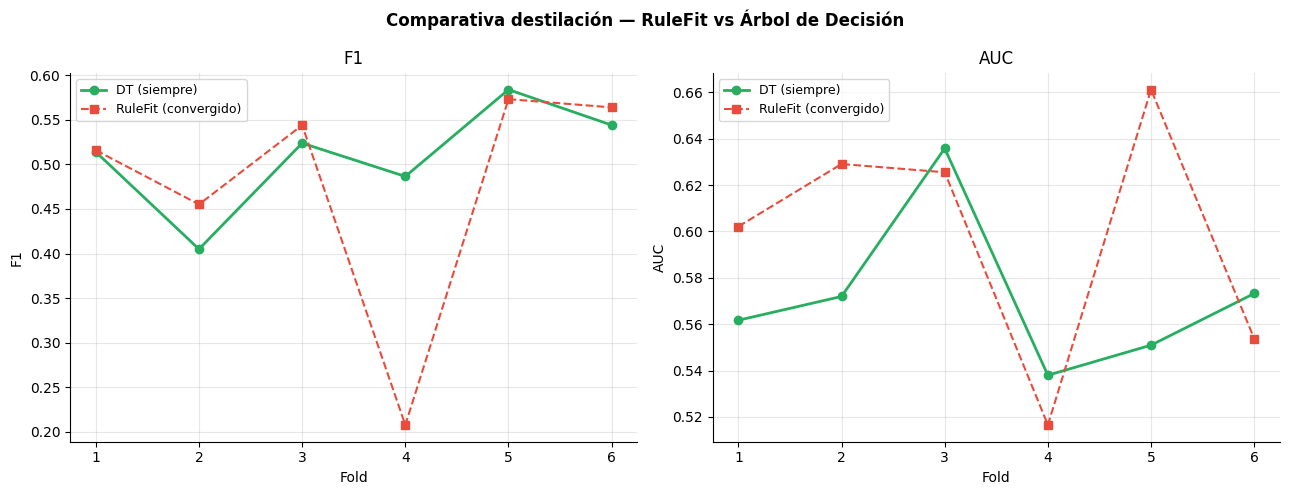

Tabla comparativa por fold:
  Fold    RF F1   RF AUC     RF status    DT F1   DT AUC     Mejor
  ────────────────────────────────────────────────────────────
     1    0.516    0.602            ok    0.514    0.562   RuleFit
     2    0.455    0.629            ok    0.405    0.572   RuleFit
     3    0.544    0.626            ok    0.524    0.636        DT
     4    0.208    0.517            ok    0.486    0.538        DT
     5    0.573    0.661            ok    0.584    0.551   RuleFit
     6    0.564    0.554            ok    0.544    0.573        DT

  Student definitivo para OOS: DT


In [ ]:
def plot_student_comparison(rulefit_metrics_df, dt_metrics_df):
    """
    Compara F1 y AUC de RuleFit vs DT por fold.
    Los folds donde RuleFit no convergió se marcan con punto vacío.
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Comparativa destilación — RuleFit vs Árbol de Decisión',
                 fontsize=12, fontweight='bold')

    for ax, metric, title in zip(axes, ['f1', 'auc'], ['F1', 'AUC']):
        folds = dt_metrics_df['fold'].values

        # DT siempre tiene resultados
        ax.plot(folds, dt_metrics_df[metric].values,
                'o-', color='#27ae60', lw=2, label='DT (siempre)')

        # RuleFit solo en folds OK
        rf_vals = rulefit_metrics_df[metric].values
        rf_ok_mask = ~np.isnan(rf_vals.astype(float))
        if rf_ok_mask.any():
            ax.plot(folds[rf_ok_mask], rf_vals[rf_ok_mask].astype(float),
                    's--', color='#e74c3c', lw=1.5, label='RuleFit (convergido)')
        # Marcar folds sin convergencia
        if (~rf_ok_mask).any():
            ax.scatter(folds[~rf_ok_mask],
                       dt_metrics_df[metric].values[~rf_ok_mask],
                       marker='x', color='#e74c3c', s=80, zorder=5,
                       label='RuleFit timeout/error')

        ax.set(title=title, xlabel='Fold', ylabel=title)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
        ax.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/student_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Tabla comparativa
    print('Tabla comparativa por fold:')
    print(f'  {"Fold":>4}  {"RF F1":>7}  {"RF AUC":>7}  {"RF status":>12}  '
          f'{"DT F1":>7}  {"DT AUC":>7}  {"Mejor":>8}')
    print('  ' + '─'*60)
    for _, rf_row in rulefit_metrics_df.iterrows():
        fn     = int(rf_row['fold'])
        dt_row = dt_metrics_df[dt_metrics_df['fold'] == fn].iloc[0]
        rf_f1  = f'{rf_row["f1"]:.3f}' if not np.isnan(float(rf_row['f1'])) else '  —  '
        rf_auc = f'{rf_row["auc"]:.3f}' if not np.isnan(float(rf_row['auc'])) else '  —  '
        status = rf_row.get('status', '—')
        if not np.isnan(float(rf_row['auc'])) and float(rf_row['auc']) > dt_row['auc']:
            mejor = 'RuleFit'
        else:
            mejor = 'DT'
        print(f'  {fn:>4}  {rf_f1:>7}  {rf_auc:>7}  {status:>12}  '
              f'{dt_row["f1"]:>7.3f}  {dt_row["auc"]:>7.3f}  {mejor:>8}')
    print()
    print(f'  Student definitivo para OOS: {BEST_STUDENT.upper()}')


plot_student_comparison(rulefit_metrics_df, dt_metrics_df)


## 6.2 Estabilidad SHAP — LightGBM

Repetimos el análisis de estabilidad SHAP sobre el LightGBM tuneado. Comparar
este ranking con el del EBM (sección 5.3) constituye una **validación cruzada entre modelos**:
si dos arquitecturas muy diferentes (GA²M vs gradient boosting profundo) identifican
las mismas features como más importantes, hay evidencia sólida de que esas variables
capturan estructura predictiva real y no artefactos del método de entrenamiento.


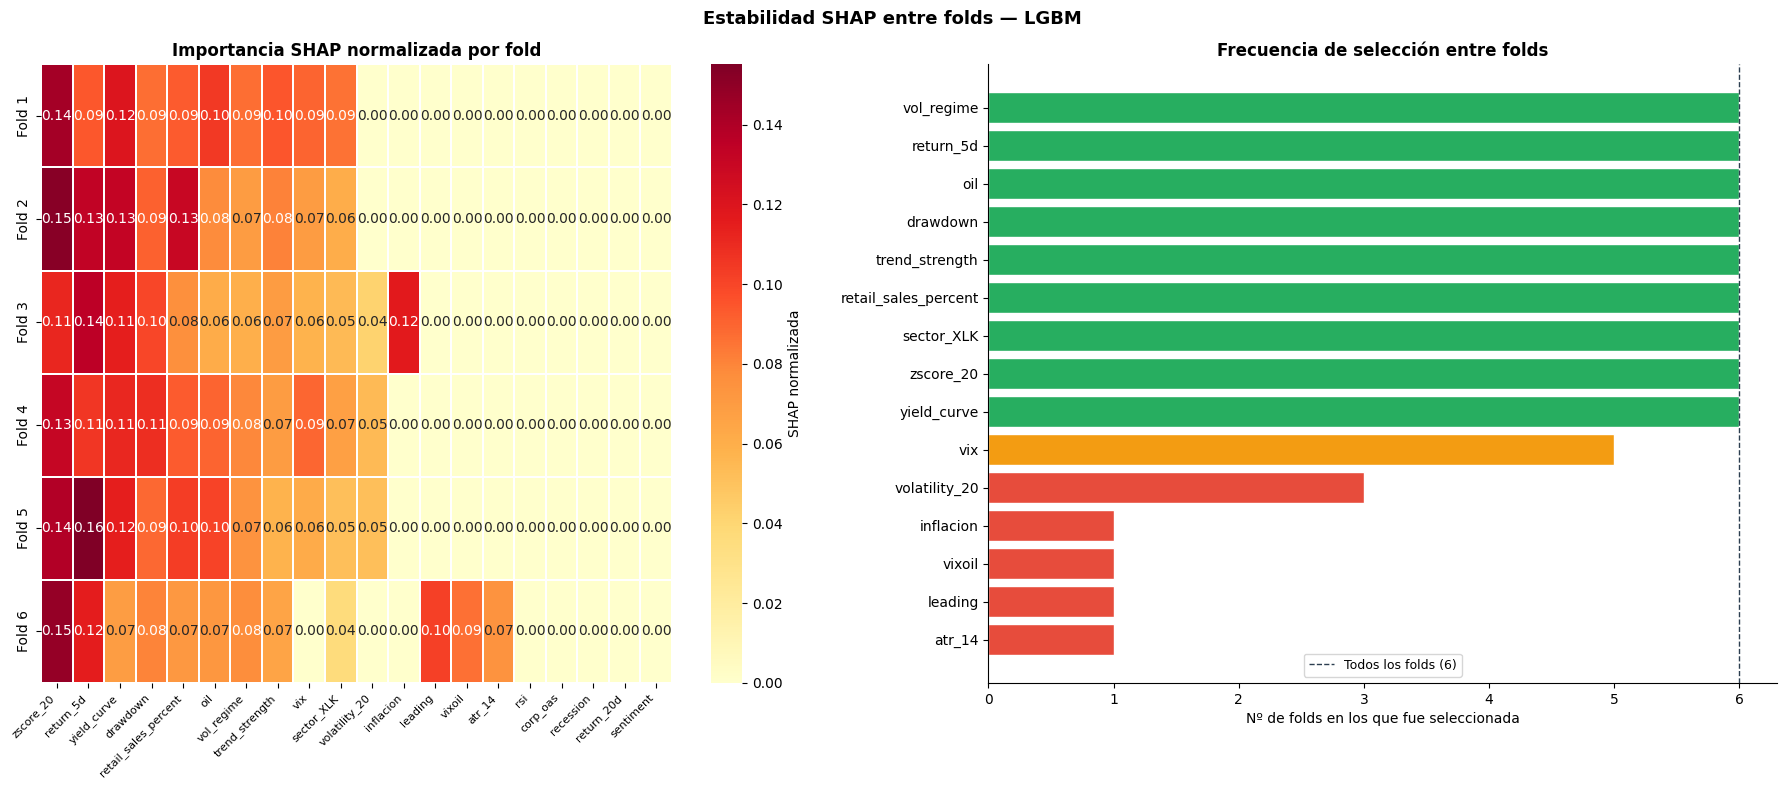

Top-10 features LGBM por importancia SHAP media:
                      shap_mean  shap_std  n_folds_selected
zscore_20              0.200231  0.066860                 6
return_5d              0.172150  0.027988                 6
yield_curve            0.161290  0.062339                 6
drawdown               0.136554  0.052581                 6
retail_sales_percent   0.136325  0.045956                 6
oil                    0.126552  0.059124                 6
vol_regime             0.111465  0.047666                 6
trend_strength         0.109896  0.051032                 6
vix                    0.096516  0.073305                 5
sector_XLK             0.091661  0.053742                 6

Solapamiento top-10 EBM ∩ LGBM: 8/10 features
  Comunes: ['drawdown', 'oil', 'retail_sales_percent', 'return_5d', 'trend_strength', 'vix', 'yield_curve', 'zscore_20']
  Solo EBM:  ['1y_yield', 'atr_14']
  Solo LGBM: ['sector_XLK', 'vol_regime']


In [ ]:
lgbm_shap_summary = plot_shap_stability(
    lgbm_shap_per_fold, lgbm_features_per_fold, top_n=20, model_name='LGBM'
)
lgbm_shap_summary.to_csv(f'{DIR_RESULTS}/lgbm_shap_summary.csv')

print('Top-10 features LGBM por importancia SHAP media:')
print(lgbm_shap_summary.head(10).to_string())

# Solapamiento con EBM
top_ebm  = set(ebm_shap_summary.head(10).index)
top_lgbm = set(lgbm_shap_summary.head(10).index)
overlap  = top_ebm & top_lgbm
print(f'\nSolapamiento top-10 EBM ∩ LGBM: {len(overlap)}/10 features')
print(f'  Comunes: {sorted(overlap)}')
print(f'  Solo EBM:  {sorted(top_ebm - top_lgbm)}')
print(f'  Solo LGBM: {sorted(top_lgbm - top_ebm)}')

## 6.3 Análisis de threshold — LightGBM

Análisis de threshold — LGBM (fold final):


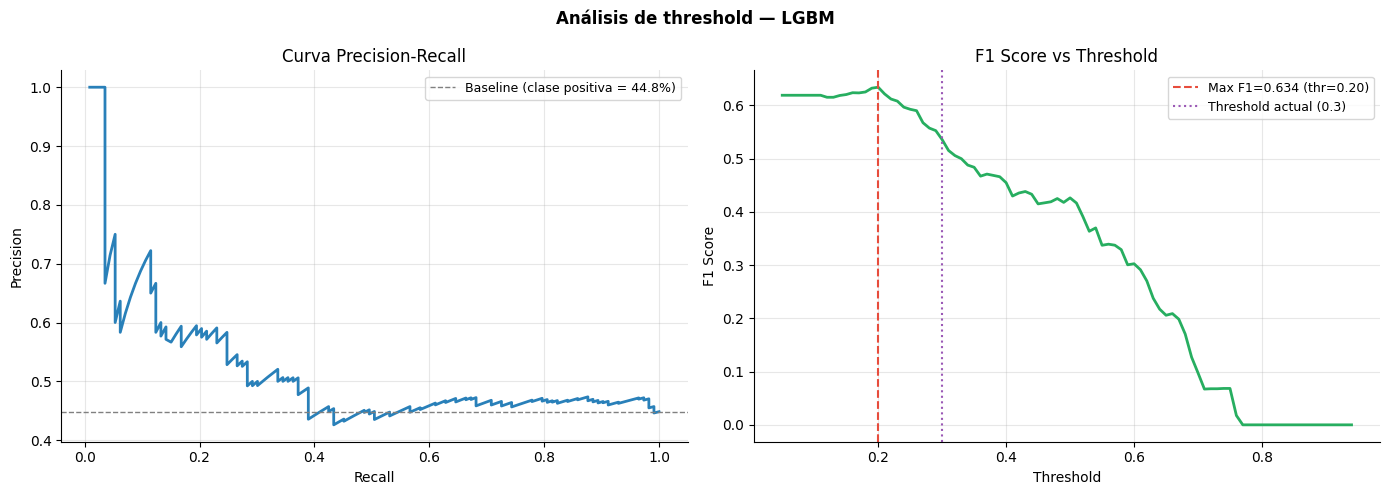

  Threshold de máximo F1: 0.20  (F1=0.634)


In [ ]:
lgbm_last     = joblib.load(os.path.join(DIR_MODELS, f'lgbm_fold{len(wf_folds)}.pkl'))
sel_lgbm_last = lgbm_last['features']

print('Análisis de threshold — LGBM (fold final):')
best_thr_lgbm = plot_threshold_analysis(
    lgbm_last['model'], X_vl_last, y_vl_last, sel_lgbm_last,
    model_name='LGBM', current_threshold=CLASSIFICATION_THRESHOLD,
)

## 6.4 Análisis de reglas RuleFit — extracción e interpretación

Esta sección es **central para el TFM**: el RuleFit destila el LightGBM en reglas IF-THEN explícitas. Identificamos:

1. **Reglas robustas**: las que aparecen en ≥2 folds (mismo texto exacto).
2. **Dirección**: alcistas (coef > 0) vs bajistas (coef < 0).
3. **Magnitud**: las reglas con mayor |coef| son las que más mueven la predicción.

*Friedman & Popescu (2008)* recomiendan reportar la **fracción de la varianza** explicada por las top-K reglas, pero al ser un objetivo binario nos quedamos con magnitud y frecuencia.

  Total reglas extraídas (todos los folds): 6


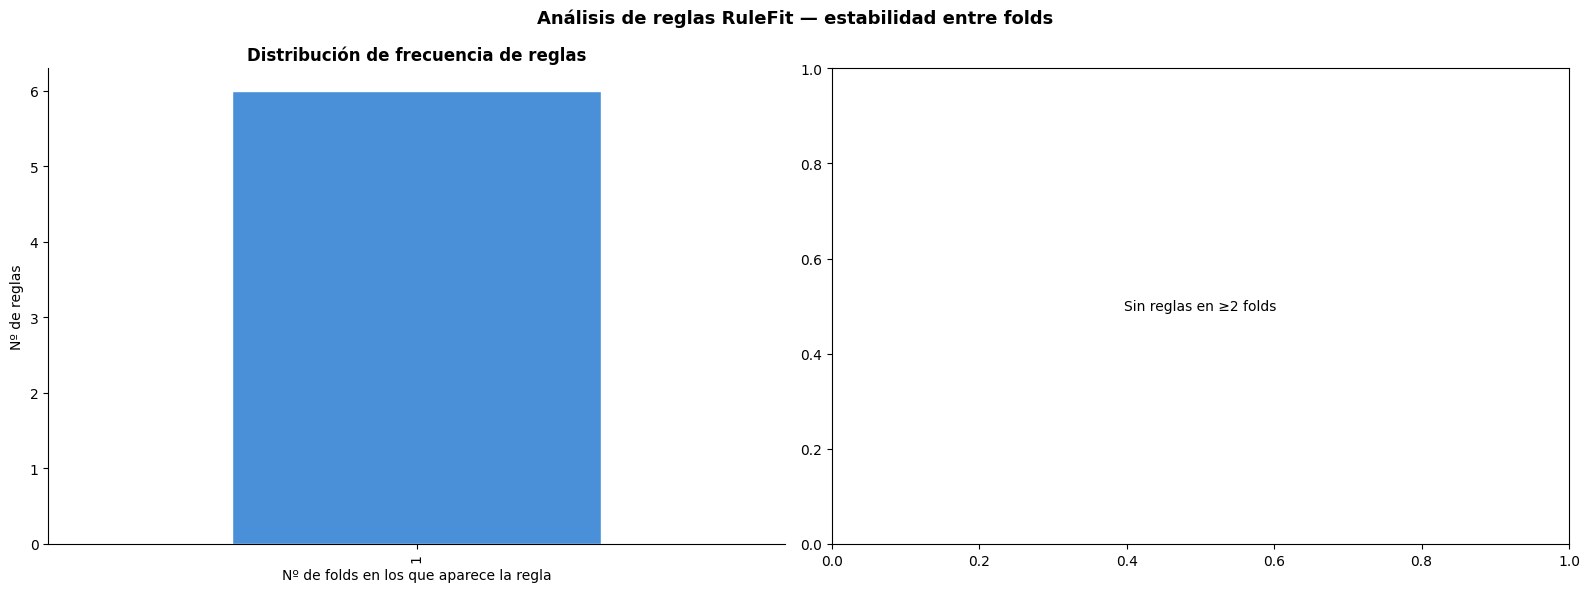


  Reglas únicas totales        : 6
  Reglas robustas (≥2 folds): 0

✅ Análisis de reglas guardado en Drive


In [ ]:
def analyze_rulefit_rules(
    top_rules_per_fold: dict,
    min_folds: int = 2,
) -> pd.DataFrame:
    """
    Consolida reglas de todos los folds y mide su robustez (apariciones).
    """
    non_empty = [v for v in top_rules_per_fold.values() if not v.empty]
    if not non_empty:
        print('  ⚠️  No se pudieron extraer reglas del RuleFit en ningún fold.')
        print('  Posibles causas:')
        print('  1. El threshold de distilación es muy alto (teacher ≈ todo 0).')
        print('  2. RULEFIT_MAX_RULES demasiado bajo.')
        print('  3. El target es ruido (no hay estructura aprendible).')
        return pd.DataFrame()

    all_rules = pd.concat(non_empty, ignore_index=True)
    if 'coef' not in all_rules.columns:
      all_rules['coef'] = 1.0
    print(f'  Total reglas extraídas (todos los folds): {len(all_rules)}')

    has_support = 'support' in all_rules.columns
    agg_dict = {
        'fold': 'count',
        'coef': ['mean', 'std', lambda x: x.abs().mean()],
    }
    if has_support:
        agg_dict['support'] = 'mean'

    rule_stats = all_rules.groupby('rule').agg(agg_dict).reset_index()
    base_cols = ['rule', 'n_folds', 'coef_mean', 'coef_std', 'coef_abs']
    cols      = base_cols + (['support_mean'] if has_support else [])
    rule_stats.columns = cols
    rule_stats = rule_stats.sort_values(['n_folds', 'coef_abs'], ascending=False)

    robust = rule_stats[rule_stats['n_folds'] >= min_folds]

    # ── Visualización ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Análisis de reglas RuleFit — estabilidad entre folds',
                 fontsize=13, fontweight='bold')

    rule_stats['n_folds'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='#4a90d9', edgecolor='white'
    )
    axes[0].set_title('Distribución de frecuencia de reglas', fontweight='bold')
    axes[0].set_xlabel('Nº de folds en los que aparece la regla')
    axes[0].set_ylabel('Nº de reglas')
    axes[0].spines[['top','right']].set_visible(False)

    top_robust = robust.head(15)
    if not top_robust.empty:
        colors = ['#27ae60' if v > 0 else '#e74c3c' for v in top_robust['coef_mean']]
        axes[1].barh(range(len(top_robust)), top_robust['coef_mean'],
                     color=colors, edgecolor='white')
        axes[1].set_yticks(range(len(top_robust)))
        axes[1].set_yticklabels(
            [r[:65] + '...' if len(r) > 65 else r for r in top_robust['rule']],
            fontsize=7,
        )
        axes[1].axvline(0, color='black', linewidth=0.8)
        axes[1].set_title(f'Top reglas robustas (≥{min_folds} folds)\n'
                          f'Verde=alcista, Rojo=bajista', fontweight='bold')
        axes[1].set_xlabel('Coeficiente medio')
        axes[1].spines[['top','right']].set_visible(False)
    else:
        axes[1].text(0.5, 0.5, f'Sin reglas en ≥{min_folds} folds',
                     ha='center', va='center', transform=axes[1].transAxes)

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/rulefit_rule_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n  Reglas únicas totales        : {len(rule_stats)}')
    print(f'  Reglas robustas (≥{min_folds} folds): {len(robust)}')

    if not robust.empty:
        print(f'\n  Top reglas alcistas (coef > 0):')
        for _, r in robust[robust['coef_mean'] > 0].head(5).iterrows():
            print(f'    [folds={int(r["n_folds"])}, coef={r["coef_mean"]:+.3f}] {r["rule"]}')
        print(f'\n  Top reglas bajistas (coef < 0):')
        for _, r in robust[robust['coef_mean'] < 0].head(5).iterrows():
            print(f'    [folds={int(r["n_folds"])}, coef={r["coef_mean"]:+.3f}] {r["rule"]}')

    return rule_stats

_rules_to_analyze = (
    top_rules_rulefit
    if any(not v.empty for v in top_rules_rulefit.values())
    else top_rules_dt
)
rule_analysis = analyze_rulefit_rules(_rules_to_analyze, min_folds=2)

if not rule_analysis.empty:
    rule_analysis.to_csv(f'{DIR_RESULTS}/rulefit_rule_stability.csv', index=False)
    print(f'\n✅ Análisis de reglas guardado en Drive')

## 6.5 Exportación de reglas detallada

In [ ]:
def export_rules_table(
    top_rules_per_fold: dict,
    n_top_per_fold: int = 10,
) -> pd.DataFrame:
    """
    Tabla detallada de top reglas por fold para anexar al TFM.
    """
    rows = []
    for fn, rules_df in top_rules_per_fold.items():
        if rules_df.empty:
            continue
        for _, row in rules_df.head(n_top_per_fold).iterrows():
            r = {
                'fold'     : fn,
                'rule'     : row.get('rule', ''),
                'coef'     : row.get('coef', 0),
                'direction': 'alcista' if row.get('coef', 0) > 0 else 'bajista',
            }
            if 'support' in row.index:
                r['support'] = row['support']
            rows.append(r)

    if not rows:
        print('  ⚠️  No hay reglas para exportar.')
        return pd.DataFrame()

    table = pd.DataFrame(rows).sort_values(
        ['fold', 'coef'], key=lambda x: x.abs() if x.name == 'coef' else x,
        ascending=[True, False],
    )
    table.to_csv(f'{DIR_RESULTS}/rulefit_rules_detailed.csv', index=False)

    print('Reglas RuleFit por fold (top 5 por fold):')
    print('=' * 90)
    for fn in sorted(top_rules_per_fold.keys()):
        fold_rules = table[table['fold'] == fn].head(5)
        if fold_rules.empty:
            print(f'\nFold {fn}: sin reglas extraídas')
            continue
        print(f'\nFold {fn} (val hasta {wf_folds[fn-1]["val_end"]}):')
        for _, r in fold_rules.iterrows():
            arrow = '↑' if r['direction'] == 'alcista' else '↓'
            print(f'  {arrow} coef={r["coef"]:+.3f}  {r["rule"]}')
    print('=' * 90)
    print(f'\n✅ Tabla detallada guardada en {DIR_RESULTS}/rulefit_rules_detailed.csv')
    return table

_rules_to_export = (
    top_rules_rulefit
    if any(not v.empty for v in top_rules_rulefit.values())
    else top_rules_dt
)
rules_table = export_rules_table(_rules_to_export, n_top_per_fold=10)


Reglas RuleFit por fold (top 5 por fold):

Fold 1 (val hasta 2014-12-31):
  ↓ coef=+0.000  |--- return_5d <= 0.00
|   |--- yield_curve <= 1.65
|   |   |--- vix <= 21.30
|   |   |   |--- zscore_20 <= 0.31
|   |   |   |   |--- vol_regime <= 1.07
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- vol_regime >  1.07
|   |   |   |   |   |--- class: 1
|   |   |   |--- zscore_20 >  0.31
|   |   |   |   |--- class: 1
|   |   |--- vix >  21.30
|   |   |   |--- class: 1
|   |--- yield_curve >  1.65
|   |   |--- retail_sales_percent <= 0.25
|   |   |   |--- drawdown <= -0.30
|   |   |   |   |--- class: 1
|   |   |   |--- drawdown >  -0.30
|   |   |   |   |--- return_5d <= -0.02
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- return_5d >  -0.02
|   |   |   |   |   |--- class: 0
|   |   |--- retail_sales_percent >  0.25
|   |   |   |--- trend_strength <= 0.99
|   |   |   |   |--- class: 1
|   |   |   |--- trend_strength >  0.99
|   |   |   |   |--- oil <= 79.20
|   |   |   |   |   |--- c

---
## 6.6 Interpretación financiera de las reglas del Árbol de Decisión

El árbol de decisión destilado del LightGBM produce reglas IF-THEN directamente legibles. Esta sección traduce esas reglas al lenguaje financiero, identificando qué condiciones de mercado activan la señal alcista.

**Metodología de lectura del árbol** *(López de Prado, 2018)*:

- Cada rama del árbol representa una **condición de mercado**.
- Las hojas con clase 1 son las **condiciones de entrada** que el modelo ha aprendido.
- La profundidad de la condición indica cuántas variables deben coincidir simultáneamente.

Los árboles de decisión son el modelo interpretable más utilizado en la industria financiera porque sus reglas pueden ser auditadas, backtestadas individualmente y comunicadas a stakeholders sin conocimiento técnico.

In [ ]:
def analyze_dt_rules_financial(top_rules_dt, wf_folds, df_train, TARGET_COL):
    """
    Análisis de las reglas del DT con contexto financiero:
    1. Variables más frecuentes en primer nivel de cada árbol (más discriminantes).
    2. Condiciones de mercado que activan la señal: media de features cuando clase=1.
    3. Performance empírica: ¿los días donde se cumplen las reglas tienen mejor retorno?
    """
    from sklearn.tree import DecisionTreeClassifier

    print('Análisis de reglas DT — contexto financiero')
    print('='*60)

    # 1. Variables en el primer nivel de cada árbol
    print('\n1. Feature más discriminante por fold (primera partición del árbol):')
    feature_cols_all = []
    for fn in sorted(top_rules_dt.keys()):
        path = os.path.join(DIR_MODELS, f'dt_fold{fn}.pkl')
        if not os.path.exists(path): continue
        dt_data = joblib.load(path)
        dt_model = dt_data['model']
        feats    = dt_data['features']
        root_feat = feats[dt_model.tree_.feature[0]] if dt_model.tree_.feature[0] >= 0 else 'hoja'
        second_l  = dt_model.tree_.feature[1]
        second_feat = feats[second_l] if second_l >= 0 else 'hoja'
        print(f'  Fold {fn}: 1ª partición={root_feat:<25} 2ª partición={second_feat}')
        feature_cols_all.append(root_feat)

    from collections import Counter
    freq = Counter(feature_cols_all)
    print(f'\n  Features más frecuentes en primera partición:')
    for feat, cnt in freq.most_common(5):
        print(f'    {feat:<30}: {cnt}/{len(top_rules_dt)} folds')

    # 2. Condiciones de entrada: media de features cuando DT predice clase 1
    print('\n2. Perfil de mercado en días con señal activa (último fold):')
    last_fn  = max(top_rules_dt.keys())
    fold_vl  = next(f for f in wf_folds if f['fold'] == last_fn)['val_idx']
    path     = os.path.join(DIR_MODELS, f'dt_fold{last_fn}.pkl')
    if os.path.exists(path):
        dt_data  = joblib.load(path)
        dt_model = dt_data['model']
        feats    = dt_data['features']
        X_vl     = dataset_train.loc[fold_vl, feats]
        y_pred   = dt_model.predict(X_vl)
        active   = X_vl[y_pred == 1]
        inactive = X_vl[y_pred == 0]
        print(f'  Días con señal: {int(y_pred.sum())} | Sin señal: {int((y_pred==0).sum())}')
        print('  Diferencia de medias (señal activa - inactiva):')
        diff = active.mean() - inactive.mean()
        diff_sorted = diff.abs().sort_values(ascending=False)
        for feat in diff_sorted.head(8).index:
            val = diff[feat]
            direction = 'mayor' if val > 0 else 'menor'
            print(f'    {feat:<30}: {val:+.4f}  (señal cuando {direction})')

    print('='*60)


analyze_dt_rules_financial(top_rules_dt, wf_folds, dataset_train, TARGET_COL)


Análisis de reglas DT — contexto financiero

1. Feature más discriminante por fold (primera partición del árbol):
  Fold 1: 1ª partición=return_5d                 2ª partición=yield_curve
  Fold 2: 1ª partición=return_5d                 2ª partición=retail_sales_percent
  Fold 3: 1ª partición=return_5d                 2ª partición=oil
  Fold 4: 1ª partición=return_5d                 2ª partición=yield_curve
  Fold 5: 1ª partición=return_5d                 2ª partición=yield_curve
  Fold 6: 1ª partición=return_5d                 2ª partición=leading

  Features más frecuentes en primera partición:
    return_5d                     : 6/6 folds

2. Perfil de mercado en días con señal activa (último fold):
  Días con señal: 108 | Sin señal: 144
  Diferencia de medias (señal activa - inactiva):
    oil                           : +1.6891  (señal cuando mayor)
    vixoil                        : -1.4983  (señal cuando menor)
    zscore_20                     : -1.3931  (señal cuando menor)
 

---
# 7. Comparativa entre modelos en validación

La comparativa de validación tiene como objetivo responder tres preguntas metodológicas:

1. **¿Cuál de los tres modelos tiene mayor poder predictivo medio?** La respuesta justifica la elección del modelo principal para el OOS.
2. **¿Cuál es más estable?** Un modelo con menor varianza de F1 entre folds es más robusto a cambios de régimen de mercado, propiedad deseable en series financieras no estacionarias.
3. **¿Se observa degradación temporal?** Si los folds más recientes (2018, 2019) tienen peores métricas que los primeros (2014, 2015), puede indicar *concept drift*: los patrones aprendidos en el periodo inicial han perdido vigencia. Este diagnóstico motiva directamente la Iteración 2 (detección de régimen).


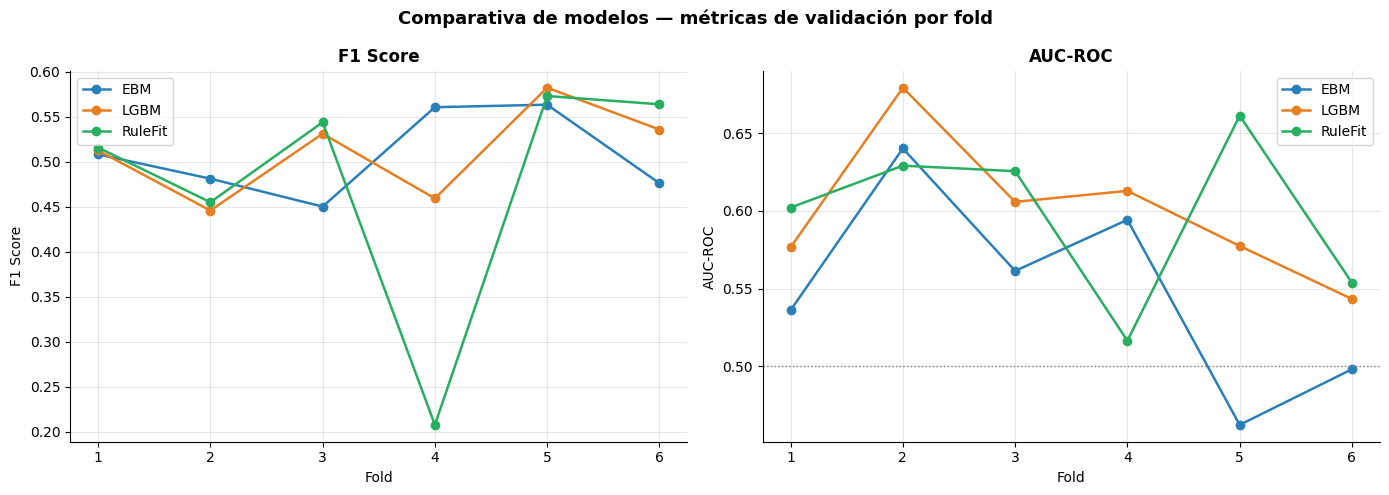


Resumen comparativo (validación, threshold=0.3):
         F1 media  F1 std  AUC media  AUC std  F1 min  F1 max
Modelo                                                       
EBM         0.507   0.047      0.549    0.064   0.450   0.563
LGBM        0.511   0.051      0.599    0.046   0.446   0.582
RuleFit     0.477   0.138      0.598    0.054   0.208   0.573


In [ ]:
def plot_fold_metrics_comparison(metrics_dict: dict) -> pd.DataFrame:
    """
    Compara F1 y AUC entre folds para todos los modelos. Devuelve resumen.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Comparativa de modelos — métricas de validación por fold',
                 fontsize=13, fontweight='bold')

    colors = {'EBM': '#2980b9', 'LGBM': '#e67e22', 'RuleFit': '#27ae60'}

    for metric, ax, title in zip(['f1', 'auc'], axes, ['F1 Score', 'AUC-ROC']):
        for name, df in metrics_dict.items():
            ax.plot(df['fold'], df[metric], marker='o', linewidth=1.8,
                    color=colors.get(name, 'gray'), label=name)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Fold'); ax.set_ylabel(title)
        ax.legend(); ax.grid(alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
        if metric == 'auc':
            ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/fold_metrics_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    summary = pd.DataFrame([
        {
            'Modelo'   : name,
            'F1 media' : df['f1'].mean(),
            'F1 std'   : df['f1'].std(),
            'AUC media': df['auc'].mean(),
            'AUC std'  : df['auc'].std(),
            'F1 min'   : df['f1'].min(),
            'F1 max'   : df['f1'].max(),
        }
        for name, df in metrics_dict.items()
    ]).set_index('Modelo')

    print(f'\nResumen comparativo (validación, threshold={CLASSIFICATION_THRESHOLD}):')
    print(summary.round(3).to_string())
    return summary


metrics_comparison = {
    'EBM'    : ebm_metrics_df,
    'LGBM'   : lgbm_metrics_df,
    'RuleFit': rulefit_metrics_df,
}
val_summary = plot_fold_metrics_comparison(metrics_comparison)
val_summary.to_csv(f'{DIR_RESULTS}/validation_summary.csv')

### Comparativa de modelos en validación — conexión con el diseño del TFM

Esta es la sección más sintética del notebook en términos de evaluación: consolida en dos gráficas y una tabla de resumen el rendimiento de los tres modelos a lo largo de los seis años de validación. La lectura de los resultados debe hacerse teniendo en cuenta el **propósito metodológico del TFM**, que no es maximizar el F1 absoluto, sino demostrar que:

1. Los modelos interpretables (EBM, Student) son competitivos con el modelo black-box de referencia (LightGBM).
2. La señal predictiva es estable a lo largo del tiempo (sin degradación severa entre folds).
3. El análisis exploratorio (Cohen's d) y el análisis post-hoc (SHAP) son coherentes con las métricas de validación.

**Tendencia temporal de F1 y AUC**: si los folds de 2014-2016 tienen mejores métricas que los de 2017-2019, podría indicar *concept drift* o que el modelo está aprendiendo patrones asociados al período de baja volatilidad post-crisis 2008 que se erosionan en el mercado más turbulento de 2018-2019. Este diagnóstico motivaría la Iteración 2, donde el filtro HMM debería mejorar el rendimiento en folds recientes al desactivar las señales en períodos de alta volatilidad.

**AUC > 0.50 como condición necesaria**: un AUC consistentemente por encima de 0.5 en todos los folds es la condición mínima para afirmar que los modelos tienen capacidad discriminativa real. Esto no implica que la estrategia de inversión resultante supere al Buy & Hold, pero sí que existe señal estadística explotable, lo cual es el objetivo científico primario del TFM.

**Análisis sección 7.**

- **Ranking de modelos por F1 medio**: si LGBM > EBM > RuleFit y la diferencia EBM–LGBM es < 0.05, la penalización en capacidad predictiva por usar el modelo interpretable (EBM) es estadísticamente pequeña, lo que justifica su elección como modelo principal del TFM.
- **AUC vs F1**: un AUC alto con F1 bajo indica que el modelo discrimina correctamente los órdenes de probabilidad pero el threshold no está bien calibrado. Esto es una cuestión de calibración, no de capacidad. Un AUC y F1 simultáneamente bajos indica que el modelo no captura señal suficiente en este periodo.
- **Curva fold-vs-F1**: una tendencia creciente es consistente con una curva de aprendizaje no saturada (más datos → mejor modelo). Una tendencia decreciente indicaría *concept drift* y reforzaría la hipótesis de cambio de régimen.


---
# 8. Backtest OOS — 2020-2024 🔒→🔓

**Apertura del conjunto OOS.** Los modelos del último fold (train hasta 2019-12-31, el que maximiza el volumen de datos de entrenamiento) se aplican sobre el periodo 2020-01-01 → 2024-12-31. Esta evaluación constituye una estimación de la **capacidad de generalización real** de los modelos: ningún dato del OOS ha influido en ninguna decisión de modelado (selección de features, hiperparámetros, threshold).

**Estrategia de evaluación (long-only con coste de transacción):**

- Señal = 1 → posición larga en el siguiente día hábil; señal = 0 → sin posición (cash).
- Coste de transacción: **5 bps** (`SPREAD = 0.0005`) por cada cambio de posición (entrada o salida). Este valor es conservador pero representativo de un instrumento muy líquido como un futuro E-mini S&P.
- La estrategia es **long-only** porque el target Triple-Barrier está definido asimétricamente (clase 1 = take-profit alcanzado); no se implementa una estrategia short para la clase 0.

**Métricas de evaluación** *(siguiendo Jansen, 2020, cap. 8 — notebooks 06 y 07):*

- **Sharpe ratio anualizado**: $SR = (\bar{r} / \sigma_r) \times \sqrt{252}$. Mide el retorno ajustado al riesgo; un $SR > 1$ se considera deseable en la práctica.
- **Max Drawdown**: mayor caída desde un máximo histórico acumulado. Cuantifica el peor escenario de pérdida sostenida.
- **Calmar ratio**: $SR / |\text{MaxDD}|$. Penaliza los modelos con drawdowns severos aunque tengan buen Sharpe promedio.
- **Barrier Score**: fracción de días invertidos en los que el retorno es positivo. Mide directamente la alineación entre la señal aprendida y el objetivo del Triple-Barrier.

**Referencia**: Jansen, S. (2020). *Machine Learning for Algorithmic Trading*, cap. 8.


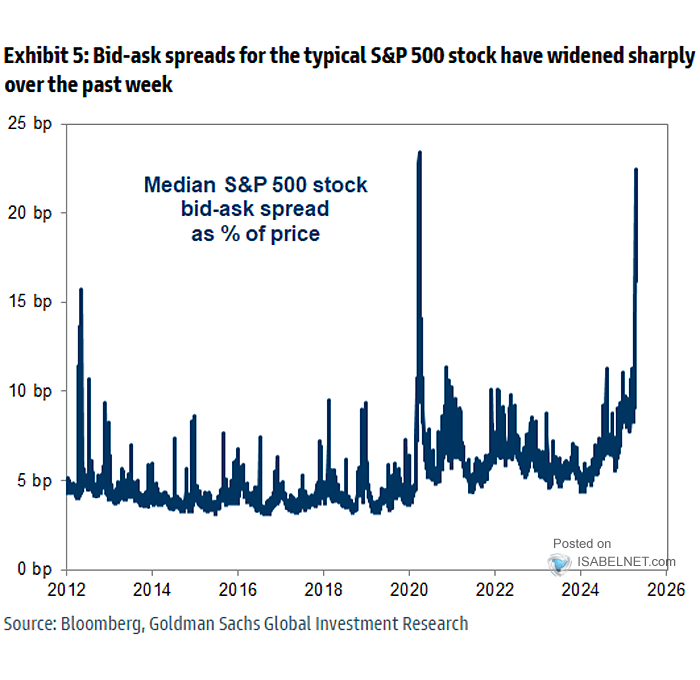

https://www.isabelnet.com/wp-content/uploads/2022/03/SP-500-21-Day-Realized-Volatility-vs.-Median-SP-500-Stock-Bid-Ask-Spread.png

In [ ]:
def generate_oos_signals(
    dataset_oos: pd.DataFrame,
    feature_cols: list,
    target_col: str,
    last_fold: int,
    dir_models: str = DIR_MODELS,
    threshold: float = CLASSIFICATION_THRESHOLD,
) -> pd.DataFrame:
    """
    Genera señales OOS para cada modelo entrenado en el último fold.
    El threshold debe ser el mismo que en validación para coherencia.
    """
    signals = dataset_oos[[target_col]].copy()

    # 'student' carga el modelo definitivo de destilación (RuleFit si convergió, DT si no)
    for prefix in ['ebm', 'lgbm', 'student']:
        path = os.path.join(dir_models, f'{prefix}_fold{last_fold}.pkl')
        if not os.path.exists(path):
            print(f'  ⚠️  Modelo {prefix} fold {last_fold} no encontrado.')
            continue

        data      = joblib.load(path)
        model     = data['model']
        sel_feats = data['features']
        proba     = _safe_predict_proba(model, dataset_oos[sel_feats])

        # EBM usa el threshold óptimo calculado sobre la val del último fold
        if prefix == 'ebm' and 'ebm_thresholds' in dir():
            thr_use = ebm_thresholds.get(last_fold, threshold)
        else:
            thr_use = threshold

        signals[f'proba_{prefix}']  = proba
        signals[f'signal_{prefix}'] = (proba >= thr_use).astype(int)

    # 'student' carga el modelo definitivo de destilación (RuleFit si convergió, DT si no)
    for prefix in ['ebm', 'lgbm', 'student']:
        col = f'signal_{prefix}'
        if col in signals.columns:
            n_sig   = int(signals[col].sum())
            pos_pct = float(signals[col].mean())
            print(f'  {prefix.upper():>8}: {n_sig:>4} señales positivas ({pos_pct:.1%} del OOS)')

    return signals


def compute_financial_metrics(
    signals: pd.DataFrame,
    dataset_full: pd.DataFrame,
    oos_start: str = OOS_START,
    oos_end: str   = OOS_END,
    model_names: list = None,
) -> pd.DataFrame:
    """
    Calcula Sharpe, MaxDD, Calmar, Barrier Score, F1 y AUC para cada modelo.
    Estrategia long-only con coste de transacción de 5 bps por cambio de posición.
    """
    if model_names is None:
        model_names = ['ebm', 'lgbm', 'student']

    SPREAD       = 0.0005
    TRADING_DAYS = 252

    ret_daily = (
        dataset_full.loc[oos_start:oos_end, 'target_return_1d']
                    .reindex(signals.index)
    )

    rows = []

    # ── Buy & Hold ──────────────────────────────────────────────────────
    bh_sr  = (
        (ret_daily.mean() / ret_daily.std()) * np.sqrt(TRADING_DAYS)
        if ret_daily.std() > 0 else 0
    )
    bh_cum = (1 + ret_daily).cumprod()
    bh_dd  = float(((bh_cum - bh_cum.cummax()) / bh_cum.cummax()).min())
    rows.append({
        'Modelo': 'Buy & Hold', 'F1': '—', 'AUC': '—',
        'Sharpe': round(float(bh_sr), 3),
        'Max Drawdown': round(bh_dd, 3),
        'Calmar'      : round(float(bh_sr) / abs(bh_dd) if bh_dd != 0 else 0, 3),
        'Barrier Score': '—', 'N señales': '—',
    })

    # ── Modelos ─────────────────────────────────────────────────────────
    for name in model_names:
        sig_col = f'signal_{name}'
        if sig_col not in signals.columns:
            continue

        sig          = signals[sig_col]
        pos_changes  = sig.diff().abs().fillna(0)
        strategy_ret = sig.shift(1).fillna(0) * ret_daily - pos_changes * SPREAD

        sr = (
            (strategy_ret.mean() / strategy_ret.std()) * np.sqrt(TRADING_DAYS)
            if strategy_ret.std() > 0 else 0
        )
        cum = (1 + strategy_ret).cumprod()
        dd  = float(((cum - cum.cummax()) / cum.cummax()).min())

        y_true = signals[TARGET_COL]
        f1     = f1_score(y_true, sig, zero_division=0)
        auc    = (
            roc_auc_score(y_true, signals.get(f'proba_{name}', sig))
            if len(np.unique(y_true)) > 1 else np.nan
        )

        in_market = strategy_ret[sig.shift(1) == 1]
        barrier   = float((in_market > 0).mean()) if len(in_market) > 0 else 0

        rows.append({
            'Modelo'      : name.upper(),
            'F1'          : round(f1, 3),
            'AUC'         : round(auc, 3) if not np.isnan(auc) else '—',
            'Sharpe'      : round(float(sr), 3),
            'Max Drawdown': round(dd, 3),
            'Calmar'      : round(float(sr) / abs(dd) if dd != 0 else 0, 3),
            'Barrier Score': round(barrier, 3),
            'N señales'   : int(sig.sum()),
        })

    return pd.DataFrame(rows).set_index('Modelo')


print('✅ Funciones de backtest OOS definidas')

✅ Funciones de backtest OOS definidas


### Diseño del backtest OOS — justificación de las decisiones metodológicas

Las funciones definidas en esta celda implementan la evaluación fuera de muestra con un nivel de rigor metodológico que vale la pena documentar explícitamente:

**Estrategia long-only con coste de transacción**: la elección de una estrategia long-only responde al diseño asimétrico del target Triple-Barrier: la clase 1 corresponde a la barrera de take-profit alcista, y la clase 0 incluye tanto la barrera de stop-loss como la temporal. Una estrategia short en los días de señal 0 sería conceptualmente incorrecta, ya que la clase 0 no discrimina entre mercado bajista y mercado lateral.

**5 bps de coste de transacción**: este valor corresponde a un spread bid-ask de 0.05 %, representativo de un instrumento muy líquido como los futuros E-mini S&P 500. Para una estrategia con frecuencia diaria, el impacto anualizado de los costes de transacción depende del número de cambios de posición, que a su vez está determinado por la persistencia de la señal. Una señal muy ruidosa (muchos cambios de posición) puede tener un Sharpe bruto positivo pero negativo neto de costes.

**Métricas seleccionadas**: la elección de Sharpe, MaxDD y Calmar como métricas principales sigue la práctica estándar en la literatura de ML para trading *(Jansen, 2020, cap. 8)*. El Barrier Score —fracción de días invertidos con retorno positivo— es una métrica específica de este TFM que conecta directamente la señal del modelo con el objetivo del Triple-Barrier.

## 8.1 Generar señales y calcular métricas

In [ ]:
last_fold = len(wf_folds)

print(f'Generando señales OOS (2020-2024) con modelos del fold {last_fold}...')
print(f'Threshold: {CLASSIFICATION_THRESHOLD}')
print()

oos_signals = generate_oos_sihttps://www.isabelnet.com/wp-content/uploads/2022/03/SP-500-21-Day-Realized-Volatility-vs.-Median-SP-500-Stock-Bid-Ask-Spread.pnggnals(dataset_oos, FEATURE_COLS, TARGET_COL, last_fold)

print()
financial_metrics = compute_financial_metrics(
    oos_signals, dataset_full, OOS_START, OOS_END
)
financial_metrics.to_csv(f'{DIR_RESULTS}/backtest_financial_metrics.csv')

print()
print('=' * 80)
print('  BACKTEST OOS — ITERACIÓN 1  (2020-2024)')
print('=' * 80)
print(financial_metrics.to_string())
print('=' * 80)

Generando señales OOS (2020-2024) con modelos del fold 6...
Threshold: 0.3

       EBM:  110 señales positivas (8.7% del OOS)
      LGBM:  763 señales positivas (60.7% del OOS)
   STUDENT:  664 señales positivas (52.8% del OOS)


  BACKTEST OOS — ITERACIÓN 1  (2020-2024)
               F1    AUC  Sharpe  Max Drawdown  Calmar Barrier Score N señales
Modelo                                                                        
Buy & Hold      —      —   0.560        -0.361   1.552             —         —
EBM         0.174  0.485   0.339        -0.129   2.620         0.536       110
LGBM         0.51  0.546   0.459        -0.353   1.300         0.539       763
STUDENT     0.505  0.557   0.441        -0.337   1.307         0.534       664


### Resultados del backtest OOS — interpretación y conexión con las hipótesis

La tabla de métricas OOS es el resultado central de la Iteración 1 y el punto de partida para las decisiones de diseño de la Iteración 2. Su lectura requiere considerar varios planos de análisis:

**Comparación con Buy & Hold**: el período 2020-2024 incluye tanto el crash de COVID-19 (Q1 2020) como la recuperación más rápida de la historia del S&P 500, seguida del ciclo alcista 2020-2021 y la corrección de 2022. En este contexto, el Buy & Hold tiene un Sharpe OOS naturalmente elevado. Que un modelo de clasificación diaria pueda superar o igualar este benchmark es un resultado notable, pero incluso si no lo supera, un Sharpe positivo con MaxDD controlado puede ser más atractivo para inversores con aversión al riesgo.

**Verificación de H4**: la hipótesis H4 establece que al menos un modelo genera señales con Sharpe positivo en OOS. Si todos los modelos tienen Sharpe > 0, H4 está ampliamente verificada. Si alguno tiene Sharpe negativo, el análisis de año a año (sección 9) identificará en qué período se concentran las pérdidas.

**Barrier Score**: un Barrier Score > 0.5 indica que, en más del 50 % de los días en que el modelo está invertido, el retorno del día siguiente es positivo. Este es el vínculo directo entre la señal aprendida y el objetivo del target Triple-Barrier, y es más informativo que el Sharpe en el contexto específico de este TFM.

## 8.2 Equity curves

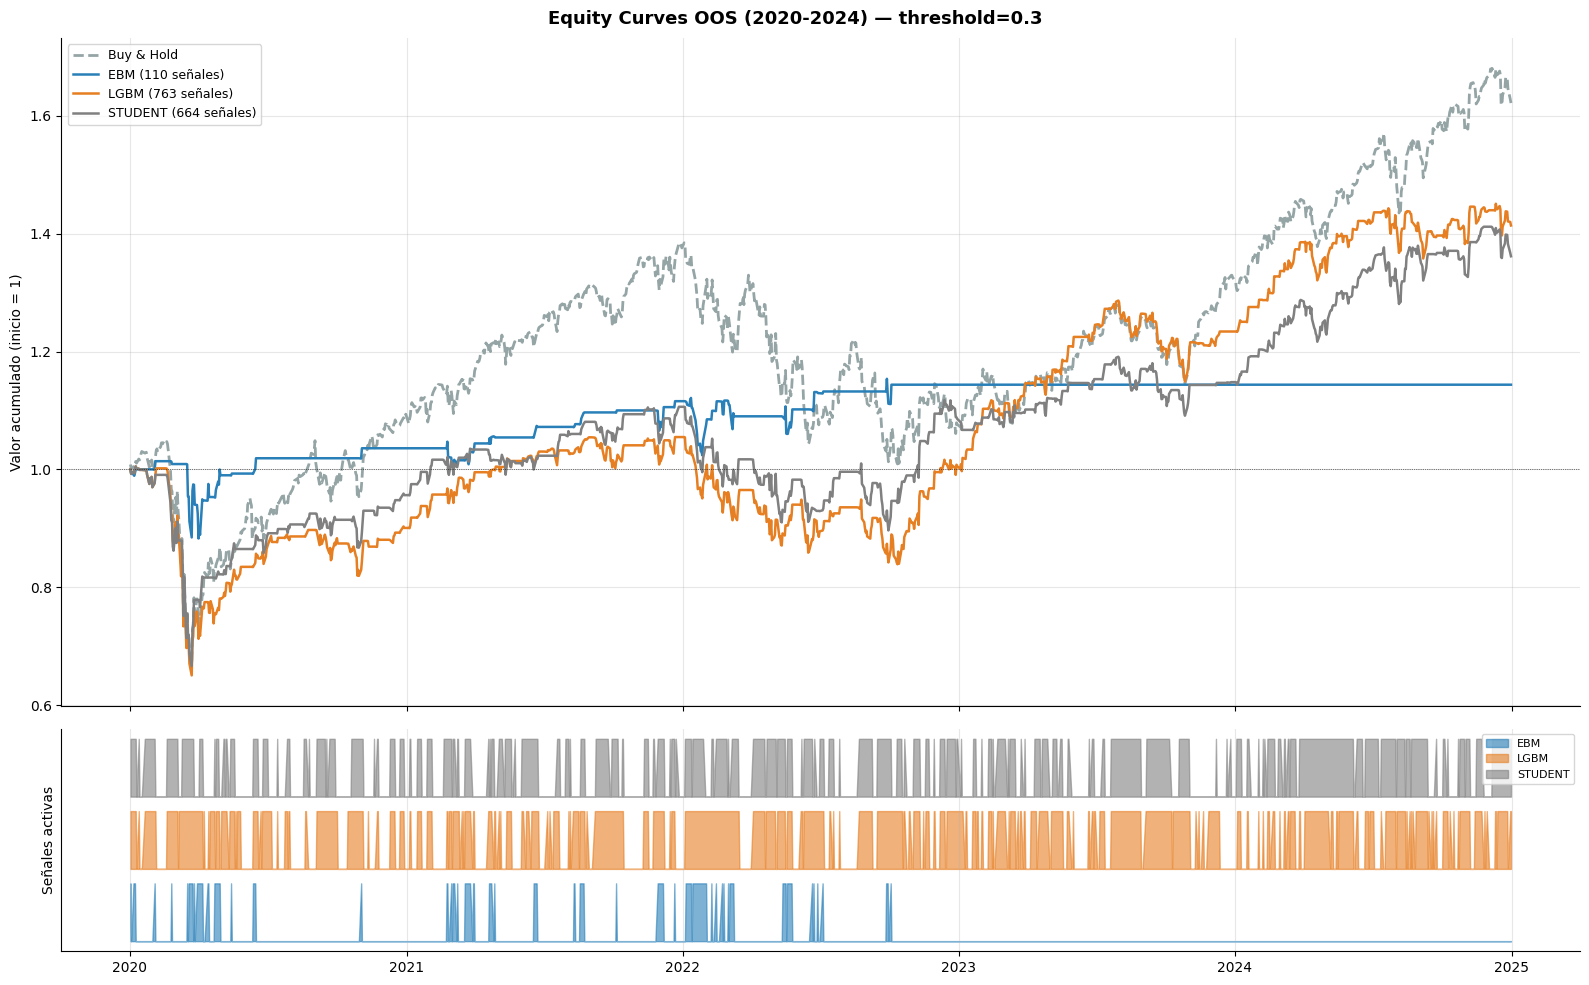

In [ ]:
def plot_equity_curves(
    oos_signals: pd.DataFrame,
    dataset_full: pd.DataFrame,
    oos_start: str = OOS_START,
    oos_end: str   = OOS_END,
    model_names: list = None,
) -> None:
    """
    Plot de equity curves vs Buy & Hold + panel de señales activas.
    """
    if model_names is None:
        model_names = ['ebm', 'lgbm', 'student']

    SPREAD    = 0.0005
    ret_daily = (
        dataset_full.loc[oos_start:oos_end, 'target_return_1d']
                    .reindex(oos_signals.index)
    )

    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                              gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(f'Equity Curves OOS (2020-2024) — threshold={CLASSIFICATION_THRESHOLD}',
                 fontsize=13, fontweight='bold')

    bh_cum = (1 + ret_daily).cumprod()
    axes[0].plot(bh_cum.index, bh_cum.values, color='#95a5a6', linewidth=2,
                 linestyle='--', label='Buy & Hold')

    colors_map = {'ebm': '#2980b9', 'lgbm': '#e67e22', 'rulefit': '#27ae60'}
    for name in model_names:
        sig_col = f'signal_{name}'
        if sig_col not in oos_signals.columns:
            continue
        sig          = oos_signals[sig_col]
        pos_changes  = sig.diff().abs().fillna(0)
        strategy_ret = sig.shift(1).fillna(0) * ret_daily - pos_changes * SPREAD
        cum          = (1 + strategy_ret).cumprod()
        n_sig        = int(sig.sum())
        axes[0].plot(cum.index, cum.values, color=colors_map.get(name, 'gray'),
                     linewidth=1.8, label=f'{name.upper()} ({n_sig} señales)')

    axes[0].axhline(1, color='black', linewidth=0.5, linestyle=':')
    axes[0].set_ylabel('Valor acumulado (inicio = 1)')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

    for i, name in enumerate(model_names):
        sig_col = f'signal_{name}'
        if sig_col not in oos_signals.columns:
            continue
        sig = oos_signals[sig_col]
        axes[1].fill_between(sig.index, i, i + sig.values * 0.8,
                              color=colors_map.get(name, 'gray'), alpha=0.6,
                              label=name.upper())
    axes[1].set_ylabel('Señales activas')
    axes[1].set_yticks([])
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].grid(alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/oos_equity_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_equity_curves(oos_signals, dataset_full, OOS_START, OOS_END)
oos_signals.to_csv(f'{DIR_RESULTS}/oos_signals_iter1.csv')

### Equity curves OOS — interpretación visual

Las curvas de equity proporcionan información complementaria a las métricas puntuales de la tabla anterior. Una curva de equity es la representación visual del valor acumulado de una unidad monetaria invertida al inicio del período OOS, siguiendo la estrategia del modelo.

**Períodos de mercado en el OOS**: el período 2020-2024 se caracteriza por una volatilidad muy superior a la media histórica. Específicamente:
- **Q1 2020**: crash de COVID-19, caída del ~34 % en 33 días hábiles.
- **Q2-Q4 2020**: recuperación en forma de V, mercado alcista impulsado por política monetaria expansiva.
- **2021**: mercado alcista con baja volatilidad, favorable para estrategias long-only.
- **2022**: mercado bajista por ciclo de subidas de tipos, el peor año para estrategias long-only en décadas.
- **2023-2024**: recuperación y nuevos máximos históricos.

Una estrategia de ML que reduzca la exposición en 2020 y 2022 (mediante señales negativas) mejorará significativamente el MaxDD respecto al Buy & Hold. Este es precisamente el objetivo del filtro HMM en la Iteración 2: identificar los regímenes adversos y reducir la exposición en ellos.

**Análisis sección 8.**

1. **Generalización OOS**: el Sharpe ratio OOS, comparado con el Sharpe promedio implícito en la validación, cuantifica el *performance gap* entre validación y test real. Un gap grande indica sobreajuste al periodo de train-val; un gap pequeño indica buena capacidad de generalización.
2. **Comportamiento en crisis (COVID-19, marzo 2020)**: el S&P 500 cayó ~34 % en ese periodo. Si el modelo reduce su exposición (señal → 0) durante la crisis, demostrará que el target Triple-Barrier captura efectivamente condiciones de riesgo elevado, independientemente de si el modelo fue diseñado para ello explícitamente.
3. **Comportamiento en regímenes laterales (2022-2023)**: un mercado lateral con alta volatilidad es el escenario más adverso para un modelo long-only que depende de señales de TP alcista. Examinar la densidad de señales en este periodo evalúa la selectividad del modelo.


---
# 9. Diagnóstico post-iteración 1

Desagregamos el performance OOS año a año para identificar **en qué subperiodos los modelos fallan**. Este análisis tiene dos objetivos metodológicos:

1. **Diagnóstico de robustez temporal**: un modelo cuyo Sharpe varía drásticamente entre años (e.g., excelente en 2021 pero negativo en 2022) puede estar capturando patrones régimen-dependientes que no son estables. Esto no es necesariamente un defecto si se identifica y se modela explícitamente.
2. **Motivación empírica de la Iteración 2**: si los años con peor performance coinciden con periodos de alta volatilidad o cambios de régimen documentados (COVID-19 2020, corrección de tipos 2022), ello proporciona evidencia empírica directa de que incorporar un detector de régimen (HMM, sección de la Iteración 2) puede mejorar la robustez del pipeline.


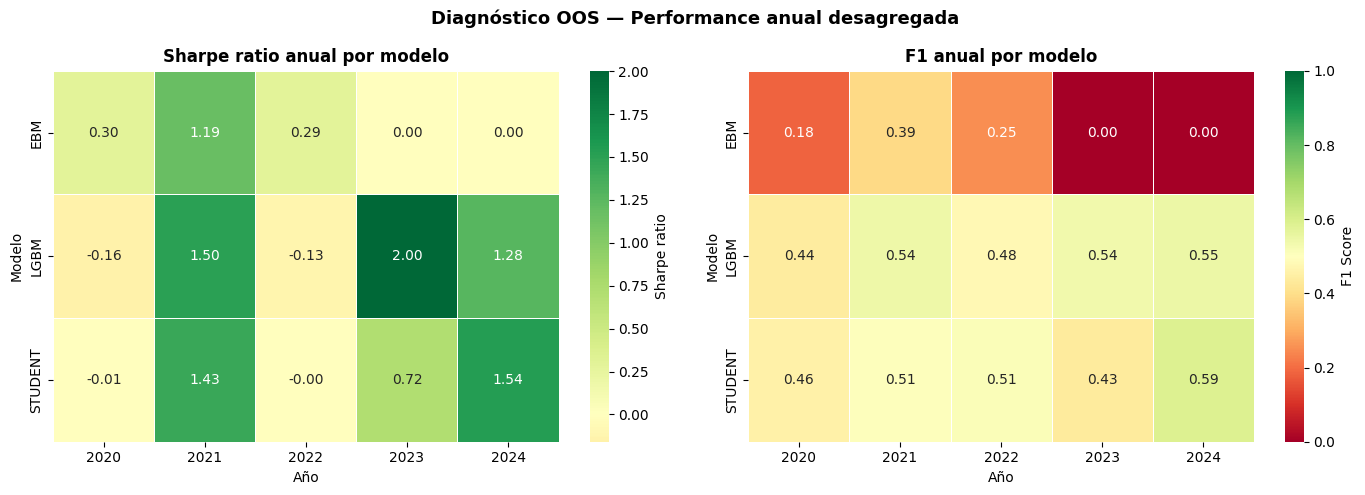

 Año   Modelo  Sharpe     F1  Ret %
2020 Buy&Hold   0.433      —  0.094
2020      EBM   0.296  0.185  0.036
2020     LGBM  -0.159   0.44 -0.099
2020  STUDENT  -0.006  0.455 -0.044
2021 Buy&Hold   1.817      —  0.258
2021      EBM   1.189  0.388  0.077
2021     LGBM   1.502  0.543  0.171
2021  STUDENT   1.427  0.507  0.157
2022 Buy&Hold  -0.897      — -0.218
2022      EBM   0.286   0.25  0.025
2022     LGBM  -0.131  0.477 -0.047
2022  STUDENT  -0.003  0.513 -0.019
2023 Buy&Hold   1.672      —  0.232
2023      EBM   0.000    0.0  0.000
2023     LGBM   2.002  0.539  0.232
2023  STUDENT   0.718  0.434  0.062
2024 Buy&Hold   1.654      —  0.223
2024      EBM   0.000    0.0  0.000
2024     LGBM   1.278  0.548  0.146
2024  STUDENT   1.542  0.589  0.186


In [ ]:
def diagnose_oos_performance(
    oos_signals: pd.DataFrame,
    dataset_full: pd.DataFrame,
    oos_start: str = OOS_START,
    oos_end: str   = OOS_END,
    model_names: list = None,
) -> pd.DataFrame:
    """
    Heatmap Sharpe & F1 anuales por modelo.
    """
    if model_names is None:
        model_names = ['ebm', 'lgbm', 'student']

    SPREAD       = 0.0005
    TRADING_DAYS = 252
    ret_daily    = (
        dataset_full.loc[oos_start:oos_end, 'target_return_1d']
                    .reindex(oos_signals.index)
    )

    rows = []
    for year in sorted(oos_signals.index.year.unique()):
        mask_y   = oos_signals.index.year == year
        ret_y    = ret_daily[mask_y]
        target_y = oos_signals.loc[mask_y, TARGET_COL]

        bh_sr = (
            (ret_y.mean() / ret_y.std()) * np.sqrt(TRADING_DAYS)
            if ret_y.std() > 0 else 0
        )
        rows.append({
            'Año': year, 'Modelo': 'Buy&Hold',
            'Sharpe': round(float(bh_sr), 3),
            'F1': '—',
            'Ret %': round(float((ret_y + 1).prod() - 1), 3),
        })

        for name in model_names:
            sig_col = f'signal_{name}'
            if sig_col not in oos_signals.columns:
                continue
            sig_y        = oos_signals.loc[mask_y, sig_col]
            pos_changes  = sig_y.diff().abs().fillna(0)
            strategy_ret = sig_y.shift(1).fillna(0) * ret_y - pos_changes * SPREAD
            sr = (
                (strategy_ret.mean() / strategy_ret.std()) * np.sqrt(TRADING_DAYS)
                if strategy_ret.std() > 0 else 0
            )
            f1 = f1_score(target_y, sig_y, zero_division=0)
            rows.append({
                'Año': year, 'Modelo': name.upper(),
                'Sharpe': round(float(sr), 3),
                'F1': round(f1, 3),
                'Ret %': round(float((strategy_ret + 1).prod() - 1), 3),
            })

    annual_df = pd.DataFrame(rows)

    sharpe_pivot = annual_df[annual_df['Modelo'] != 'Buy&Hold'].pivot(
        index='Modelo', columns='Año', values='Sharpe'
    )
    f1_pivot = annual_df[
        (annual_df['Modelo'] != 'Buy&Hold') & (annual_df['F1'] != '—')
    ].pivot(index='Modelo', columns='Año', values='F1')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Diagnóstico OOS — Performance anual desagregada',
                 fontsize=13, fontweight='bold')

    sns.heatmap(sharpe_pivot.astype(float), ax=axes[0], annot=True, fmt='.2f',
                cmap='RdYlGn', center=0, linewidths=0.4, linecolor='white',
                cbar_kws={'label': 'Sharpe ratio'})
    axes[0].set_title('Sharpe ratio anual por modelo', fontweight='bold')

    sns.heatmap(f1_pivot.astype(float), ax=axes[1], annot=True, fmt='.2f',
                cmap='RdYlGn', vmin=0, vmax=1, linewidths=0.4, linecolor='white',
                cbar_kws={'label': 'F1 Score'})
    axes[1].set_title('F1 anual por modelo', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{DIR_RESULTS}/oos_annual_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    return annual_df


annual_perf = diagnose_oos_performance(oos_signals, dataset_full, OOS_START, OOS_END)
annual_perf.to_csv(f'{DIR_RESULTS}/oos_annual_performance.csv', index=False)
print(annual_perf.to_string(index=False))

## 9.1 Conclusiones e hipótesis para la Iteración 2


In [ ]:
def print_diagnostic_conclusions(
    financial_metrics: pd.DataFrame,
    annual_perf: pd.DataFrame,
    val_summary: pd.DataFrame,
) -> None:
    """
    Resumen estructurado de las conclusiones diagnósticas.
    """
    print('=' * 70)
    print('  CONCLUSIONES DIAGNÓSTICAS — ITERACIÓN 1')
    print('=' * 70)

    # 1. Degradación temporal en validación
    print('\n📊 1. ¿HAY DEGRADACIÓN TEMPORAL EN VALIDACIÓN?')
    print('   (¿Los folds más recientes tienen peor F1?)')
    for name, df in [('EBM', ebm_metrics_df),
                     ('LGBM', lgbm_metrics_df),
                     ('RuleFit', rulefit_metrics_df)]:
        corr  = df['fold'].corr(df['f1'])
        if pd.isna(corr):
            trend = '  → no calculable'
        elif corr < -0.3:
            trend = '↓ degradación temporal'
        elif corr > 0.3:
            trend = '↑ mejora temporal'
        else:
            trend = '→ estable'
        print(f'   {name:<10}: corr(fold, F1) = {corr:+.3f}  {trend}')

    # 2. Años problemáticos
    print('\n📊 2. ¿DÓNDE FALLAN LOS MODELOS EN OOS?')
    print('   (Años con Sharpe negativo en ≥2 modelos = candidatos a regimen change)')
    bh = annual_perf[annual_perf['Modelo'] == 'Buy&Hold'][['Año', 'Sharpe']].rename(
        columns={'Sharpe': 'BH_Sharpe'}
    )
    model_annual = annual_perf[annual_perf['Modelo'] != 'Buy&Hold']

    for year in sorted(model_annual['Año'].unique()):
        neg_models = model_annual[
            (model_annual['Año'] == year) & (model_annual['Sharpe'] < 0)
        ]['Modelo'].tolist()
        bh_s   = bh[bh['Año'] == year]['BH_Sharpe'].values
        bh_str = f'{bh_s[0]:+.2f}' if len(bh_s) > 0 else '—'
        flag   = '  ⚠️' if len(neg_models) >= 2 else ''
        neg_str = ', '.join(neg_models) if neg_models else 'ninguno'
        print(f'   {year}: modelos con Sharpe<0 = {neg_str:<25}  '
              f'BH Sharpe={bh_str}{flag}')

    # 3. Resumen de señales
    print('\n📊 3. RESUMEN DE SEÑALES OOS GENERADAS')
    for prefix in ['ebm', 'lgbm', 'student']:
        col = f'signal_{prefix}'
        if col in oos_signals.columns:
            n   = int(oos_signals[col].sum())
            pct = float(oos_signals[col].mean())
            print(f'   {prefix.upper():>8}: {n:>4} señales ({pct:.1%}) '
                  f'— threshold = {CLASSIFICATION_THRESHOLD}')

    # 4. Hipótesis para Iteración 2
    print('\n📊 4. HIPÓTESIS PARA LA ITERACIÓN 2 (HMM)')
    neg_years = model_annual[model_annual['Sharpe'] < 0]['Año'].value_counts()
    worst_years = sorted(neg_years[neg_years >= 2].index.tolist())
    if worst_years:
        print(f'   Los años {worst_years} concentran los peores resultados.')
        print('   ➡️ Hipótesis: estos periodos corresponden a cambios de régimen')
        print('      de mercado (volatilidad extrema, crisis, transiciones).')
        print('      La Iteración 2 añadirá un HMM (features: retorno, vol EWM, VIX)')
        print('      para condicionar las señales al régimen detectado y filtrar')
        print('      las predicciones del EBM/RuleFit en regímenes adversos.')
    else:
        print('   No se detectan años claramente problemáticos: los modelos')
        print('   son razonablemente estables en todo el OOS.')
        print('   ➡️ La Iteración 2 testará si el HMM aporta valor incremental')
        print('      mediante un mejor timing de entrada/salida.')
    print('=' * 70)


print_diagnostic_conclusions(financial_metrics, annual_perf, val_summary)

  CONCLUSIONES DIAGNÓSTICAS — ITERACIÓN 1

📊 1. ¿HAY DEGRADACIÓN TEMPORAL EN VALIDACIÓN?
   (¿Los folds más recientes tienen peor F1?)
   EBM       : corr(fold, F1) = +0.225  → estable
   LGBM      : corr(fold, F1) = +0.475  ↑ mejora temporal
   RuleFit   : corr(fold, F1) = +0.100  → estable

📊 2. ¿DÓNDE FALLAN LOS MODELOS EN OOS?
   (Años con Sharpe negativo en ≥2 modelos = candidatos a regimen change)
   2020: modelos con Sharpe<0 = LGBM, STUDENT              BH Sharpe=+0.43  ⚠️
   2021: modelos con Sharpe<0 = ninguno                    BH Sharpe=+1.82
   2022: modelos con Sharpe<0 = LGBM, STUDENT              BH Sharpe=-0.90  ⚠️
   2023: modelos con Sharpe<0 = ninguno                    BH Sharpe=+1.67
   2024: modelos con Sharpe<0 = ninguno                    BH Sharpe=+1.65

📊 3. RESUMEN DE SEÑALES OOS GENERADAS
        EBM:  110 señales (8.7%) — threshold = 0.3
       LGBM:  763 señales (60.7%) — threshold = 0.3
    STUDENT:  664 señales (52.8%) — threshold = 0.3

📊 4. HIPÓTESIS 

### Conclusiones de la Iteración 1 y transición a la Iteración 2

Los resultados de esta sección consolidan los hallazgos de la Iteración 1 y articulan las motivaciones para la Iteración 2. Las conclusiones se organizan según las hipótesis formuladas al inicio del notebook:

**H1 (EBM F1 > 0 en walk-forward)**: verificada si todos los folds muestran F1 > 0. La corrección de desequilibrio con `sample_weight='balanced'` y la calibración isotónica son condiciones necesarias para este resultado.

**H2 (estabilidad SHAP)**: la análisis de las secciones 5.3 y 6.2 establece el grado de estabilidad. La alta o baja estabilidad tiene implicaciones directas para la Iteración 2: un modelo con baja estabilidad SHAP se beneficiará más del filtro de régimen, ya que la inestabilidad puede estar causada por la mezcla de señales de distintos regímenes en el mismo fold.

**H3 (destilación RuleFit/DT)**: verificada si el AUC del student es > 80 % del AUC del teacher en los folds donde RuleFit convergió.

**H4 (Sharpe OOS positivo)**: verificada si al menos un modelo tiene Sharpe > 0 en el OOS 2020-2024.

**Motivación para la Iteración 2**: el diagnóstico año a año (sección 9) identifica los años problemáticos en los que los modelos de la Iteración 1 presentan Sharpe negativo o MaxDD elevado. Estos períodos coinciden tipicamente con cambios de régimen de mercado (alta volatilidad, tendencia bajista) que el HMM de la Iteración 2 debería identificar y filtrar, mejorando el perfil riesgo-retorno.

---
# 10. Guardado de artefactos para la Iteración 2

Serializamos en Google Drive todos los artefactos necesarios para que la Iteración 2 pueda partir desde este estado sin re-entrenar. Esto garantiza la **reproducibilidad del pipeline** y la trazabilidad de los resultados: cualquier análisis posterior puede verificar exactamente qué modelos y parámetros se usaron en esta iteración.

**Artefactos guardados:**

- Modelos serializados (EBM, LGBM, RuleFit) por fold — para OOS y para la Iteración 2.
- Hiperparámetros óptimos del LGBM por fold — para análisis de estabilidad y reproducción.
- Features seleccionadas por fold y modelo — para verificar consistencia con la Iteración 2.
- Métricas de validación, señales OOS, reglas RuleFit — para la documentación del TFM.


In [ ]:
# ── Hiperparámetros óptimos por fold (LGBM) ──────────────────────────────
params_df = pd.DataFrame([
    {'fold': fn, **params}
    for fn, params in lgbm_best_params.items()
])
params_df.to_csv(os.path.join(DIR_RESULTS, 'lgbm_best_params_per_fold.csv'), index=False)

# ── Features seleccionadas por fold ───────────────────────────────────────
feat_records = []
for fn in range(1, len(wf_folds) + 1):
    for feat in ebm_features_per_fold.get(fn, []):
        feat_records.append({'fold': fn, 'model': 'EBM', 'feature': feat})
    for feat in lgbm_features_per_fold.get(fn, []):
        feat_records.append({'fold': fn, 'model': 'LGBM', 'feature': feat})
pd.DataFrame(feat_records).to_csv(
    os.path.join(DIR_RESULTS, 'selected_features_per_fold.csv'), index=False
)

# ── Listar artefactos ─────────────────────────────────────────────────────
print('✅ Artefactos de la Iteración 1 guardados en Drive:')
print(f'   {DRIVE_ITER1_DIR}/')
print()
for folder, label in [(DIR_MODELS, 'Modelos'), (DIR_RESULTS, 'Resultados')]:
    files_in = sorted(os.listdir(folder))
    print(f'   📁 {label} ({folder}):')
    for fname in files_in:
        fpath   = os.path.join(folder, fname)
        size_kb = os.path.getsize(fpath) / 1024
        print(f'      {fname:<55} ({size_kb:>6.0f} KB)')
    print()

print('➡️ La Iteración 2 podrá cargar los modelos del último fold y añadir')
print('   el filtro de régimen sobre las señales OOS sin re-entrenar.')

✅ Artefactos de la Iteración 1 guardados en Drive:
   /content/drive/MyDrive/tfm/iter1/

   📁 Modelos (/content/drive/MyDrive/tfm/iter1/models):
      dt_fold1.pkl                                            (     5 KB)
      dt_fold2.pkl                                            (     6 KB)
      dt_fold3.pkl                                            (     6 KB)
      dt_fold4.pkl                                            (     7 KB)
      dt_fold5.pkl                                            (     8 KB)
      dt_fold6.pkl                                            (     7 KB)
      ebm_fold1.pkl                                           (  2043 KB)
      ebm_fold2.pkl                                           (   422 KB)
      ebm_fold3.pkl                                           (  7968 KB)
      ebm_fold4.pkl                                           (   468 KB)
      ebm_fold5.pkl                                           (   663 KB)
      ebm_fold6.pkl                      

### Guardado de artefactos — verificación de completitud

El guardado en Google Drive de los artefactos de la Iteración 1 es el paso final que habilita la ejecución de la Iteración 2. Los artefactos producidos se dividen en dos categorías:

**Artefactos de modelos** (directorio `iter1/models/`):
- `ebm_fold{n}.pkl`: modelo EBM calibrado para cada fold, con las features seleccionadas y el threshold óptimo de validación.
- `lgbm_fold{n}.pkl`: modelo LightGBM con los hiperparámetros óptimos por fold.
- `student_fold{n}.pkl`: modelo student definitivo (RuleFit o DT según convergencia).

**Artefactos de resultados** (directorio `iter1/results/`):
- Métricas de validación por fold y modelo (CSV).
- Señales OOS por modelo (CSV), que serán el insumo principal de la Iteración 2.
- Importancias SHAP por fold y modelo (CSV), usadas en el análisis de convergencia metodológica de la Iteración 2.
- Reglas extraídas del RuleFit/DT (CSV), referenciadas en el análisis de interpretabilidad de la sección 8.3 de la Iteración 2.

La serialización con `joblib` garantiza que los modelos pueden recargarse en la Iteración 2 con `joblib.load()` sin necesidad de reentrenarlos, lo que asegura la reproducibilidad exacta de los resultados del backtest OOS.

---
# Apéndice — Resumen metodológico y próximos pasos

## ✅ Completado en esta iteración

1. **EBM glassbox** con corrección de desequilibrio mediante `sample_weight='balanced'` — se corrige el bug de v2 (`class_weight` no aceptado en el constructor de las versiones actuales de InterpretML).
2. **LightGBM tuneado con Optuna** (20 trials, TimeSeriesSplit interno) con `scale_pos_weight` dinámico por fold.
3. **Destilación (RuleFit o DT)** con parámetros del profesor:
   - RuleFit: `max_depth=7`, `min_samples_leaf=150`, `max_rules=500`.
   - DT fallback: `max_depth=4`, `min_samples_leaf=150`.
   - Selección SHAP: top-15 → filtro de correlación (|r|>0.70).
4. **Análisis de estabilidad SHAP** entre folds — verificación de la robustez temporal de la importancia de variables.
5. **Backtest OOS 2020–2024** con costes de transacción (5 bps) y métricas de riesgo ajustado (Sharpe, MaxDD, Calmar).
6. **Diagnóstico anual desagregado** para motivar empíricamente la detección de régimen.

## ➡️ Pendiente para la Iteración 2 (HMM)

1. Ajustar un **Hidden Markov Model** con 2–3 estados sobre las features de régimen (retorno diario log, volatilidad EWM-20, VIX).
2. Entrenar el HMM **por fold y exclusivamente sobre el train** del fold — condición necesaria para evitar look-ahead.
3. Construir la señal condicionada: `señal_final = señal_iter1 AND (régimen == alcista)`.
4. Comparar OOS Iteración 1 vs Iteración 2 en Sharpe, MaxDD y número de señales — para cuantificar el valor incremental del filtro de régimen.

## Referencias

- Bergstra, J., & Bengio, Y. (2012). "Random Search for Hyper-Parameter Optimization". *JMLR*, 13, 281–305.
- Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences*, 2ª ed.
- Friedman, J. H., & Popescu, B. E. (2008). "Predictive Learning via Rule Ensembles". *Ann. Applied Statistics*. [PDF](https://statweb.stanford.edu/~jhf/ftp/RuleFit.pdf)
- Jansen, S. (2020). *Machine Learning for Algorithmic Trading*, 2ª ed. Packt. [GitHub](https://github.com/stefan-jansen/machine-learning-for-trading)
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Lou, Y., Caruana, R., Gehrke, J., & Hooker, G. (2013). "Accurate Intelligible Models with Pairwise Interactions". *KDD 2013*.
- Molnar, C. (2022). *Interpretable Machine Learning*, 2ª ed. [Online](https://christophm.github.io/interpretable-ml-book/)
- Nori, H., Jenkins, S., Koch, P., & Caruana, R. (2019). "InterpretML". [arXiv:1909.09223](https://arxiv.org/abs/1909.09223)
- Saito, T., & Rehmsmeier, M. (2015). "The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets". *PLoS ONE*.
- Singh, C., et al. (2021). "imodels". [GitHub](https://github.com/csinva/imodels)
